# Kalman Filter Class Development

In [1]:
from __future__ import annotations

from abc import ABC, abstractmethod
from typing import TypeAlias, Any

import numpy as np
from numpy.typing import NDArray, ArrayLike

from dataclasses import dataclass

import inspect

import matplotlib.pyplot as plt

# 1 - Model Contracts

In [2]:
# ======================================================================
# Type aliases
# ======================================================================
StateVector       : TypeAlias = NDArray[np.float64]
MeasurementVector : TypeAlias = NDArray[np.float64]
ControlVector     : TypeAlias = NDArray[np.float64]
Matrix            : TypeAlias = NDArray[np.float64]
SampleMatrix      : TypeAlias = NDArray[np.float64]
SigmaPointMatrix  : TypeAlias = NDArray[np.float64]
WeightVector      : TypeAlias = NDArray[np.float64]


## 1.1 - `ProcessModel`

In [3]:
class ProcessModel(ABC):
    """
    Contract for discrete-time state dynamics and process noise.

    State propagation
    -----------------
    This model describes how the state evolves from time step k to the
    next time step k+1.

    Linear form
    -----------
    {x_k+1} = [F_k] {x_k} + [G_k] {u_k} + {w_k}

    Nonlinear form
    --------------
    {x_k+1} = f({x_k}, {u_k}, dt) + {w_k}

    Process noise
    -------------
    The process noise covariance is

    [Q_k] = E[{w_k} {w_k^T}]

    where:
    - {x_k} is the state at time step k
    - {x_k+1} is the propagated state at the next time step
    - {u_k} is the control input at time step k
    - {w_k} is the process noise at time step k
    - [F_k] is the linear state-transition matrix
    - [G_k] is the linear control-input matrix
    - [Q_k] is the discrete-time process noise covariance

    Usage
    -----
    Subclass `ProcessModel` to define how the system state propagates from
    one discrete time step to the next.

    Typical pattern:
    - define `state_labels` for the ordered components of the state vector
    - define `control_labels` if the process model uses named control inputs
    - implement `Q(...)`
    - implement `F(...)` for linear filters, or `f(...)` / `F_jacobian(...)`
    for nonlinear filters as needed
    - implement `G(...)` when the process model includes a linear
    control-input mapping
    - override `apply_state_delta(...)` and `state_residual(...)` when the
    state does not live in ordinary Euclidean space, such as quaternion
    or angle-valued states

    A `ProcessModel` instance is typically registered inside a
    `StateSpaceModel` and used by the filter predict step.

    Required
    --------
    - state_labels
    - Q(...)

    Optional / estimator-dependent
    ------------------------------
    - control_labels
    - f(...)
    - F(...)
    - F_jacobian(...)
    - G(...)

    Notes
    -----
    Geometry hooks are provided for states that are not represented in
    ordinary Euclidean space.
    """
    # =========================================================================
    # Constructor
    # =========================================================================
    def __init__(
        self,
        state_labels: tuple[str, ...],
        control_labels: tuple[str, ...] | None = None,
    ) -> None:
        """
        Store the ordered state labels and optional control labels.
        """
        self._state_labels = tuple(state_labels)
        self._control_labels = None if control_labels is None else tuple(control_labels)

        self._validate_labels(self._state_labels, name="state_labels")

        if self._control_labels is not None:
            self._validate_labels(self._control_labels, name="control_labels")

    # =========================================================================
    # Public properties
    # =========================================================================
    @property
    def state_labels(self) -> tuple[str, ...]:
        """
        Return the ordered state labels that define the state vector layout.
        """
        return self._state_labels

    @property
    def control_labels(self) -> tuple[str, ...] | None:
        """
        Return the ordered control labels, or None if no named control input exists.
        """
        return self._control_labels

    @property
    def state_dim(self) -> int:
        """
        Return the state dimension derived from state_labels.
        """
        return len(self._state_labels)

    @property
    def control_dim(self) -> int | None:
        """
        Return the control dimension derived from control_labels, if available.
        """
        return None if self._control_labels is None else len(self._control_labels)

    # =========================================================================
    # Required stochastic interface
    # =========================================================================
    @abstractmethod
    def Q(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        """
        Return the discrete-time process noise covariance.
        """
        raise NotImplementedError

    # =========================================================================
    # Estimator-dependent capabilities
    # =========================================================================
    def f(
        self,
        x: StateVector,
        u: ControlVector | None = None,
        dt: float | None = None,
    ) -> StateVector:
        """
        Propagate the state with the nonlinear process model.
        """
        raise NotImplementedError(f"{type(self).__name__} must implement f().")

    def F(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        """
        Return the linear state-transition matrix.
        """
        raise NotImplementedError(f"{type(self).__name__} must implement F().")

    def F_jacobian(
        self,
        x: StateVector,
        u: ControlVector | None = None,
        dt: float | None = None,
    ) -> Matrix:
        """
        Return the Jacobian of f with respect to state.
        """
        raise NotImplementedError(f"{type(self).__name__} must implement F_jacobian().")

    def G(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        """
        Return the linear control-input matrix when the model uses one.
        """
        raise NotImplementedError(f"{type(self).__name__} must implement G().")

    # =========================================================================
    # Geometry hooks
    # =========================================================================
    def state_residual(
        self,
        a: StateVector,
        b: StateVector,
    ) -> StateVector:
        """
        Return the residual a - b in state space.

        Default behavior assumes Euclidean state arithmetic. Override this
        for non-Euclidean states such as quaternion or angle-valued states.
        """
        state_a = np.asarray(a, dtype=np.float64)
        state_b = np.asarray(b, dtype=np.float64)
        return state_a - state_b

    def state_mean(
        self,
        samples: SampleMatrix,
        weights: WeightVector,
    ) -> StateVector:
        """
        Return the weighted mean in state space.

        Default behavior assumes Euclidean state arithmetic. Override this
        for non-Euclidean states when sample-based averaging is required.
        """
        state_samples = np.asarray(samples, dtype=np.float64)
        sample_weights = np.asarray(weights, dtype=np.float64)
        return np.average(state_samples, axis=0, weights=sample_weights)

    def apply_state_delta(
        self,
        x: StateVector,
        dx: StateVector,
    ) -> StateVector:
        """
        Apply a correction in state space.

        Default behavior assumes Euclidean state arithmetic. Override this
        for non-Euclidean states such as quaternion or angle-valued states.
        """
        state = np.asarray(x, dtype=np.float64)
        delta = np.asarray(dx, dtype=np.float64)
        return state + delta

    # =========================================================================
    # Internal helpers
    # =========================================================================
    @staticmethod
    def _validate_labels(labels: tuple[str, ...], name: str) -> None:
        """
        Validate a tuple of ordered labels used to define a vector layout.
        """
        if len(labels) == 0:
            raise ValueError(f"{name} must be non-empty.")

        if any(not isinstance(label, str) for label in labels):
            raise TypeError(f"{name} must contain only strings.")

        if any(label == "" for label in labels):
            raise ValueError(f"{name} must not contain empty labels.")

        if any(label != label.strip() for label in labels):
            raise ValueError(f"{name} must not contain leading or trailing whitespace.")

        if any(not label.isidentifier() for label in labels):
            raise ValueError(
                f"{name} must contain valid Python identifiers so named builders "
                f"can use keyword arguments."
            )

        if len(set(labels)) != len(labels):
            raise ValueError(f"{name} must contain unique labels.")

## 1.2 - `MeasurementModel`

In [4]:
class MeasurementModel(ABC):
    """
    Contract for mapping state into measurement space, measurement noise,
    and measurement geometry.

    Measurement mapping
    -------------------
    This model maps the current state {x_k} into measurement space {z_k}.

    Linear form
    -----------
    {z_k} = [H_k] {x_k} + {v_k}

    Nonlinear form
    --------------
    {z_k} = h({x_k}, dt) + {v_k}

    Measurement noise
    -----------------
    The measurement noise covariance is

    [R_k] = E[{v_k} {v_k}^T]

    where:
    - {x_k} is the state at time step k
    - {z_k} is the measurement at time step k
    - {v_k} is the measurement noise at time step k
    - [H_k] is the linear measurement matrix
    - [R_k] is the measurement noise covariance

    Usage
    -----
    Subclass `MeasurementModel` to define how one measurement source maps
    the current state into measurement space.

    Typical pattern:
    - define `state_labels` to match the process/state layout
    - define `measurement_labels` for the components of the measurement vector
    - implement `R(...)`
    - implement `H(...)` for linear filters, or `h(...)` / `H_jacobian(...)`
    for nonlinear filters as needed
    - override `innovation(...)` when the measurement does not live in
    ordinary Euclidean space, such as wrapped angles, bearings, or
    attitude-like quantities

    A `MeasurementModel` instance is typically registered inside a
    `StateSpaceModel` and selected by name during the filter update step.

    Required
    --------
    - state_labels
    - measurement_labels
    - R(...)

    Optional / estimator-dependent
    ------------------------------
    - h(...)
    - H(...)
    - H_jacobian(...)

    Notes
    -----
    Geometry hooks are provided for measurements that are not represented
    in ordinary Euclidean space.
    """

    # =========================================================================
    # Constructor
    # =========================================================================
    def __init__(
        self,
        state_labels: tuple[str, ...],
        measurement_labels: tuple[str, ...],
    ) -> None:
        """
        Store the ordered state and measurement labels used by this model.
        """
        self._state_labels = tuple(state_labels)
        self._measurement_labels = tuple(measurement_labels)

        self._validate_labels(self._state_labels, name="state_labels")
        self._validate_labels(self._measurement_labels, name="measurement_labels")

    # =========================================================================
    # Public properties
    # =========================================================================
    @property
    def state_labels(self) -> tuple[str, ...]:
        """
        Return the ordered state labels expected by this model.
        """
        return self._state_labels

    @property
    def measurement_labels(self) -> tuple[str, ...]:
        """
        Return the ordered measurement labels produced by this model.
        """
        return self._measurement_labels

    @property
    def state_dim(self) -> int:
        """
        Return the state dimension derived from state_labels.
        """
        return len(self._state_labels)

    @property
    def measurement_dim(self) -> int:
        """
        Return the measurement dimension derived from measurement_labels.
        """
        return len(self._measurement_labels)

    # =========================================================================
    # Required stochastic interface
    # =========================================================================
    @abstractmethod
    def R(
        self,
        x: StateVector | None = None,
        z: MeasurementVector | None = None,
        dt: float | None = None,
    ) -> Matrix:
        """
        Return the measurement noise covariance.
        """
        raise NotImplementedError

    # =========================================================================
    # Estimator-dependent capabilities
    # =========================================================================
    def h(
        self,
        x: StateVector,
        dt: float | None = None,
    ) -> MeasurementVector:
        """
        Predict the measurement from the current state.
        """
        raise NotImplementedError(f"{type(self).__name__} must implement h().")

    def H(
        self,
        x: StateVector | None = None,
        dt: float | None = None,
    ) -> Matrix:
        """
        Return the linear measurement matrix.
        """
        raise NotImplementedError(f"{type(self).__name__} must implement H().")

    def H_jacobian(
        self,
        x: StateVector,
        dt: float | None = None,
    ) -> Matrix:
        """
        Return the Jacobian of h with respect to state.
        """
        raise NotImplementedError(f"{type(self).__name__} must implement H_jacobian().")

    # =========================================================================
    # Geometry hooks
    # =========================================================================
    def innovation(
        self,
        z: MeasurementVector,
        z_pred: MeasurementVector,
    ) -> MeasurementVector:
        """
        Return the measurement residual between z and z_pred.

        Default behavior assumes Euclidean measurement arithmetic.
        Override this for non-Euclidean measurements such as wrapped
        angles, bearings, azimuth/elevation, or attitude-like quantities.
        """
        measurement = np.asarray(z, dtype=np.float64)
        predicted_measurement = np.asarray(z_pred, dtype=np.float64)
        return measurement - predicted_measurement

    def measurement_mean(
        self,
        samples: SampleMatrix,
        weights: WeightVector,
    ) -> MeasurementVector:
        """
        Return the weighted mean of multiple measurement-space samples.

        Default behavior assumes Euclidean measurement arithmetic.
        Override this when sample-based measurement averaging must respect
        non-Euclidean measurement geometry.
        """
        measurement_samples = np.asarray(samples, dtype=np.float64)
        sample_weights = np.asarray(weights, dtype=np.float64)
        return np.average(measurement_samples, axis=0, weights=sample_weights)

    # =========================================================================
    # Internal helpers
    # =========================================================================
    @staticmethod
    def _validate_labels(labels: tuple[str, ...], name: str) -> None:
        """
        Validate a tuple of ordered labels used to define a vector layout.
        """
        if len(labels) == 0:
            raise ValueError(f"{name} must be non-empty.")

        if any(not isinstance(label, str) for label in labels):
            raise TypeError(f"{name} must contain only strings.")

        if any(label == "" for label in labels):
            raise ValueError(f"{name} must not contain empty labels.")

        if any(label != label.strip() for label in labels):
            raise ValueError(f"{name} must not contain leading or trailing whitespace.")

        if any(not label.isidentifier() for label in labels):
            raise ValueError(
                f"{name} must contain valid Python identifiers so named builders "
                f"can use keyword arguments."
            )

        if len(set(labels)) != len(labels):
            raise ValueError(f"{name} must contain unique labels.")


## 1.3 - `StateSpaceModel`

In [5]:
class StateSpaceModel:
    """
    Assemble one process model and zero or more measurement models into
    one estimator-facing system contract.

    System composition
    ------------------
    This class combines:
    - one `ProcessModel`
    - zero or more named `MeasurementModel` instances

    so that filters can interact with one unified interface for:
    - state propagation
    - process noise
    - measurement prediction
    - measurement noise
    - geometry-aware state and measurement operations

    Usage
    -----
    Create one `StateSpaceModel` by supplying:
    - one `ProcessModel` instance
    - zero or more named `MeasurementModel` instances

    Typical pattern:
    - define the system dynamics in a `ProcessModel`
    - define one `MeasurementModel` per measurement source or measurement type
    - register measurement models by name
    - pass this assembled object to the filter as the single model interface

    This class is a composition and delegation layer. Concrete physics
    should live in `ProcessModel` and `MeasurementModel` subclasses.

    When exactly one measurement model is registered, measurement-facing
    methods may omit `measurement_name`. When multiple measurement models
    are registered, `measurement_name` must be provided explicitly.

    Notes
    -----
    Geometry-sensitive methods such as `apply_state_delta(...)`,
    `state_residual(...)`, `state_mean(...)`, `innovation(...)`, and
    `measurement_mean(...)` should be authored by the component models.
    Filters call them through this assembled interface so Euclidean
    defaults and non-Euclidean overrides both flow through one
    system-level contract.
    """

    # =========================================================================
    # Constructor
    # =========================================================================
    def __init__(
        self,
        process_model: ProcessModel,
        measurement_models: dict[str, MeasurementModel] | None = None,
    ) -> None:
        """
        Construct an assembled system model.
        """
        self.process_model = process_model
        self.measurement_models: dict[str, MeasurementModel] = {}

        self._state_labels = tuple(self.process_model.state_labels)
        self._state_index_map = self._build_index_map(self._state_labels)

        self._control_labels = self.process_model.control_labels
        self._control_index_map = (
            {}
            if self._control_labels is None
            else self._build_index_map(self._control_labels)
        )

        self._measurement_index_maps: dict[str, dict[str, int]] = {}

        if measurement_models is not None:
            for name, model in measurement_models.items():
                self.add_measurement_model(name, model)

    # =========================================================================
    # Public properties
    # =========================================================================
    @property
    def state_labels(self) -> tuple[str, ...]:
        """
        Return the canonical state labels.
        """
        return self._state_labels

    @property
    def state_dim(self) -> int:
        """
        Return the canonical state dimension.
        """
        return len(self._state_labels)

    @property
    def control_labels(self) -> tuple[str, ...] | None:
        """
        Return the control labels, or None if no named control input exists.
        """
        return self._control_labels

    @property
    def control_dim(self) -> int | None:
        """
        Return the control dimension, or None if no named control input exists.
        """
        return None if self._control_labels is None else len(self._control_labels)

    @property
    def measurement_names(self) -> tuple[str, ...]:
        """
        Return the registered measurement model names.
        """
        return tuple(self.measurement_models.keys())

    @property
    def has_measurement_models(self) -> bool:
        """
        Return True if at least one measurement model is registered.
        """
        return len(self.measurement_models) > 0

    @property
    def has_control_input(self) -> bool:
        """
        Return True if the process model defines named control inputs.
        """
        return self._control_labels is not None

    # =========================================================================
    # Public model registration and metadata
    # =========================================================================
    def add_measurement_model(
        self,
        name: str,
        model: MeasurementModel,
    ) -> None:
        """
        Register a named measurement model.
        """
        if not isinstance(name, str) or not name.strip():
            raise ValueError("Measurement model name must be a non-empty string.")

        if name in self.measurement_models:
            raise ValueError(f"Measurement model '{name}' is already registered.")

        if tuple(model.state_labels) != self._state_labels:
            raise ValueError(
                f"Measurement model '{name}' state_labels must match process model "
                "state_labels exactly."
            )

        self.measurement_models[name] = model
        self._measurement_index_maps[name] = self._build_index_map(
            tuple(model.measurement_labels)
        )

    def has_measurement_model(self, name: str) -> bool:
        """
        Return True if a named measurement model is registered.
        """
        return name in self.measurement_models

    def get_measurement_model(
        self,
        measurement_name: str | None = None,
    ) -> MeasurementModel:
        """
        Return one registered measurement model.
        """
        resolved_name = self._resolve_measurement_name(measurement_name)
        return self.measurement_models[resolved_name]

    def get_measurement_labels(
        self,
        measurement_name: str | None = None,
    ) -> tuple[str, ...]:
        """
        Return the measurement labels for one measurement model.
        """
        return tuple(self.get_measurement_model(measurement_name).measurement_labels)

    def measurement_dim(
        self,
        measurement_name: str | None = None,
    ) -> int:
        """
        Return the dimension of one measurement model.
        """
        return self.get_measurement_model(measurement_name).measurement_dim

    # =========================================================================
    # Public index helpers
    # =========================================================================
    def state_index(self, label: str) -> int:
        """
        Return the index of a named state.
        """
        if label not in self._state_index_map:
            raise KeyError(f"State label '{label}' is not defined.")
        return self._state_index_map[label]

    def state_indices(self, *labels: str) -> tuple[int, ...]:
        """
        Return the indices of one or more named states.
        """
        return tuple(self.state_index(label) for label in labels)

    def control_index(self, label: str) -> int:
        """
        Return the index of a named control input.
        """
        self._require_control_input()

        if label not in self._control_index_map:
            raise KeyError(f"Control label '{label}' is not defined.")
        return self._control_index_map[label]

    def control_indices(self, *labels: str) -> tuple[int, ...]:
        """
        Return the indices of one or more named control inputs.
        """
        return tuple(self.control_index(label) for label in labels)

    def measurement_index(
        self,
        measurement_name: str | None,
        label: str,
    ) -> int:
        """
        Return the index of a named measurement within one measurement model.
        """
        resolved_name = self._resolve_measurement_name(measurement_name)
        index_map = self._measurement_index_maps[resolved_name]

        if label not in index_map:
            raise KeyError(
                f"Measurement label '{label}' is not defined for model '{resolved_name}'."
            )

        return index_map[label]

    def measurement_indices(
        self,
        measurement_name: str | None,
        *labels: str,
    ) -> tuple[int, ...]:
        """
        Return the indices of one or more named measurements within one model.
        """
        return tuple(self.measurement_index(measurement_name, label) for label in labels)

    # =========================================================================
    # Public builders
    # =========================================================================
    def zero_state(self) -> StateVector:
        """
        Return a zero state vector.
        """
        return np.zeros(self.state_dim, dtype=np.float64)

    def state(self, **values: float) -> StateVector:
        """
        Build a full state vector from named values.
        """
        return self._build_named_vector(
            index_map=self._state_index_map,
            values=values,
            vector_name="state",
        )

    def zero_control(self) -> ControlVector:
        """
        Return a zero control vector.
        """
        self._require_control_input()
        assert self.control_dim is not None
        return np.zeros(self.control_dim, dtype=np.float64)

    def control(self, **values: float) -> ControlVector:
        """
        Build a full control vector from named values.
        """
        self._require_control_input()
        return self._build_named_vector(
            index_map=self._control_index_map,
            values=values,
            vector_name="control",
        )

    def zero_measurement(
        self,
        measurement_name: str | None = None,
    ) -> MeasurementVector:
        """
        Return a zero measurement vector for one measurement model.
        """
        measurement_model = self.get_measurement_model(measurement_name)
        return np.zeros(measurement_model.measurement_dim, dtype=np.float64)

    def measurement(
        self,
        measurement_name: str | None = None,
        **values: float,
    ) -> MeasurementVector:
        """
        Build a full measurement vector from named values.
        """
        resolved_name = self._resolve_measurement_name(measurement_name)
        return self._build_named_vector(
            index_map=self._measurement_index_maps[resolved_name],
            values=values,
            vector_name=f"measurement '{resolved_name}'",
        )

    def zero_state_covariance(self) -> Matrix:
        """
        Return a zero state covariance matrix.
        """
        return np.zeros((self.state_dim, self.state_dim), dtype=np.float64)

    def state_covariance(self, **variances: float) -> Matrix:
        """
        Build a diagonal state covariance matrix from named variances.
        """
        diagonal = self._build_named_vector(
            index_map=self._state_index_map,
            values=variances,
            vector_name="state covariance",
        )

        if np.any(diagonal < 0.0):
            raise ValueError("State covariance variances must be non-negative.")

        return np.diag(diagonal).astype(np.float64)

    # =========================================================================
    # Process-model delegation
    # =========================================================================
    def f(
        self,
        x: StateVector,
        u: ControlVector | None = None,
        dt: float | None = None,
    ) -> StateVector:
        """
        Delegate nonlinear state propagation to the process model.
        """
        x_next = self.process_model.f(x=x, u=u, dt=dt)
        return self._coerce_vector_output(
            vector=x_next,
            expected_dim=self.state_dim,
            method_name="f(...)",
            vector_name="state vector",
        )

    def F(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        """
        Delegate the linear state-transition matrix to the process model.
        """
        return self.process_model.F(dt=dt, x=x, u=u)

    def F_jacobian(
        self,
        x: StateVector,
        u: ControlVector | None = None,
        dt: float | None = None,
    ) -> Matrix:
        """
        Delegate the process Jacobian to the process model.
        """
        return self.process_model.F_jacobian(x=x, u=u, dt=dt)

    def Q(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        """
        Delegate the process noise covariance to the process model.
        """
        return self.process_model.Q(dt=dt, x=x, u=u)

    def G(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        """
        Delegate the linear control-input matrix to the process model.
        """
        return self.process_model.G(dt=dt, x=x, u=u)

    def state_residual(
        self,
        a: StateVector,
        b: StateVector,
    ) -> StateVector:
        """
        Return the state-space residual through the process model.
        """
        residual = self.process_model.state_residual(a=a, b=b)
        return self._coerce_vector_output(
            vector=residual,
            expected_dim=self.state_dim,
            method_name="state_residual(...)",
            vector_name="state vector",
        )

    def state_mean(
        self,
        samples: SampleMatrix,
        weights: WeightVector,
    ) -> StateVector:
        """
        Return the weighted state mean through the process model.
        """
        mean_state = self.process_model.state_mean(samples=samples, weights=weights)
        return self._coerce_vector_output(
            vector=mean_state,
            expected_dim=self.state_dim,
            method_name="state_mean(...)",
            vector_name="state vector",
        )

    def apply_state_delta(
        self,
        x: StateVector,
        dx: StateVector,
    ) -> StateVector:
        """
        Return the corrected state through the process model.
        """
        updated_state = self.process_model.apply_state_delta(x=x, dx=dx)
        return self._coerce_vector_output(
            vector=updated_state,
            expected_dim=self.state_dim,
            method_name="apply_state_delta(...)",
            vector_name="state vector",
        )

    # =========================================================================
    # Measurement-model delegation
    # =========================================================================
    def h(
        self,
        x: StateVector,
        measurement_name: str | None = None,
        dt: float | None = None,
    ) -> MeasurementVector:
        """
        Delegate nonlinear measurement prediction to one measurement model.
        """
        measurement_model = self.get_measurement_model(measurement_name)
        z_pred = measurement_model.h(x=x, dt=dt)
        return self._coerce_vector_output(
            vector=z_pred,
            expected_dim=measurement_model.measurement_dim,
            method_name="h(...)",
            vector_name="measurement vector",
            context_name=self._resolve_measurement_name(measurement_name),
        )

    def H(
        self,
        x: StateVector | None = None,
        measurement_name: str | None = None,
        dt: float | None = None,
    ) -> Matrix:
        """
        Delegate the linear measurement matrix to one measurement model.
        """
        measurement_model = self.get_measurement_model(measurement_name)
        return measurement_model.H(x=x, dt=dt)

    def H_jacobian(
        self,
        x: StateVector,
        measurement_name: str | None = None,
        dt: float | None = None,
    ) -> Matrix:
        """
        Delegate the measurement Jacobian to one measurement model.
        """
        measurement_model = self.get_measurement_model(measurement_name)
        return measurement_model.H_jacobian(x=x, dt=dt)

    def R(
        self,
        x: StateVector | None = None,
        z: MeasurementVector | None = None,
        measurement_name: str | None = None,
        dt: float | None = None,
    ) -> Matrix:
        """
        Delegate the measurement noise covariance to one measurement model.
        """
        measurement_model = self.get_measurement_model(measurement_name)
        return measurement_model.R(x=x, z=z, dt=dt)

    def innovation(
        self,
        z: MeasurementVector,
        z_pred: MeasurementVector,
        measurement_name: str | None = None,
    ) -> MeasurementVector:
        """
        Return the measurement residual through one measurement model.
        """
        resolved_name = self._resolve_measurement_name(measurement_name)
        innovation_vector = self.measurement_models[resolved_name].innovation(
            z=z,
            z_pred=z_pred,
        )
        return self._coerce_vector_output(
            vector=innovation_vector,
            expected_dim=self.measurement_models[resolved_name].measurement_dim,
            method_name="innovation(...)",
            vector_name="measurement vector",
            context_name=resolved_name,
        )

    def measurement_mean(
        self,
        samples: SampleMatrix,
        weights: WeightVector,
        measurement_name: str | None = None,
    ) -> MeasurementVector:
        """
        Return the weighted measurement mean through one measurement model.
        """
        resolved_name = self._resolve_measurement_name(measurement_name)
        mean_measurement = self.measurement_models[resolved_name].measurement_mean(
            samples=samples,
            weights=weights,
        )
        return self._coerce_vector_output(
            vector=mean_measurement,
            expected_dim=self.measurement_models[resolved_name].measurement_dim,
            method_name="measurement_mean(...)",
            vector_name="measurement vector",
            context_name=resolved_name,
        )

    # =========================================================================
    # Internal helpers
    # =========================================================================
    @staticmethod
    def _build_index_map(labels: tuple[str, ...]) -> dict[str, int]:
        """
        Build a label-to-index lookup table.
        """
        return {label: index for index, label in enumerate(labels)}

    @staticmethod
    def _build_named_vector(
        index_map: dict[str, int],
        values: dict[str, float],
        vector_name: str,
    ) -> NDArray[np.float64]:
        """
        Build one full named vector from a label-to-index map and value mapping.
        """
        expected_labels = set(index_map.keys())
        provided_labels = set(values.keys())

        unknown_labels = provided_labels - expected_labels
        if unknown_labels:
            unknown_labels_text = ", ".join(sorted(unknown_labels))
            raise KeyError(f"Unknown labels for {vector_name}: {unknown_labels_text}")

        missing_labels = expected_labels - provided_labels
        if missing_labels:
            missing_labels_text = ", ".join(sorted(missing_labels))
            raise KeyError(f"Missing labels for {vector_name}: {missing_labels_text}")

        vector = np.empty(len(index_map), dtype=np.float64)
        for label, raw_value in values.items():
            vector[index_map[label]] = float(raw_value)

        return vector

    def _resolve_measurement_name(
        self,
        measurement_name: str | None,
    ) -> str:
        """
        Resolve one measurement name or raise a clear error.
        """
        if measurement_name is not None:
            if measurement_name not in self.measurement_models:
                raise KeyError(f"Measurement model '{measurement_name}' is not registered.")
            return measurement_name

        if not self.measurement_models:
            raise ValueError("No measurement models are registered in this StateSpaceModel.")

        if len(self.measurement_models) > 1:
            available_models = ", ".join(self.measurement_names)
            raise ValueError(
                "measurement_name must be provided when multiple measurement models "
                f"are registered. Available models: {available_models}."
            )

        return next(iter(self.measurement_models))

    def _require_control_input(self) -> None:
        """
        Raise if the process model defines no named control input.
        """
        if self._control_labels is None:
            raise ValueError("No named control input is defined by this process model.")

    @staticmethod
    def _coerce_vector_output(
        vector,
        expected_dim: int,
        method_name: str,
        vector_name: str,
        context_name: str | None = None,
    ) -> NDArray[np.float64]:
        """
        Coerce and validate one delegated vector output.
        """
        output_vector = np.atleast_1d(np.asarray(vector, dtype=np.float64))

        if output_vector.ndim != 1:
            if context_name is None:
                raise ValueError(f"{method_name} must return a 1D {vector_name}.")
            raise ValueError(
                f"{method_name} for '{context_name}' must return a 1D {vector_name}."
            )

        expected_shape = (expected_dim,)
        if output_vector.shape != expected_shape:
            if context_name is None:
                raise ValueError(
                    f"{method_name} must return shape {expected_shape}, "
                    f"got {output_vector.shape}."
                )
            raise ValueError(
                f"{method_name} for '{context_name}' must return shape "
                f"{expected_shape}, got {output_vector.shape}."
            )

        return output_vector

## 1.4 - Modelling-Stage Examples

These examples focus on how KalmanWorks is meant to be used while defining the physics and geometry of a problem. The goal here is not to run full filter studies yet. The goal is to show how to define a `ProcessModel`, define one or more `MeasurementModel` objects, assemble them into a `StateSpaceModel`, and see what must stay Euclidean by default versus what must be overridden for non-Euclidean state or measurement spaces.


### 1.4.1 - Example 1: 3D Navigation in Euclidean Space

This example is intentionally Euclidean. It shows the baseline modelling workflow:

1. define a process model with Cartesian state and optional control input
2. define measurement models for each sensor channel
3. assemble them into one `StateSpaceModel`
4. construct named state, covariance, control, and measurement vectors
5. inspect the estimator-facing interface

It also shows an important registry concept: two sensors may share the same `MeasurementModel` class while still being registered under different names such as `gps_1` and `gps_2`.


In [6]:
#EDITED#
class ConstantVelocity3DProcessModel(ProcessModel):
    """
    3D constant-velocity process model in ordinary Cartesian space.

    State
    -----
    x = [pos_x, pos_y, pos_z, vel_x, vel_y, vel_z]

    Optional control
    ----------------
    u = [acc_x, acc_y, acc_z]
    """

    def __init__(self, sigma_a: float) -> None:
        super().__init__(
            state_labels=(
                "pos_x",
                "pos_y",
                "pos_z",
                "vel_x",
                "vel_y",
                "vel_z",
            ),
            control_labels=("acc_x", "acc_y", "acc_z"),
        )
        self.sigma_a = float(sigma_a)

    def F(self, dt: float, x: StateVector | None = None, u: ControlVector | None = None) -> Matrix:
        return np.array(
            [
                [1.0, 0.0, 0.0, dt,  0.0, 0.0],
                [0.0, 1.0, 0.0, 0.0, dt,  0.0],
                [0.0, 0.0, 1.0, 0.0, 0.0, dt ],
                [0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
            ],
            dtype=np.float64,
        )

    def G(self, dt: float, x: StateVector | None = None, u: ControlVector | None = None) -> Matrix:
        return np.array(
            [
                [0.5 * dt**2, 0.0, 0.0],
                [0.0, 0.5 * dt**2, 0.0],
                [0.0, 0.0, 0.5 * dt**2],
                [dt, 0.0, 0.0],
                [0.0, dt, 0.0],
                [0.0, 0.0, dt],
            ],
            dtype=np.float64,
        )

    def Q(self, dt: float, x: StateVector | None = None, u: ControlVector | None = None) -> Matrix:
        q_1d = (self.sigma_a ** 2) * np.array(
            [
                [dt**4 / 4.0, dt**3 / 2.0],
                [dt**3 / 2.0, dt**2],
            ],
            dtype=np.float64,
        )
        process_noise = np.zeros((6, 6), dtype=np.float64)
        process_noise[np.ix_([0, 3], [0, 3])] = q_1d
        process_noise[np.ix_([1, 4], [1, 4])] = q_1d
        process_noise[np.ix_([2, 5], [2, 5])] = q_1d
        return process_noise


In [7]:
#EDITED#
class GPSPositionVelocity3DSensorModel(MeasurementModel):
    """
    GPS sensor model.

    Measurement
    -----------
    z = [gps_pos_x, gps_pos_y, gps_pos_z, gps_vel_x, gps_vel_y, gps_vel_z]
    """

    def __init__(self, sigma_pos: float, sigma_vel: float, state_labels: tuple[str, ...]) -> None:
        super().__init__(
            state_labels=state_labels,
            measurement_labels=(
                "gps_pos_x",
                "gps_pos_y",
                "gps_pos_z",
                "gps_vel_x",
                "gps_vel_y",
                "gps_vel_z",
            ),
        )
        self.sigma_pos = float(sigma_pos)
        self.sigma_vel = float(sigma_vel)

    def H(self, x: StateVector | None = None, dt: float | None = None) -> Matrix:
        return np.array(
            [
                [1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
            ],
            dtype=np.float64,
        )

    def R(self, x: StateVector | None = None, z: MeasurementVector | None = None, dt: float | None = None) -> Matrix:
        return np.diag(
            [
                self.sigma_pos ** 2,
                self.sigma_pos ** 2,
                self.sigma_pos ** 2,
                self.sigma_vel ** 2,
                self.sigma_vel ** 2,
                self.sigma_vel ** 2,
            ]
        ).astype(np.float64)


class BarometricAltitudeSensorModel(MeasurementModel):
    """
    Barometric altitude sensor model.

    Measurement
    -----------
    z = [baro_altitude]
    """

    def __init__(self, sigma_altitude: float, state_labels: tuple[str, ...]) -> None:
        super().__init__(
            state_labels=state_labels,
            measurement_labels=("baro_altitude",),
        )
        self.sigma_altitude = float(sigma_altitude)

    def H(self, x: StateVector | None = None, dt: float | None = None) -> Matrix:
        return np.array([[0.0, 0.0, 1.0, 0.0, 0.0, 0.0]], dtype=np.float64)

    def R(self, x: StateVector | None = None, z: MeasurementVector | None = None, dt: float | None = None) -> Matrix:
        return np.array([[self.sigma_altitude ** 2]], dtype=np.float64)


In [8]:
#EDITED#
# ------------------------------------------------------------
# Step 1: Define the physics components and assemble one system model
# ------------------------------------------------------------
navigation_process_model = ConstantVelocity3DProcessModel(sigma_a=0.20)

gps_sensor_1 = GPSPositionVelocity3DSensorModel(2.0, 0.20, navigation_process_model.state_labels)
gps_sensor_2 = GPSPositionVelocity3DSensorModel(2.5, 0.25, navigation_process_model.state_labels)
barometric_altitude_sensor = BarometricAltitudeSensorModel(3.0, navigation_process_model.state_labels)

navigation_system_model = StateSpaceModel(
    process_model=navigation_process_model,
    measurement_models={
        "gps_1": gps_sensor_1,
        "gps_2": gps_sensor_2,
        "barometric_altitude_sensor": barometric_altitude_sensor,
    },
)

print("=== Euclidean Navigation Model ===")
print("Process model      :", type(navigation_system_model.process_model).__name__)
print("State labels       :", navigation_system_model.state_labels)
print("Measurement names  :", navigation_system_model.measurement_names)
print("gps_1 labels       :", navigation_system_model.get_measurement_labels("gps_1"))
print("gps_2 labels       :", navigation_system_model.get_measurement_labels("gps_2"))
print("Baro labels        :", navigation_system_model.get_measurement_labels("barometric_altitude_sensor"))
print("Control labels     :", navigation_system_model.control_labels)
print("Geometry hooks     : default Euclidean ProcessModel / MeasurementModel behavior")
print("Registry lesson    : gps_1 and gps_2 share one class but use different registration names")


=== Euclidean Navigation Model ===
Process model      : ConstantVelocity3DProcessModel
State labels       : ('pos_x', 'pos_y', 'pos_z', 'vel_x', 'vel_y', 'vel_z')
Measurement names  : ('gps_1', 'gps_2', 'barometric_altitude_sensor')
gps_1 labels       : ('gps_pos_x', 'gps_pos_y', 'gps_pos_z', 'gps_vel_x', 'gps_vel_y', 'gps_vel_z')
gps_2 labels       : ('gps_pos_x', 'gps_pos_y', 'gps_pos_z', 'gps_vel_x', 'gps_vel_y', 'gps_vel_z')
Baro labels        : ('baro_altitude',)
Control labels     : ('acc_x', 'acc_y', 'acc_z')
Geometry hooks     : default Euclidean ProcessModel / MeasurementModel behavior
Registry lesson    : gps_1 and gps_2 share one class but use different registration names


In [9]:
#EDITED#
# ------------------------------------------------------------
# Step 2: Build named state, covariance, control, and measurements
# ------------------------------------------------------------
x0_nav = navigation_system_model.state(
    pos_x=7000.0,
    pos_y=-1200.0,
    pos_z=1500.0,
    vel_x=120.0,
    vel_y=15.0,
    vel_z=-3.0,
)
P0_nav = navigation_system_model.state_covariance(
    pos_x=50.0**2,
    pos_y=50.0**2,
    pos_z=20.0**2,
    vel_x=5.0**2,
    vel_y=5.0**2,
    vel_z=2.0**2,
)
u0_nav = navigation_system_model.control(acc_x=0.10, acc_y=0.00, acc_z=-0.05)
z_gps_1_nav = navigation_system_model.measurement(
    "gps_1",
    gps_pos_x=7002.3,
    gps_pos_y=-1198.7,
    gps_pos_z=1498.9,
    gps_vel_x=119.6,
    gps_vel_y=15.2,
    gps_vel_z=-2.7,
)
z_gps_2_nav = navigation_system_model.measurement(
    "gps_2",
    gps_pos_x=7001.5,
    gps_pos_y=-1199.4,
    gps_pos_z=1499.8,
    gps_vel_x=120.4,
    gps_vel_y=14.8,
    gps_vel_z=-3.1,
)
z_baro_nav = navigation_system_model.measurement(
    "barometric_altitude_sensor",
    baro_altitude=1496.2,
)

print("=== Named Construction ===")
print("x0_nav =")
print(x0_nav)
print()
print("P0_nav diagonal =")
print(np.diag(P0_nav))
print()
print("u0_nav =", u0_nav)
print("z_gps_1_nav =", z_gps_1_nav)
print("z_gps_2_nav =", z_gps_2_nav)
print("z_baro_nav  =", z_baro_nav)


=== Named Construction ===
x0_nav =
[ 7.0e+03 -1.2e+03  1.5e+03  1.2e+02  1.5e+01 -3.0e+00]

P0_nav diagonal =
[2500. 2500.  400.   25.   25.    4.]

u0_nav = [ 0.1   0.   -0.05]
z_gps_1_nav = [ 7.0023e+03 -1.1987e+03  1.4989e+03  1.1960e+02  1.5200e+01 -2.7000e+00]
z_gps_2_nav = [ 7.0015e+03 -1.1994e+03  1.4998e+03  1.2040e+02  1.4800e+01 -3.1000e+00]
z_baro_nav  = [1496.2]


In [10]:
#EDITED#
# ------------------------------------------------------------
# Step 3: Inspect the estimator-facing interface
# ------------------------------------------------------------
dt_nav = 0.1
F_nav = navigation_system_model.F(dt=dt_nav, x=x0_nav, u=u0_nav)
Q_nav = navigation_system_model.Q(dt=dt_nav, x=x0_nav, u=u0_nav)
G_nav = navigation_system_model.G(dt=dt_nav, x=x0_nav, u=u0_nav)
H_gps_1_nav = navigation_system_model.H(x=x0_nav, measurement_name="gps_1", dt=dt_nav)
R_gps_1_nav = navigation_system_model.R(x=x0_nav, z=z_gps_1_nav, measurement_name="gps_1", dt=dt_nav)
H_gps_2_nav = navigation_system_model.H(x=x0_nav, measurement_name="gps_2", dt=dt_nav)
R_gps_2_nav = navigation_system_model.R(x=x0_nav, z=z_gps_2_nav, measurement_name="gps_2", dt=dt_nav)
H_baro_nav = navigation_system_model.H(x=x0_nav, measurement_name="barometric_altitude_sensor", dt=dt_nav)
R_baro_nav = navigation_system_model.R(x=x0_nav, z=z_baro_nav, measurement_name="barometric_altitude_sensor", dt=dt_nav)

print("=== Named Lookups and Estimator Access ===")
print("Position indices   ->", navigation_system_model.state_indices("pos_x", "pos_y", "pos_z"))
print("Velocity indices   ->", navigation_system_model.state_indices("vel_x", "vel_y", "vel_z"))
print("Control indices    ->", navigation_system_model.control_indices("acc_x", "acc_y", "acc_z"))
print("gps_1 meas idx     ->", navigation_system_model.measurement_indices("gps_1", "gps_pos_x", "gps_vel_z"))
print("gps_2 meas idx     ->", navigation_system_model.measurement_indices("gps_2", "gps_pos_y", "gps_vel_x"))
print("F/Q/G shapes       ->", F_nav.shape, Q_nav.shape, G_nav.shape)
print("H(gps_1), R(gps_1) ->", H_gps_1_nav.shape, R_gps_1_nav.shape)
print("H(gps_2), R(gps_2) ->", H_gps_2_nav.shape, R_gps_2_nav.shape)
print("H(baro),  R(baro)  ->", H_baro_nav.shape, R_baro_nav.shape)


=== Named Lookups and Estimator Access ===
Position indices   -> (0, 1, 2)
Velocity indices   -> (3, 4, 5)
Control indices    -> (0, 1, 2)
gps_1 meas idx     -> (0, 5)
gps_2 meas idx     -> (1, 3)
F/Q/G shapes       -> (6, 6) (6, 6) (6, 3)
H(gps_1), R(gps_1) -> (6, 6) (6, 6)
H(gps_2), R(gps_2) -> (6, 6) (6, 6)
H(baro),  R(baro)  -> (1, 6) (1, 1)


In [11]:
#EDITED#
class BadNavigationSensorModel(MeasurementModel):
    """Deliberately incompatible sensor model for fail-fast demonstration."""

    def __init__(self) -> None:
        super().__init__(
            state_labels=("pos_x", "pos_y", "vel_x", "vel_y"),
            measurement_labels=("bad_altitude",),
        )

    def R(self, x: StateVector | None = None, z: MeasurementVector | None = None, dt: float | None = None) -> Matrix:
        return np.array([[1.0]], dtype=np.float64)


print("=== Fail-Fast Checks ===")
try:
    navigation_system_model.measurement(
        gps_pos_x=7002.3,
        gps_pos_y=-1198.7,
        gps_pos_z=1498.9,
        gps_vel_x=119.6,
        gps_vel_y=15.2,
        gps_vel_z=-2.7,
    )
except ValueError as error:
    print("Missing measurement_name in multi-sensor model ->", error)

try:
    navigation_system_model.add_measurement_model("gps_1", gps_sensor_1)
except ValueError as error:
    print("Duplicate registration name ->", error)

try:
    StateSpaceModel(
        process_model=navigation_process_model,
        measurement_models={"bad_navigation_sensor": BadNavigationSensorModel()},
    )
except ValueError as error:
    print("State-layout mismatch at assembly ->", error)


=== Fail-Fast Checks ===
Missing measurement_name in multi-sensor model -> measurement_name must be provided when multiple measurement models are registered. Available models: gps_1, gps_2, barometric_altitude_sensor.
Duplicate registration name -> Measurement model 'gps_1' is already registered.
State-layout mismatch at assembly -> Measurement model 'bad_navigation_sensor' state_labels must match process model state_labels exactly.


### 1.4.2 - Example 2: Attitude State with Quaternion Geometry Hooks

This example is still about model construction, but now the state is not purely Euclidean. The important modelling lesson is that the process model must take responsibility for geometry-sensitive state operations such as:

- `apply_state_delta(...)`
- `state_residual(...)`
- `state_mean(...)`

The quaternion helpers below are intentionally placeholders. They are here to mark the modelling boundary clearly, not to pretend quaternion algebra is solved in Section 1.


In [12]:
#EDITED#
def quat_normalize(q: ArrayLike) -> NDArray[np.float64]:
    """Return q normalized to unit length."""
    quat = np.asarray(q, dtype=np.float64)
    norm = np.linalg.norm(quat)
    if norm <= 0.0:
        raise ValueError("Quaternion norm must be positive.")
    return quat / norm


def quat_with_positive_scalar(q: ArrayLike) -> NDArray[np.float64]:
    """Flip sign so the scalar component stays non-negative."""
    quat = quat_normalize(q)
    return -quat if quat[0] < 0.0 else quat


def quat_addition(q: ArrayLike, dq: ArrayLike) -> NDArray[np.float64]:
    """Placeholder quaternion update; replace with your own library helper."""
    raise NotImplementedError(
        "Quaternion state updates are convention-specific. Replace quat_addition(...) "
        "with your own trusted quaternion helper."
    )


def quat_subtraction(q2: ArrayLike, q1: ArrayLike) -> NDArray[np.float64]:
    """Placeholder quaternion residual; replace with your own library helper."""
    raise NotImplementedError(
        "Quaternion residuals are convention-specific. Replace quat_subtraction(...) "
        "with your own trusted quaternion helper."
    )


def quat_mean(samples: ArrayLike, weights: ArrayLike) -> NDArray[np.float64]:
    """Placeholder quaternion mean; replace with your own library helper."""
    raise NotImplementedError(
        "Quaternion averaging is convention-specific. Replace quat_mean(...) "
        "with your own trusted quaternion helper."
    )


In [13]:
#EDITED#
class AttitudeProcessModel(ProcessModel):
    """
    Attitude process model with quaternion attitude and Euclidean body-rate states.

    State
    -----
    x = [q1, q2, q3, q4, omega_x, omega_y, omega_z]
    """

    def __init__(self, sigma_quat: float, sigma_omega: float) -> None:
        super().__init__(
            state_labels=("q1", "q2", "q3", "q4", "omega_x", "omega_y", "omega_z")
        )
        self.sigma_quat = float(sigma_quat)
        self.sigma_omega = float(sigma_omega)

    def Q(self, dt: float, x: StateVector | None = None, u: ControlVector | None = None) -> Matrix:
        return np.diag(
            [
                self.sigma_quat ** 2,
                self.sigma_quat ** 2,
                self.sigma_quat ** 2,
                self.sigma_quat ** 2,
                self.sigma_omega ** 2,
                self.sigma_omega ** 2,
                self.sigma_omega ** 2,
            ]
        ).astype(np.float64)

    def apply_state_delta(self, x: StateVector, dx: StateVector) -> StateVector:
        state = np.asarray(x, dtype=np.float64)
        delta = np.asarray(dx, dtype=np.float64)
        updated_state = np.empty_like(state)
        updated_state[:4] = quat_with_positive_scalar(quat_addition(state[:4], delta[:4]))
        updated_state[4:] = state[4:] + delta[4:]
        return updated_state

    def state_residual(self, a: StateVector, b: StateVector) -> StateVector:
        state_a = np.asarray(a, dtype=np.float64)
        state_b = np.asarray(b, dtype=np.float64)
        residual = np.empty_like(state_a)
        residual[:4] = quat_subtraction(state_a[:4], state_b[:4])
        residual[4:] = state_a[4:] - state_b[4:]
        return residual

    def state_mean(self, samples: SampleMatrix, weights: WeightVector) -> StateVector:
        state_samples = np.asarray(samples, dtype=np.float64)
        sample_weights = np.asarray(weights, dtype=np.float64)
        mean_state = np.empty(state_samples.shape[1], dtype=np.float64)
        mean_state[:4] = quat_with_positive_scalar(quat_mean(state_samples[:, :4], sample_weights))
        mean_state[4:] = np.average(state_samples[:, 4:], axis=0, weights=sample_weights)
        return mean_state


class GyroSensorModel(MeasurementModel):
    """
    Gyroscope measurement model for Euclidean body-rate states.

    Measurement
    -----------
    z = [gyro_omega_x, gyro_omega_y, gyro_omega_z]
    """

    def __init__(self, sigma_gyro: float, state_labels: tuple[str, ...]) -> None:
        super().__init__(
            state_labels=state_labels,
            measurement_labels=("gyro_omega_x", "gyro_omega_y", "gyro_omega_z"),
        )
        self.sigma_gyro = float(sigma_gyro)

    def H(self, x: StateVector | None = None, dt: float | None = None) -> Matrix:
        return np.array(
            [
                [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
            ],
            dtype=np.float64,
        )

    def R(self, x: StateVector | None = None, z: MeasurementVector | None = None, dt: float | None = None) -> Matrix:
        return np.diag([self.sigma_gyro ** 2] * 3).astype(np.float64)


class StarTrackerSensorModel(MeasurementModel):
    """
    Star tracker measurement model for quaternion attitude.

    Measurement
    -----------
    z = [star_tracker_q1, star_tracker_q2, star_tracker_q3, star_tracker_q4]
    """

    def __init__(self, sigma_star_tracker: float, state_labels: tuple[str, ...]) -> None:
        super().__init__(
            state_labels=state_labels,
            measurement_labels=(
                "star_tracker_q1",
                "star_tracker_q2",
                "star_tracker_q3",
                "star_tracker_q4",
            ),
        )
        self.sigma_star_tracker = float(sigma_star_tracker)

    def h(self, x: StateVector, dt: float | None = None) -> MeasurementVector:
        state = np.asarray(x, dtype=np.float64)
        return quat_with_positive_scalar(state[:4])

    def R(self, x: StateVector | None = None, z: MeasurementVector | None = None, dt: float | None = None) -> Matrix:
        return np.diag([self.sigma_star_tracker ** 2] * 4).astype(np.float64)

    def innovation(self, z: MeasurementVector, z_pred: MeasurementVector) -> MeasurementVector:
        measured_quaternion = np.asarray(z, dtype=np.float64)
        predicted_quaternion = np.asarray(z_pred, dtype=np.float64)
        return quat_subtraction(measured_quaternion, predicted_quaternion)


In [14]:
#EDITED#
# ------------------------------------------------------------
# Step 1: Assemble the attitude model
# ------------------------------------------------------------
attitude_process_model = AttitudeProcessModel(sigma_quat=1.0e-4, sigma_omega=1.0e-2)
gyro_sensor = GyroSensorModel(0.005, attitude_process_model.state_labels)
star_tracker_sensor = StarTrackerSensorModel(0.001, attitude_process_model.state_labels)

attitude_system_model = StateSpaceModel(
    process_model=attitude_process_model,
    measurement_models={
        "gyro_sensor": gyro_sensor,
        "star_tracker_sensor": star_tracker_sensor,
    },
)

x0_attitude = attitude_system_model.state(
    q1=1.0,
    q2=0.0,
    q3=0.0,
    q4=0.0,
    omega_x=0.01,
    omega_y=-0.02,
    omega_z=0.015,
)
P0_attitude = attitude_system_model.state_covariance(
    q1=1.0e-6,
    q2=1.0e-6,
    q3=1.0e-6,
    q4=1.0e-6,
    omega_x=1.0e-4,
    omega_y=1.0e-4,
    omega_z=1.0e-4,
)
z_gyro_attitude = attitude_system_model.measurement(
    "gyro_sensor",
    gyro_omega_x=0.0105,
    gyro_omega_y=-0.0197,
    gyro_omega_z=0.0148,
)
z_star_tracker_attitude = attitude_system_model.measurement(
    "star_tracker_sensor",
    star_tracker_q1=0.9999,
    star_tracker_q2=0.0010,
    star_tracker_q3=-0.0020,
    star_tracker_q4=0.0040,
)

dt_attitude = 0.1
Q_attitude = attitude_system_model.Q(dt=dt_attitude, x=x0_attitude)
H_gyro_attitude = attitude_system_model.H(x=x0_attitude, measurement_name="gyro_sensor", dt=dt_attitude)
R_gyro_attitude = attitude_system_model.R(
    x=x0_attitude,
    z=z_gyro_attitude,
    measurement_name="gyro_sensor",
    dt=dt_attitude,
)
z_pred_star_tracker_attitude = attitude_system_model.h(
    x=x0_attitude,
    measurement_name="star_tracker_sensor",
    dt=dt_attitude,
)
R_star_tracker_attitude = attitude_system_model.R(
    x=x0_attitude,
    z=z_star_tracker_attitude,
    measurement_name="star_tracker_sensor",
    dt=dt_attitude,
)

print("=== Attitude Model with Geometry Hooks ===")
print("State labels          :", attitude_system_model.state_labels)
print("Quaternion indices    :", attitude_system_model.state_indices("q1", "q2", "q3", "q4"))
print("Angular-rate indices  :", attitude_system_model.state_indices("omega_x", "omega_y", "omega_z"))
print("Measurement names     :", attitude_system_model.measurement_names)
print("Q shape               :", Q_attitude.shape)
print("H(gyro), R(gyro)      :", H_gyro_attitude.shape, R_gyro_attitude.shape)
print("h(star_tracker) shape :", z_pred_star_tracker_attitude.shape)
print("R(star_tracker) shape :", R_star_tracker_attitude.shape)
print("Geometry lesson       : quaternion state hooks are overridden by the process model")
print("Measurement lesson    : star_tracker_sensor also owns non-Euclidean innovation logic")
print("P0_attitude diagonal  :", np.diag(P0_attitude))


=== Attitude Model with Geometry Hooks ===
State labels          : ('q1', 'q2', 'q3', 'q4', 'omega_x', 'omega_y', 'omega_z')
Quaternion indices    : (0, 1, 2, 3)
Angular-rate indices  : (4, 5, 6)
Measurement names     : ('gyro_sensor', 'star_tracker_sensor')
Q shape               : (7, 7)
H(gyro), R(gyro)      : (3, 7) (3, 3)
h(star_tracker) shape : (4,)
R(star_tracker) shape : (4, 4)
Geometry lesson       : quaternion state hooks are overridden by the process model
Measurement lesson    : star_tracker_sensor also owns non-Euclidean innovation logic
P0_attitude diagonal  : [1.e-06 1.e-06 1.e-06 1.e-06 1.e-04 1.e-04 1.e-04]


In [15]:
#EDITED#
# ------------------------------------------------------------
# Step 2: Show the geometry-aware hooks without faking quaternion math
# ------------------------------------------------------------
x_trial_attitude = x0_attitude.copy()
dx_trial_attitude = np.array([0.0, 0.001, -0.002, 0.003, 0.0005, -0.0005, 0.0002], dtype=np.float64)
sample_states_attitude = np.vstack(
    [
        x0_attitude,
        attitude_system_model.state(
            q1=0.9998,
            q2=0.0010,
            q3=0.0000,
            q4=-0.0200,
            omega_x=0.0110,
            omega_y=-0.0210,
            omega_z=0.0155,
        ),
    ]
)
sample_weights_attitude = np.array([0.6, 0.4], dtype=np.float64)

print("=== Geometry-Hook Demonstration ===")
for label, operation in [
    (
        "apply_state_delta(...)",
        lambda: attitude_system_model.apply_state_delta(x_trial_attitude, dx_trial_attitude),
    ),
    (
        "state_residual(...)",
        lambda: attitude_system_model.state_residual(sample_states_attitude[1], sample_states_attitude[0]),
    ),
    (
        "state_mean(...)",
        lambda: attitude_system_model.state_mean(sample_states_attitude, sample_weights_attitude),
    ),
    (
        "innovation(...) for star_tracker_sensor",
        lambda: attitude_system_model.innovation(
            z=z_star_tracker_attitude,
            z_pred=z_pred_star_tracker_attitude,
            measurement_name="star_tracker_sensor",
        ),
    ),
]:
    try:
        result = operation()
        print(label, "->", result)
    except NotImplementedError as error:
        print(label, "-> placeholder reached:", error)


=== Geometry-Hook Demonstration ===
apply_state_delta(...) -> placeholder reached: Quaternion state updates are convention-specific. Replace quat_addition(...) with your own trusted quaternion helper.
state_residual(...) -> placeholder reached: Quaternion residuals are convention-specific. Replace quat_subtraction(...) with your own trusted quaternion helper.
state_mean(...) -> placeholder reached: Quaternion averaging is convention-specific. Replace quat_mean(...) with your own trusted quaternion helper.
innovation(...) for star_tracker_sensor -> placeholder reached: Quaternion residuals are convention-specific. Replace quat_subtraction(...) with your own trusted quaternion helper.


In [16]:
#EDITED#
class BrokenAttitudeProcessModel(ProcessModel):
    """Deliberately invalid state labels for fail-fast demonstration."""

    def __init__(self) -> None:
        super().__init__(
            state_labels=("q1", "q2", "q3", "q4", "omega_x", "omega y", "omega_z")
        )

    def Q(self, dt: float, x: StateVector | None = None, u: ControlVector | None = None) -> Matrix:
        return np.eye(7, dtype=np.float64)


class BrokenStarTrackerLabels(MeasurementModel):
    """Deliberately invalid measurement labels for fail-fast demonstration."""

    def __init__(self, state_labels: tuple[str, ...]) -> None:
        super().__init__(
            state_labels=state_labels,
            measurement_labels=("star_tracker_q1", "star tracker_q2", "star_tracker_q3", "star_tracker_q4"),
        )

    def R(self, x: StateVector | None = None, z: MeasurementVector | None = None, dt: float | None = None) -> Matrix:
        return np.eye(4, dtype=np.float64)


class BadAttitudeSensorModel(MeasurementModel):
    """Deliberately incompatible measurement model for fail-fast demonstration."""

    def __init__(self) -> None:
        super().__init__(
            state_labels=("q1", "q2", "q3", "omega_x", "omega_y", "omega_z"),
            measurement_labels=("bad_star_tracker_q1",),
        )

    def R(self, x: StateVector | None = None, z: MeasurementVector | None = None, dt: float | None = None) -> Matrix:
        return np.array([[1.0]], dtype=np.float64)


print("=== Fail-Fast Checks ===")
try:
    BrokenAttitudeProcessModel()
except ValueError as error:
    print("Bad state label definition ->", error)

try:
    BrokenStarTrackerLabels(attitude_process_model.state_labels)
except ValueError as error:
    print("Bad measurement label definition ->", error)

try:
    StateSpaceModel(
        process_model=attitude_process_model,
        measurement_models={"bad_attitude_sensor": BadAttitudeSensorModel()},
    )
except ValueError as error:
    print("State-layout mismatch at assembly ->", error)


=== Fail-Fast Checks ===
Bad state label definition -> state_labels must contain valid Python identifiers so named builders can use keyword arguments.
Bad measurement label definition -> measurement_labels must contain valid Python identifiers so named builders can use keyword arguments.
State-layout mismatch at assembly -> Measurement model 'bad_attitude_sensor' state_labels must match process model state_labels exactly.


### 1.4.3 - Example 3: Mixed Euclidean + Non-Euclidean State

Many practical systems mix ordinary Euclidean states with non-Euclidean states. This example uses Cartesian position together with quaternion attitude. The modelling lesson is simple:

- Euclidean state blocks can keep ordinary addition and subtraction
- non-Euclidean state blocks must override the geometry hooks
- measurement models may also need custom `innovation(...)` logic when the measurement space is not Euclidean, such as wrapped angles or bearings


In [17]:
#EDITED#
def wrap_angle(angle_rad: float) -> float:
    """Wrap one angle to the interval [-pi, pi)."""
    return float((angle_rad + np.pi) % (2.0 * np.pi) - np.pi)


class MixedPoseProcessModel(ProcessModel):
    """
    Mixed process model with Euclidean position and quaternion attitude.

    State
    -----
    x = [pos_x, pos_y, pos_z, q1, q2, q3, q4]
    """

    def __init__(self, sigma_pos: float, sigma_quat: float) -> None:
        super().__init__(
            state_labels=("pos_x", "pos_y", "pos_z", "q1", "q2", "q3", "q4")
        )
        self.sigma_pos = float(sigma_pos)
        self.sigma_quat = float(sigma_quat)

    def F(self, dt: float, x: StateVector | None = None, u: ControlVector | None = None) -> Matrix:
        return np.eye(self.state_dim, dtype=np.float64)

    def Q(self, dt: float, x: StateVector | None = None, u: ControlVector | None = None) -> Matrix:
        return np.diag(
            [
                self.sigma_pos ** 2,
                self.sigma_pos ** 2,
                self.sigma_pos ** 2,
                self.sigma_quat ** 2,
                self.sigma_quat ** 2,
                self.sigma_quat ** 2,
                self.sigma_quat ** 2,
            ]
        ).astype(np.float64)

    def apply_state_delta(self, x: StateVector, dx: StateVector) -> StateVector:
        state = np.asarray(x, dtype=np.float64)
        delta = np.asarray(dx, dtype=np.float64)
        updated_state = np.empty_like(state)
        updated_state[:3] = state[:3] + delta[:3]
        updated_state[3:] = quat_with_positive_scalar(quat_addition(state[3:], delta[3:]))
        return updated_state

    def state_residual(self, a: StateVector, b: StateVector) -> StateVector:
        state_a = np.asarray(a, dtype=np.float64)
        state_b = np.asarray(b, dtype=np.float64)
        residual = np.empty_like(state_a)
        residual[:3] = state_a[:3] - state_b[:3]
        residual[3:] = quat_subtraction(state_a[3:], state_b[3:])
        return residual

    def state_mean(self, samples: SampleMatrix, weights: WeightVector) -> StateVector:
        state_samples = np.asarray(samples, dtype=np.float64)
        sample_weights = np.asarray(weights, dtype=np.float64)
        mean_state = np.empty(state_samples.shape[1], dtype=np.float64)
        mean_state[:3] = np.average(state_samples[:, :3], axis=0, weights=sample_weights)
        mean_state[3:] = quat_with_positive_scalar(quat_mean(state_samples[:, 3:], sample_weights))
        return mean_state


In [18]:
#EDITED#
class MixedPositionSensorModel(MeasurementModel):
    """
    Cartesian position sensor model using default Euclidean innovation.

    Measurement
    -----------
    z = [meas_pos_x, meas_pos_y, meas_pos_z]
    """

    def __init__(self, sigma_position: float, state_labels: tuple[str, ...]) -> None:
        super().__init__(
            state_labels=state_labels,
            measurement_labels=("meas_pos_x", "meas_pos_y", "meas_pos_z"),
        )
        self.sigma_position = float(sigma_position)

    def H(self, x: StateVector | None = None, dt: float | None = None) -> Matrix:
        return np.array(
            [
                [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
            ],
            dtype=np.float64,
        )

    def R(self, x: StateVector | None = None, z: MeasurementVector | None = None, dt: float | None = None) -> Matrix:
        return np.diag([self.sigma_position ** 2] * 3).astype(np.float64)


class AzimuthSensorModel(MeasurementModel):
    """
    Wrapped-angle azimuth sensor model.

    Measurement
    -----------
    z = [azimuth]
    """

    def __init__(self, sigma_azimuth: float, state_labels: tuple[str, ...]) -> None:
        super().__init__(
            state_labels=state_labels,
            measurement_labels=("azimuth",),
        )
        self.sigma_azimuth = float(sigma_azimuth)

    def h(self, x: StateVector, dt: float | None = None) -> MeasurementVector:
        state = np.asarray(x, dtype=np.float64)
        return np.array([np.arctan2(state[1], state[0])], dtype=np.float64)

    def R(self, x: StateVector | None = None, z: MeasurementVector | None = None, dt: float | None = None) -> Matrix:
        return np.array([[self.sigma_azimuth ** 2]], dtype=np.float64)

    def innovation(self, z: MeasurementVector, z_pred: MeasurementVector) -> MeasurementVector:
        measured = np.asarray(z, dtype=np.float64)
        predicted = np.asarray(z_pred, dtype=np.float64)
        return np.array([wrap_angle(measured[0] - predicted[0])], dtype=np.float64)


In [19]:
#EDITED#
# ------------------------------------------------------------
# Step 1: Assemble a mixed Euclidean + non-Euclidean system model
# ------------------------------------------------------------
mixed_pose_process_model = MixedPoseProcessModel(sigma_pos=0.10, sigma_quat=1.0e-4)
mixed_position_sensor = MixedPositionSensorModel(0.50, mixed_pose_process_model.state_labels)
azimuth_sensor = AzimuthSensorModel(np.deg2rad(1.0), mixed_pose_process_model.state_labels)

mixed_pose_system_model = StateSpaceModel(
    process_model=mixed_pose_process_model,
    measurement_models={
        "position_sensor": mixed_position_sensor,
        "azimuth_sensor": azimuth_sensor,
    },
)

x0_mixed = mixed_pose_system_model.state(
    pos_x=-10.0,
    pos_y=0.2,
    pos_z=2.0,
    q1=1.0,
    q2=0.0,
    q3=0.0,
    q4=0.0,
)
P0_mixed = mixed_pose_system_model.state_covariance(
    pos_x=0.5**2,
    pos_y=0.5**2,
    pos_z=0.2**2,
    q1=1.0e-6,
    q2=1.0e-6,
    q3=1.0e-6,
    q4=1.0e-6,
)
z_position_mixed = mixed_pose_system_model.measurement(
    "position_sensor",
    meas_pos_x=-9.7,
    meas_pos_y=0.4,
    meas_pos_z=2.1,
)
z_azimuth_mixed = mixed_pose_system_model.measurement(
    "azimuth_sensor",
    azimuth=-3.13,
)

dt_mixed = 0.1
F_mixed = mixed_pose_system_model.F(dt=dt_mixed, x=x0_mixed)
Q_mixed = mixed_pose_system_model.Q(dt=dt_mixed, x=x0_mixed)
H_position_mixed = mixed_pose_system_model.H(
    x=x0_mixed,
    measurement_name="position_sensor",
    dt=dt_mixed,
)
R_position_mixed = mixed_pose_system_model.R(
    x=x0_mixed,
    z=z_position_mixed,
    measurement_name="position_sensor",
    dt=dt_mixed,
)
z_pred_position_mixed = H_position_mixed @ x0_mixed
innovation_position_mixed = mixed_pose_system_model.innovation(
    z=z_position_mixed,
    z_pred=z_pred_position_mixed,
    measurement_name="position_sensor",
)
z_pred_azimuth_mixed = mixed_pose_system_model.h(
    x=x0_mixed,
    measurement_name="azimuth_sensor",
    dt=dt_mixed,
)
innovation_azimuth_mixed = mixed_pose_system_model.innovation(
    z=z_azimuth_mixed,
    z_pred=z_pred_azimuth_mixed,
    measurement_name="azimuth_sensor",
)

print("=== Mixed-State Modelling Choices ===")
print("State labels               :", mixed_pose_system_model.state_labels)
print("Position block indices     :", mixed_pose_system_model.state_indices("pos_x", "pos_y", "pos_z"))
print("Quaternion block indices   :", mixed_pose_system_model.state_indices("q1", "q2", "q3", "q4"))
print("Measurement names          :", mixed_pose_system_model.measurement_names)
print("Process geometry split     : Euclidean position block + quaternion geometry block")
print("Measurement geometry split : position_sensor uses default innovation; azimuth_sensor wraps the residual")
print("F/Q shapes                 :", F_mixed.shape, Q_mixed.shape)
print("H(position), R(position)   :", H_position_mixed.shape, R_position_mixed.shape)
print("Position innovation        :", innovation_position_mixed)
print("Predicted azimuth          :", z_pred_azimuth_mixed)
print("Wrapped azimuth innovation :", innovation_azimuth_mixed)
print("P0_mixed diagonal          :", np.diag(P0_mixed))


=== Mixed-State Modelling Choices ===
State labels               : ('pos_x', 'pos_y', 'pos_z', 'q1', 'q2', 'q3', 'q4')
Position block indices     : (0, 1, 2)
Quaternion block indices   : (3, 4, 5, 6)
Measurement names          : ('position_sensor', 'azimuth_sensor')
Process geometry split     : Euclidean position block + quaternion geometry block
Measurement geometry split : position_sensor uses default innovation; azimuth_sensor wraps the residual
F/Q shapes                 : (7, 7) (7, 7)
H(position), R(position)   : (3, 7) (3, 3)
Position innovation        : [0.3 0.2 0.1]
Predicted azimuth          : [3.12159532]
Wrapped azimuth innovation : [0.03158999]
P0_mixed diagonal          : [2.5e-01 2.5e-01 4.0e-02 1.0e-06 1.0e-06 1.0e-06 1.0e-06]


In [20]:
#EDITED#
class BrokenAzimuthLabels(MeasurementModel):
    """Deliberately invalid measurement labels for fail-fast demonstration."""

    def __init__(self, state_labels: tuple[str, ...]) -> None:
        super().__init__(
            state_labels=state_labels,
            measurement_labels=("azimuth", "bearing-angle"),
        )

    def R(self, x: StateVector | None = None, z: MeasurementVector | None = None, dt: float | None = None) -> Matrix:
        return np.eye(2, dtype=np.float64)


class BadMixedSensorModel(MeasurementModel):
    """Deliberately incompatible measurement model for fail-fast demonstration."""

    def __init__(self) -> None:
        super().__init__(
            state_labels=("pos_x", "pos_y", "pos_z", "q1", "q2", "q3"),
            measurement_labels=("bad_meas_pos_x",),
        )

    def R(self, x: StateVector | None = None, z: MeasurementVector | None = None, dt: float | None = None) -> Matrix:
        return np.array([[1.0]], dtype=np.float64)


print("=== Fail-Fast Checks ===")
try:
    BrokenAzimuthLabels(mixed_pose_process_model.state_labels)
except ValueError as error:
    print("Bad measurement label definition ->", error)

try:
    StateSpaceModel(
        process_model=mixed_pose_process_model,
        measurement_models={"bad_mixed_sensor": BadMixedSensorModel()},
    )
except ValueError as error:
    print("State-layout mismatch at assembly ->", error)


=== Fail-Fast Checks ===
Bad measurement label definition -> measurement_labels must contain valid Python identifiers so named builders can use keyword arguments.
State-layout mismatch at assembly -> Measurement model 'bad_mixed_sensor' state_labels must match process model state_labels exactly.


# 2 - BaseKalmanFilter

This section builds the shared lifecycle layer for covariance-form Kalman filters. The goal is to keep validation, state storage, and logger compatibility in one place so child filters can stay focused on predict and update math.


The assembled `StateSpaceModel` remains the only model interface seen by the filter. Physics and geometry stay in the process and measurement models, while `BaseKalmanFilter` handles lifecycle, fail-fast checks, and snapshot compatibility.

This base is meant for covariance-form Kalman filters such as Linear KF, EKF variants, and UKF-style filters. It is not the parent for alpha-family, particle, square-root, ensemble, smoothing, or IMM-style estimators.


## 2.1 - State and Covariance Construction Helpers

These helpers turn user inputs into one canonical state vector and covariance matrix. That keeps initialization aligned with the state layout declared by the model contract.


In [21]:
# ================================================================
# 2.1 State and covariance construction helpers
# Future file: kalmanworks/_state_init.py
# ================================================================
def build_initial_state(
    states,
    model: StateSpaceModel,
) -> tuple[StateVector, dict[str, int]]:
    """
    Build the initial state vector using the model's canonical state layout.

    Parameters
    ----------
    states : dict[str, float] or array-like
        Initial state definition.
    model : StateSpaceModel
        Assembled system model that defines the canonical state_labels.

    Returns
    -------
    state_vector : StateVector
        Initial state vector with shape (n,).
    state_index : dict[str, int]
        Mapping from state name to vector index.
    """
    canonical_state_labels = tuple(model.state_labels)
    state_index = {
        name: idx for idx, name in enumerate(canonical_state_labels)
    }

    if isinstance(states, dict):
        expected_labels = set(canonical_state_labels)
        provided_labels = set(states.keys())

        unknown_labels = provided_labels - expected_labels
        if unknown_labels:
            unknown_labels_text = ", ".join(sorted(unknown_labels))
            raise KeyError(
                f"Unknown labels for initial state: {unknown_labels_text}"
            )

        missing_labels = expected_labels - provided_labels
        if missing_labels:
            missing_labels_text = ", ".join(sorted(missing_labels))
            raise KeyError(
                f"Missing labels for initial state: {missing_labels_text}"
            )

        state_vector = np.array(
            [states[name] for name in canonical_state_labels],
            dtype=np.float64,
        )
    else:
        state_vector = np.atleast_1d(np.asarray(states, dtype=np.float64))

        if state_vector.ndim != 1:
            raise ValueError("Initial state must be a 1D vector.")

        if state_vector.shape != (model.state_dim,):
            raise ValueError(
                f"Initial state must have shape ({model.state_dim},), "
                f"got {state_vector.shape}."
            )

    return state_vector, state_index


def build_initial_covariance(
    initial_covariance,
    state_labels: tuple[str, ...],
) -> Matrix | None:
    """
    Build the initial covariance matrix.

    Parameters
    ----------
    initial_covariance : None, scalar, 1D array, 2D array, or dict
        Covariance specification.
    state_labels : tuple[str, ...]
        Canonical state labels used to map named covariance inputs.

    Returns
    -------
    Matrix | None
        Initial covariance with shape (n, n), or None if covariance
        is not used by the estimator.
    """
    n = len(state_labels)

    if initial_covariance is None:
        return None

    if isinstance(initial_covariance, dict):
        expected_labels = set(state_labels)
        provided_labels = set(initial_covariance.keys())

        unknown_labels = provided_labels - expected_labels
        if unknown_labels:
            unknown_labels_text = ", ".join(sorted(unknown_labels))
            raise KeyError(
                f"Unknown labels for initial covariance: {unknown_labels_text}"
            )

        missing_labels = expected_labels - provided_labels
        if missing_labels:
            missing_labels_text = ", ".join(sorted(missing_labels))
            raise KeyError(
                f"Missing labels for initial covariance: {missing_labels_text}"
            )

        covariance_matrix = np.zeros((n, n), dtype=np.float64)
        for idx, name in enumerate(state_labels):
            covariance_matrix[idx, idx] = float(initial_covariance[name])

        return covariance_matrix

    covariance_input = np.asarray(initial_covariance, dtype=np.float64)

    if covariance_input.ndim == 0:
        return np.eye(n, dtype=np.float64) * float(covariance_input)

    if covariance_input.ndim == 1:
        if covariance_input.size != n:
            raise ValueError(
                f"1D covariance must have length {n}, "
                f"got {covariance_input.size}."
            )

        return np.diag(covariance_input)

    if covariance_input.ndim == 2:
        if covariance_input.shape != (n, n):
            raise ValueError(
                f"2D covariance must have shape ({n}, {n}), "
                f"got {covariance_input.shape}."
            )

        return np.array(covariance_input, dtype=np.float64, copy=True)

    raise ValueError(
        "initial_covariance must be None, scalar, 1D array, "
        "2D array, or dict."
    )


## 2.2 - Model Validation Helpers

These checks fail fast when a filter asks for model methods that were never implemented. That keeps contract errors close to construction instead of surfacing deep inside the recursion.


In [22]:
# ================================================================
# 2.2 Model validation helpers
# Future file: kalmanworks/_validation.py
# ================================================================
SUPPORTED_PROCESS_MODEL_OVERRIDES = frozenset(
    {"f", "F", "F_jacobian", "Q", "G"}
)
SUPPORTED_MEASUREMENT_MODEL_OVERRIDES = frozenset(
    {"h", "H", "H_jacobian", "R"}
)


def is_component_method_overridden(
    component,
    base_class: type,
    method_name: str,
) -> bool:
    """
    Return True if a concrete component overrides a base-class method.
    """
    component_impl = inspect.getattr_static(type(component), method_name, None)
    base_impl = inspect.getattr_static(base_class, method_name, None)
    return component_impl is not None and component_impl is not base_impl


def validate_array_shape(
    array: np.ndarray,
    expected_shape: tuple[int, ...],
    array_name: str,
) -> None:
    """
    Raise ValueError if an array does not match the expected shape.
    """
    if array.shape != expected_shape:
        raise ValueError(
            f"{array_name} must have shape {expected_shape}, got {array.shape}."
        )


def validate_model_requirements(
    model: StateSpaceModel,
    required_process_overrides: tuple[str, ...],
    required_measurement_overrides: tuple[str, ...],
    filter_name: str,
) -> None:
    """
    Validate that one assembled model satisfies one filter's declared needs.
    """
    if not isinstance(model, StateSpaceModel):
        raise TypeError(
            f"{filter_name} expects model to be a StateSpaceModel instance."
        )

    if not model.has_measurement_models:
        raise ValueError(
            f"{filter_name} requires at least one measurement model."
        )

    unknown_process_overrides = (
        set(required_process_overrides) - SUPPORTED_PROCESS_MODEL_OVERRIDES
    )
    if unknown_process_overrides:
        unknown_text = ", ".join(sorted(unknown_process_overrides))
        raise ValueError(
            f"{filter_name} declared unknown process-model requirements: "
            f"{unknown_text}."
        )

    unknown_measurement_overrides = (
        set(required_measurement_overrides) - SUPPORTED_MEASUREMENT_MODEL_OVERRIDES
    )
    if unknown_measurement_overrides:
        unknown_text = ", ".join(sorted(unknown_measurement_overrides))
        raise ValueError(
            f"{filter_name} declared unknown measurement-model requirements: "
            f"{unknown_text}."
        )

    process_missing = [
        method_name
        for method_name in required_process_overrides
        if not is_component_method_overridden(
            model.process_model,
            ProcessModel,
            method_name,
        )
    ]
    if process_missing:
        missing_text = ", ".join(process_missing)
        raise TypeError(
            f"{filter_name} requires process-model overrides for: {missing_text}."
        )

    measurement_missing_details: list[str] = []
    for measurement_name in model.measurement_names:
        measurement_model = model.get_measurement_model(measurement_name)
        missing_methods = [
            method_name
            for method_name in required_measurement_overrides
            if not is_component_method_overridden(
                measurement_model,
                MeasurementModel,
                method_name,
            )
        ]
        if missing_methods:
            missing_text = ", ".join(missing_methods)
            measurement_missing_details.append(
                f"{measurement_name}: {missing_text}"
            )

    if measurement_missing_details:
        details = "; ".join(measurement_missing_details)
        raise TypeError(
            f"{filter_name} requires measurement-model overrides that are missing: "
            f"{details}"
        )


## 2.3 - Numerical Safety Helpers

These are the small numerical primitives reused across the Kalman family: covariance cleanup, quadratic solves, and PSD checks. Keeping them here lets the child filters read more like equations than plumbing.


In [23]:
# ================================================================
# 2.3 Numerical safety helpers
# Future file: kalmanworks/_numerics.py
# ================================================================
def symmetrize_covariance(
    P: Matrix,
) -> Matrix:
    """
    Enforce covariance symmetry with 0.5 * (P + P^T).
    """
    return 0.5 * (P + P.T)


def quadratic_form_solve(
    vector: NDArray[np.float64],
    matrix: NDArray[np.float64],
) -> float:
    """
    Compute v^T M^{-1} v without forming the inverse explicitly.
    """
    return float(vector.T @ np.linalg.solve(matrix, vector))


def check_covariance_positive_semidefinite(
    P: Matrix,
    atol: float = 1e-12,
) -> None:
    """
    Raise RuntimeError if covariance is numerically indefinite.
    """
    eigenvalues = np.linalg.eigvalsh(P)
    smallest_eigenvalue = float(np.min(eigenvalues))

    if smallest_eigenvalue < -atol:
        raise RuntimeError(
            "Covariance P is no longer positive semi-definite. "
            f"Smallest eigenvalue: {smallest_eigenvalue:.6e}."
        )



## 2.4 - Writing the BaseKalmanFilter Class

`BaseKalmanFilter` keeps the public predict-update lifecycle in one place while child filters implement `_predict_impl(...)` and `_update_impl(...) -> None`. The `-> None` contract keeps subclass code close to the math and closer in spirit to a later C++ translation.


In [ ]:
class BaseKalmanFilter(ABC):
    """
    Abstract base class for covariance-form Kalman filters in KalmanWorks.

    Subclasses are expected to implement only the Kalman-family math in
    `_predict_impl(...)` and `_update_impl(...)`, while this parent owns the
    public lifecycle, state/covariance storage, model validation, runtime
    safety checks, and logger-compatible snapshots.

    Good fit (non-exhaustive)
    -------------------------
    - standard and time-varying Linear Kalman Filters
    - fading or adaptive covariance-form Kalman Filters
    - Extended Kalman Filter variants such as modified, iterated,
      error-state, and multiplicative forms
    - Unscented and closely related sigma-point covariance-form filters
    - other covariance-based Gaussian state estimators that still expose a
      canonical estimate `x`, optional covariance `P`, and predict/update
      recursion

    Not a good fit
    --------------
    This base is intentionally not the parent for alpha-family filters,
    particle filters, smoothers, IMM estimators, square-root Kalman filters,
    or ensemble Kalman filters. Those methods need their own narrower base
    classes or a composition layer above Kalman filters.
    """

    REQUIRED_PROCESS_MODEL_OVERRIDES: tuple[str, ...] = ()
    REQUIRED_MEASUREMENT_MODEL_OVERRIDES: tuple[str, ...] = ()

    model: StateSpaceModel
    _gate_threshold: float | None
    _check_covariance: bool
    x: StateVector | None
    P: Matrix | None
    n: int
    _state_index: dict[str, int]
    _measurement_dims: dict[str, int]
    _x_pred: StateVector | None
    _P_pred: Matrix | None
    _z_pred: MeasurementVector | None
    _innovation: MeasurementVector | None
    _S: Matrix | None
    _K: Matrix | None
    _last_dt: float | None
    _last_measurement_name: str | None

    # =========================================================================
    # Constructor
    # =========================================================================

    def __init__(
        self,
        states,
        model: StateSpaceModel,
        initial_covariance=None,
        gate_threshold: float | None = None,
        check_covariance: bool = True,
    ) -> None:
        self.model = model
        self._gate_threshold = gate_threshold
        self._check_covariance = check_covariance

        state_vector, state_index = build_initial_state(
            states=states,
            model=self.model,
        )
        self.x = state_vector.copy()
        current_state = self.x
        if current_state is None:
            raise RuntimeError("Filter state x failed to initialize.")
        self.n = current_state.size
        self._state_index = state_index

        self.P = build_initial_covariance(
            initial_covariance=initial_covariance,
            state_labels=tuple(self.model.state_labels),
        )
        if self.P is not None:
            self.P = self._coerce_covariance(self.P, "Initial covariance P0")

        validate_model_requirements(
            model=self.model,
            required_process_overrides=self.REQUIRED_PROCESS_MODEL_OVERRIDES,
            required_measurement_overrides=self.REQUIRED_MEASUREMENT_MODEL_OVERRIDES,
            filter_name=type(self).__name__,
        )

        self._measurement_dims = {
            name: self.model.get_measurement_model(name).measurement_dim
            for name in self.model.measurement_names
        }

        self._x_pred = None
        self._P_pred = None
        self._z_pred = None
        self._innovation = None
        self._S = None
        self._K = None

        self._last_dt = None
        self._last_measurement_name = None

        self._validate_runtime_state()

    # =========================================================================
    # Required overrides
    # =========================================================================

    @abstractmethod
    def _predict_impl(
        self,
        u: ControlVector | None,
        dt: float | None,
    ) -> None:
        """Compute prediction math and assign prediction fields on self."""
        raise NotImplementedError

    @abstractmethod
    def _update_impl(
        self,
        z: MeasurementVector,
        measurement_name: str,
        dt: float | None,
    ) -> None:
        """Compute update math and assign posterior fields on self."""
        raise NotImplementedError

    # =========================================================================
    # Public API
    # =========================================================================

    def predict(
        self,
        u=None,
        dt: float | None = None,
    ) -> None:
        if dt is None:
            dt_value = None
        else:
            try:
                dt_value = float(dt)
            except (TypeError, ValueError) as error:
                raise TypeError("dt must be a real scalar.") from error
            if not np.isfinite(dt_value):
                raise ValueError("dt must be finite.")
            if dt_value <= 0.0:
                raise ValueError("dt must be positive.")

        if u is None:
            control_input = None
        else:
            control_vector = np.atleast_1d(np.asarray(u, dtype=np.float64))
            if control_vector.ndim != 1:
                raise ValueError("Control input u must be a 1D vector.")
            control_input = np.array(control_vector, dtype=np.float64, copy=True)

        self._x_pred = None
        self._P_pred = None
        self._z_pred = None
        self._innovation = None
        self._S = None
        self._K = None

        self._predict_impl(
            u=control_input,
            dt=dt_value,
        )

        if self._x_pred is None:
            raise RuntimeError(
                f"{type(self).__name__}._predict_impl() must assign self._x_pred."
            )
        if self._P_pred is None:
            raise RuntimeError(
                f"{type(self).__name__}._predict_impl() must assign self._P_pred."
            )
        if self.x is None:
            raise RuntimeError(
                f"{type(self).__name__}._predict_impl() must assign self.x."
            )
        if self.P is None:
            raise RuntimeError(
                f"{type(self).__name__}._predict_impl() must assign self.P."
            )

        predicted_state = self._coerce_state_vector(
            self._x_pred,
            "Predicted state self._x_pred",
        )
        predicted_covariance = self._coerce_covariance(
            self._P_pred,
            "Predicted covariance self._P_pred",
        )
        current_state = self._coerce_state_vector(
            self.x,
            "Predicted state self.x",
        )
        current_covariance = self._coerce_covariance(
            self.P,
            "Predicted covariance self.P",
        )

        prediction_residual = self._coerce_state_vector(
            self.model.state_residual(current_state, predicted_state),
            "Prediction consistency residual",
        )
        if not np.allclose(prediction_residual, 0.0):
            raise RuntimeError(
                f"{type(self).__name__}._predict_impl() must keep self.x and self._x_pred consistent."
            )
        if not np.allclose(current_covariance, predicted_covariance):
            raise RuntimeError(
                f"{type(self).__name__}._predict_impl() must keep self.P and self._P_pred consistent."
            )

        self._x_pred = predicted_state.copy()
        self._P_pred = predicted_covariance.copy()
        self.x = current_state.copy()
        self.P = current_covariance.copy()

        self._last_dt = dt_value
        self._last_measurement_name = None

        self._validate_runtime_state()

    def update(
        self,
        z,
        measurement_name: str | None = None,
        dt: float | None = None,
    ) -> None:
        resolved_measurement_name = self._resolve_measurement_name(measurement_name)
        measurement = self._coerce_measurement_vector(
            z,
            resolved_measurement_name,
            f"Measurement for '{resolved_measurement_name}'",
        )

        if self._x_pred is None or self._P_pred is None:
            raise RuntimeError("update() called before predict(). Call predict() first.")

        if dt is None:
            dt_value = None
        else:
            try:
                dt_value = float(dt)
            except (TypeError, ValueError) as error:
                raise TypeError("dt must be a real scalar.") from error
            if not np.isfinite(dt_value):
                raise ValueError("dt must be finite.")
            if dt_value <= 0.0:
                raise ValueError("dt must be positive.")

        effective_dt = self._last_dt if dt_value is None else dt_value

        self._z_pred = None
        self._innovation = None
        self._S = None
        self._K = None

        self._update_impl(
            z=measurement,
            measurement_name=resolved_measurement_name,
            dt=effective_dt,
        )

        if self.x is None:
            raise RuntimeError(
                f"{type(self).__name__}._update_impl() must assign self.x."
            )
        if self.P is None:
            raise RuntimeError(
                f"{type(self).__name__}._update_impl() must assign self.P."
            )

        self.x = self._coerce_state_vector(self.x, "Posterior state self.x").copy()
        self.P = self._coerce_covariance(self.P, "Posterior covariance self.P")

        measurement_dim = self._measurement_dims[resolved_measurement_name]

        if self._z_pred is not None:
            self._z_pred = self._coerce_measurement_vector(
                self._z_pred,
                resolved_measurement_name,
                "Predicted measurement self._z_pred",
            )
        if self._innovation is not None:
            self._innovation = self._coerce_measurement_vector(
                self._innovation,
                resolved_measurement_name,
                "Innovation self._innovation",
            )
        if self._S is not None:
            innovation_covariance = np.atleast_2d(
                np.asarray(self._S, dtype=np.float64)
            )
            validate_array_shape(
                innovation_covariance,
                (measurement_dim, measurement_dim),
                "Innovation covariance self._S",
            )
            self._S = symmetrize_covariance(
                np.array(innovation_covariance, dtype=np.float64, copy=True)
            )
        if self._K is not None:
            kalman_gain = np.atleast_2d(np.asarray(self._K, dtype=np.float64))
            validate_array_shape(
                kalman_gain,
                (self.n, measurement_dim),
                "Kalman gain self._K",
            )
            self._K = np.array(kalman_gain, dtype=np.float64, copy=True)

        self._last_dt = effective_dt
        self._last_measurement_name = resolved_measurement_name

        self._validate_runtime_state()

    def step(
        self,
        z,
        u=None,
        dt: float | None = None,
        measurement_name: str | None = None,
    ) -> None:
        self.predict(u=u, dt=dt)
        self.update(z=z, measurement_name=measurement_name, dt=dt)

    def run(
        self,
        measurements,
        dt: float | None = None,
        timestamps=None,
        x_true=None,
        measurement_name: str | None = None,
    ) -> EstimationLogger:
        """
        Learner-facing convenience loop for notebook use.
        """
        if isinstance(measurements, np.ndarray):
            measurement_array = np.asarray(measurements, dtype=np.float64)

            if measurement_array.ndim == 1:
                measurement_sequence = [
                    np.array([value], dtype=np.float64)
                    for value in measurement_array
                ]
            elif measurement_array.ndim == 2:
                measurement_sequence = [
                    np.array(row, dtype=np.float64, copy=True)
                    for row in measurement_array
                ]
            else:
                raise ValueError(
                    "measurements must be a 1D or 2D array, or a sequence of "
                    "1D measurement vectors."
                )
        else:
            measurement_sequence: list[MeasurementVector] = []
            for measurement in measurements:
                measurement_vector = np.atleast_1d(
                    np.asarray(measurement, dtype=np.float64)
                )
                if measurement_vector.ndim != 1:
                    raise ValueError("Each measurement must be a 1D vector.")
                measurement_sequence.append(
                    np.array(measurement_vector, dtype=np.float64, copy=True)
                )

        n_steps = len(measurement_sequence)
        resolved_measurement_name = self._resolve_measurement_name(measurement_name)

        if timestamps is not None and len(timestamps) != n_steps:
            raise ValueError(
                f"timestamps must have length {n_steps}, got {len(timestamps)}."
            )

        if x_true is not None and len(x_true) != n_steps:
            raise ValueError(
                f"x_true must have length {n_steps}, got {len(x_true)}."
            )

        logger = EstimationLogger()
        logger.record(
            self.snapshot(
                n=0,
                t=0.0,
                z=None,
                measurement_name=None,
                x_true=None,
            )
        )

        for k, measurement in enumerate(measurement_sequence):
            step_time = float(k + 1)
            if timestamps is not None:
                step_time = float(timestamps[k])

            truth_state = None
            if x_true is not None:
                truth_state = x_true[k]

            self.predict(dt=dt)
            self.update(
                z=measurement,
                measurement_name=resolved_measurement_name,
                dt=dt,
            )

            logger.record(
                self.snapshot(
                    n=k + 1,
                    t=step_time,
                    z=measurement,
                    measurement_name=resolved_measurement_name,
                    x_true=truth_state,
                )
            )

        return logger

    def snapshot(
        self,
        n: int,
        t: float | None = None,
        z: MeasurementVector | None = None,
        measurement_name: str | None = None,
        x_true: StateVector | None = None,
    ) -> FilterSnapshot:
        """
        Build one logged view of the current filter state.

        The snapshot stores both the a priori quantities produced by the
        most recent `predict()` call and the a posteriori quantities stored
        after the most recent `update()` call. For step n, that means
        `x_pred` corresponds to `x_{n|n-1}` and `x_est` corresponds to
        `x_{n|n}`.
        """
        snapshot_measurement_name = measurement_name
        if snapshot_measurement_name is None:
            snapshot_measurement_name = self._last_measurement_name

        if snapshot_measurement_name is not None:
            snapshot_measurement_name = self._resolve_measurement_name(
                snapshot_measurement_name
            )

        nis_value: float | None = None
        if self._innovation is not None and self._S is not None:
            try:
                nis_value = quadratic_form_solve(self._innovation, self._S)
            except np.linalg.LinAlgError:
                nis_value = None

        nees_value: float | None = None
        current_state = self.x
        current_covariance = self.P
        if x_true is not None and current_state is not None and current_covariance is not None:
            truth_state = self._coerce_state_vector(x_true, "x_true")
            error_vector = self._coerce_state_vector(
                self.model.state_residual(truth_state, current_state),
                "State residual for NEES",
            )
            try:
                nees_value = quadratic_form_solve(error_vector, current_covariance)
            except np.linalg.LinAlgError:
                nees_value = None

        measurement = None
        if z is not None:
            if snapshot_measurement_name is None:
                measurement = np.atleast_1d(np.asarray(z, dtype=np.float64))
            else:
                measurement = self._coerce_measurement_vector(
                    z,
                    snapshot_measurement_name,
                    f"Measurement for '{snapshot_measurement_name}'",
                )

        return FilterSnapshot(
            n=n,
            t=t,
            x_est=self.x,
            P_est=self.P,
            x_pred=self._x_pred,
            P_pred=self._P_pred,
            measurement_name=snapshot_measurement_name,
            z=measurement,
            z_pred=self._z_pred,
            innovation=self._innovation,
            S=self._S,
            K=self._K,
            NIS=nis_value,
            NEES=nees_value,
        )

    @property
    def state(self) -> StateVector:
        current_state = self.x
        if current_state is None:
            raise RuntimeError("Filter state x is not initialized.")
        return current_state.copy()

    @property
    def covariance(self) -> Matrix | None:
        current_covariance = self.P
        if current_covariance is None:
            return None
        return current_covariance.copy()

    def get_estimate_of(
        self,
        name: str,
    ) -> float:
        if name not in self._state_index:
            raise KeyError(f"Unknown state name '{name}'.")
        current_state = self.x
        if current_state is None:
            raise RuntimeError("Filter state x is not initialized.")
        return float(current_state[self._state_index[name]])

    def reset(
        self,
        x0: StateVector,
        P0: Matrix | None = None,
    ) -> None:
        self.x = self._coerce_state_vector(x0, "Reset state x0").copy()

        if P0 is not None:
            self.P = self._coerce_covariance(P0, "Reset covariance P0")
        elif self.P is not None:
            self.P = self._coerce_covariance(self.P, "Reset covariance P0")

        self._x_pred = None
        self._P_pred = None
        self._z_pred = None
        self._innovation = None
        self._S = None
        self._K = None

        self._last_dt = None
        self._last_measurement_name = None

        self._validate_runtime_state()

    # =========================================================================
    # Internal helpers
    # =========================================================================

    def _validate_runtime_state(self) -> None:
        current_state = self.x
        if current_state is None:
            raise RuntimeError("Filter state x is not initialized.")
        validate_array_shape(current_state, (self.n,), "Filter state x")

        current_covariance = self.P
        if current_covariance is not None:
            validate_array_shape(
                current_covariance,
                (self.n, self.n),
                "Filter covariance P",
            )

    def _coerce_state_vector(
        self,
        array,
        array_name: str,
    ) -> StateVector:
        state_vector = np.atleast_1d(np.asarray(array, dtype=np.float64))
        validate_array_shape(state_vector, (self.n,), array_name)
        return np.array(state_vector, dtype=np.float64, copy=True)

    def _coerce_covariance(
        self,
        array,
        array_name: str,
    ) -> Matrix:
        covariance_matrix = np.atleast_2d(np.asarray(array, dtype=np.float64))
        validate_array_shape(covariance_matrix, (self.n, self.n), array_name)
        covariance_matrix = np.array(covariance_matrix, dtype=np.float64, copy=True)
        covariance_matrix = symmetrize_covariance(covariance_matrix)
        if self._check_covariance:
            check_covariance_positive_semidefinite(covariance_matrix)
        return covariance_matrix

    def _coerce_measurement_vector(
        self,
        array,
        measurement_name: str,
        array_name: str,
    ) -> MeasurementVector:
        measurement_vector = np.atleast_1d(np.asarray(array, dtype=np.float64))
        validate_array_shape(
            measurement_vector,
            (self._measurement_dims[measurement_name],),
            array_name,
        )
        return np.array(measurement_vector, dtype=np.float64, copy=True)

    def _resolve_measurement_name(
        self,
        measurement_name: str | None,
    ) -> str:
        return self.model._resolve_measurement_name(measurement_name)



# 3 - FilterSnapshot and EstimationLogger


`FilterSnapshot` and `EstimationLogger` come after the estimator core because they archive what the filter has already computed. `BaseKalmanFilter` owns the estimation logic and runtime lifecycle, `FilterSnapshot` owns the per-step data contract, and `EstimationLogger` owns archival storage. This separation keeps the history layer reusable while allowing the estimator implementation to evolve independently.

The snapshot now carries `measurement_name` in addition to the numerical measurement quantities. That extra field is lightweight, but it matters once one filter can update from multiple named sensor models. Without it, the logged `z`, `z_pred`, `innovation`, `S`, and `K` values become ambiguous in a multi-sensor run.

The logger still behaves like a numerical archive rather than a runtime diagnostics system. It stores snapshots defensively, exposes them step by step, and exports the raw history as a pandas DataFrame or file. Runtime warnings and operational status messages remain the job of Python's `logging` module, not `EstimationLogger`.

`to_dataframe()` intentionally preserves arrays as object-valued entries. The goal is to keep the full numerical record intact and delay any flattening or presentation-specific shaping until downstream analysis.


In [25]:
@dataclass(slots=True)
class FilterSnapshot:
    """
    A complete record of filter quantities at a single time step.

    Produced by the filter after a predict/update cycle and passed to
    EstimationLogger.record(). The logger never touches the filter
    directly — it only receives snapshots.

    Quantities follow standard Kalman notation:

        x_pred      x_{n|n-1}    a priori (prior) state estimate
        P_pred      P_{n|n-1}    a priori (prior) covariance
        x_est       x_{n|n}      a posteriori (posterior) state estimate
        P_est       P_{n|n}      a posteriori (posterior) covariance
        z_pred      z_{n|n-1}    predicted measurement
        innovation  y_n          measurement residual
        S           S_n          innovation covariance
        K           K_n          Kalman gain
        NIS         y^T S^-1 y   normalised innovation squared
        NEES        e^T P^-1 e   normalised estimation error squared

    Layman interpretation
    ---------------------
    For a snapshot at step n, `x_pred = x_{n|n-1}` is the filter's best
    prediction for what the state at step n would be before seeing the
    measurement at step n. In plain terms, it is the estimate carried
    forward from the previous step into the current one.

    `x_est = x_{n|n}` is the corrected estimate for that same step n after
    the step-n measurement has been used. One snapshot therefore stores the
    prior and posterior for the same time step side by side, which makes it
    easy to see how much the update changed the estimate.

    measurement_name identifies which measurement model produced the
    update. This is especially important once one filter can accept
    updates from multiple named sensors.

    None convention
    ---------------
    Quantities unavailable at a given step are stored as None.
    At n = 0 (initialisation), prior and measurement-update quantities
    are commonly None. NEES is None whenever ground truth is not
    available, which is the usual case in real deployments.

    Notes
    -----
    This object is a data container only. It does not compute anything.
    The filter is responsible for populating it correctly.
    """

    # --- Indexing ---
    n: int
    t: float | None

    # --- Posterior --- expected after correction / update
    x_est: StateVector
    P_est: Matrix | None

    # --- Prior --- commonly None at n = 0
    x_pred: StateVector | None = None
    P_pred: Matrix | None = None

    # --- Measurement-update quantities --- commonly None at n = 0
    measurement_name: str | None = None
    z: MeasurementVector | None = None
    z_pred: MeasurementVector | None = None
    innovation: MeasurementVector | None = None
    S: Matrix | None = None
    K: Matrix | None = None

    # --- Consistency metrics ---
    NIS: float | None = None
    NEES: float | None = None


In [26]:
class EstimationLogger:
    """
    Records filter history step by step as FilterSnapshot objects.

    The logger is deliberately decoupled from any specific filter
    variant. It does not inspect filter internals and does not compute
    estimation quantities itself. Its sole responsibility is to store
    completed snapshots safely for later analysis, plotting, export,
    and feature engineering.

    Design intent
    -------------
    The filter owns the estimation logic.
    The snapshot owns the one-step data contract.
    The logger owns the historical record.

    Notes
    -----
    Snapshots are stored using defensive array copies so that later
    in-place mutations inside the filter do not silently corrupt the
    logged history.
    """

    def __init__(self) -> None:
        self._snapshots: list[FilterSnapshot] = []

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------
    @staticmethod
    def _copy_array(
        array: np.ndarray,
    ) -> np.ndarray:
        """
        Return a defensive copy of a required array.
        """
        copied_array = np.array(array, dtype=np.float64, copy=True)
        return copied_array

    @staticmethod
    def _copy_optional_array(
        array: np.ndarray | None,
    ) -> np.ndarray | None:
        """
        Return a defensive copy of an array, or None if no array exists.
        """
        if array is None:
            return None

        copied_array = np.array(array, dtype=np.float64, copy=True)
        return copied_array

    @classmethod
    def _copy_snapshot(
        cls,
        snapshot: FilterSnapshot,
    ) -> FilterSnapshot:
        """
        Return a defensive copy of a snapshot.
        """
        copied_snapshot = FilterSnapshot(
            n=snapshot.n,
            t=snapshot.t,
            x_est=cls._copy_array(snapshot.x_est),
            P_est=cls._copy_optional_array(snapshot.P_est),
            x_pred=cls._copy_optional_array(snapshot.x_pred),
            P_pred=cls._copy_optional_array(snapshot.P_pred),
            measurement_name=snapshot.measurement_name,
            z=cls._copy_optional_array(snapshot.z),
            z_pred=cls._copy_optional_array(snapshot.z_pred),
            innovation=cls._copy_optional_array(snapshot.innovation),
            S=cls._copy_optional_array(snapshot.S),
            K=cls._copy_optional_array(snapshot.K),
            NIS=snapshot.NIS,
            NEES=snapshot.NEES,
        )
        return copied_snapshot

    @staticmethod
    def _require_pandas():
        """
        Import pandas or raise a clear dependency error.
        """
        try:
            import pandas as pd
        except ImportError as error:
            raise ImportError(
                "pandas is required for this operation. "
                "Install with: pip install pandas"
            ) from error

        return pd

    # ------------------------------------------------------------------
    # Recording
    # ------------------------------------------------------------------
    def record(
        self,
        snapshot: FilterSnapshot,
    ) -> None:
        """
        Append one snapshot to the history.
        """
        if not isinstance(snapshot, FilterSnapshot):
            raise TypeError("record() expects a FilterSnapshot instance.")

        stored_snapshot = self._copy_snapshot(snapshot)
        self._snapshots.append(stored_snapshot)

    # ------------------------------------------------------------------
    # Access
    # ------------------------------------------------------------------
    def step(
        self,
        idx: int,
    ) -> FilterSnapshot:
        """
        Return the snapshot at step index idx.
        """
        snapshot = self._snapshots[idx]
        return snapshot

    def last(self) -> FilterSnapshot:
        """
        Return the most recently recorded snapshot.
        """
        if len(self._snapshots) == 0:
            raise IndexError("last() called on an empty EstimationLogger.")

        snapshot = self._snapshots[-1]
        return snapshot

    # ------------------------------------------------------------------
    # Export
    # ------------------------------------------------------------------
    def to_dataframe(self):
        """
        Export the full raw history as a pandas DataFrame.
        """
        pd = self._require_pandas()

        rows: list[dict[str, Any]] = []

        for snapshot in self._snapshots:
            rows.append(
                {
                    "n": snapshot.n,
                    "t": snapshot.t,
                    "x_pred": snapshot.x_pred,
                    "P_pred": snapshot.P_pred,
                    "x_est": snapshot.x_est,
                    "P_est": snapshot.P_est,
                    "measurement_name": snapshot.measurement_name,
                    "z": snapshot.z,
                    "z_pred": snapshot.z_pred,
                    "innovation": snapshot.innovation,
                    "S": snapshot.S,
                    "K": snapshot.K,
                    "NIS": snapshot.NIS,
                    "NEES": snapshot.NEES,
                }
            )

        dataframe = pd.DataFrame(rows)
        return dataframe

    def to_csv(
        self,
        path: str,
        **kwargs,
    ) -> None:
        """
        Export the raw history to CSV.
        """
        dataframe = self.to_dataframe()
        dataframe.to_csv(path, index=False, **kwargs)

    def to_excel(
        self,
        path: str,
        **kwargs,
    ) -> None:
        """
        Export the raw history to Excel.
        """
        dataframe = self.to_dataframe()
        dataframe.to_excel(path, index=False, **kwargs)

    # ------------------------------------------------------------------
    # Ergonomics
    # ------------------------------------------------------------------
    def __len__(self) -> int:
        """
        Return the number of recorded steps.
        """
        return len(self._snapshots)

    def __repr__(self) -> str:
        """
        Return a compact summary of the logger contents.
        """
        n_steps = len(self._snapshots)

        if n_steps == 0:
            return "EstimationLogger (empty)"

        t_start = self._snapshots[0].t
        t_end = self._snapshots[-1].t

        if t_start is not None and t_end is not None:
            return (
                f"EstimationLogger ({n_steps} steps, "
                f"t={t_start:.3f} to {t_end:.3f})"
            )

        return f"EstimationLogger ({n_steps} steps)"


In [27]:
# ------------------------------------------------------------------
# Example usage: EstimationLogger starts empty
# ------------------------------------------------------------------
logger = EstimationLogger()

print(logger)
print(f"Steps recorded: {len(logger)}")

EstimationLogger (empty)
Steps recorded: 0


In [28]:
# ------------------------------------------------------------------
# Example usage: manually construct snapshots
# ------------------------------------------------------------------
# In real usage, the filter would create these after each completed step.
# Here we build them by hand to illustrate the logger contract clearly.

snapshot_0 = FilterSnapshot(
    n=0,
    t=0.0,
    x_est=np.array([10.0, 2.0], dtype=np.float64),
    P_est=np.eye(2, dtype=np.float64) * 500.0,
)

snapshot_1 = FilterSnapshot(
    n=1,
    t=0.1,
    x_est=np.array([10.21, 2.00], dtype=np.float64),
    P_est=np.array([[12.3, 0.5], [0.5, 8.1]], dtype=np.float64),
    x_pred=np.array([10.20, 2.00], dtype=np.float64),
    P_pred=np.array([[15.0, 1.0], [1.0, 10.0]], dtype=np.float64),
    measurement_name="thermometer_sensor",
    z=np.array([10.4], dtype=np.float64),
    z_pred=np.array([10.2], dtype=np.float64),
    innovation=np.array([0.2], dtype=np.float64),
    S=np.array([[18.0]], dtype=np.float64),
    K=np.array([[0.83], [0.10]], dtype=np.float64),
    NIS=0.0022,
)

snapshot_2 = FilterSnapshot(
    n=2,
    t=0.2,
    x_est=np.array([10.43, 2.01], dtype=np.float64),
    P_est=np.array([[10.1, 0.4], [0.4, 7.5]], dtype=np.float64),
    x_pred=np.array([10.41, 2.01], dtype=np.float64),
    P_pred=np.array([[13.2, 0.9], [0.9, 9.2]], dtype=np.float64),
    measurement_name="thermometer_sensor",
    z=np.array([10.6], dtype=np.float64),
    z_pred=np.array([10.41], dtype=np.float64),
    innovation=np.array([0.19], dtype=np.float64),
    S=np.array([[17.2]], dtype=np.float64),
    K=np.array([[0.81], [0.09]], dtype=np.float64),
    NIS=0.0021,
)

logger.record(snapshot_0)
logger.record(snapshot_1)
logger.record(snapshot_2)

print(logger)
print(f"Steps recorded: {len(logger)}")


EstimationLogger (3 steps, t=0.000 to 0.200)
Steps recorded: 3


In [29]:
# ------------------------------------------------------------------
# Example usage: access recorded history
# ------------------------------------------------------------------
step_1 = logger.step(idx=1)
last_step = logger.last()

print(f"Retrieved step: n = {step_1.n}, t = {step_1.t}")
print(f"measurement_name = {step_1.measurement_name}")
print(f"x_est = {step_1.x_est}")
print(f"P_est =\n{step_1.P_est}")
print(f"innovation = {step_1.innovation}")
print(f"NIS = {step_1.NIS}\n")

print(f"Most recent step: n = {last_step.n}, t = {last_step.t}")
print(f"measurement_name = {last_step.measurement_name}")
print(f"x_est = {last_step.x_est}")
print(f"NIS = {last_step.NIS}")


Retrieved step: n = 1, t = 0.1
measurement_name = thermometer_sensor
x_est = [10.21  2.  ]
P_est =
[[12.3  0.5]
 [ 0.5  8.1]]
innovation = [0.2]
NIS = 0.0022

Most recent step: n = 2, t = 0.2
measurement_name = thermometer_sensor
x_est = [10.43  2.01]
NIS = 0.0021


In [30]:
# ------------------------------------------------------------------
# Example usage: logged history is protected from later mutation
# ------------------------------------------------------------------
# The logger stores defensive copies, so mutating the original snapshot
# after recording does not corrupt the stored history.

logged_before = logger.step(1)

print("BEFORE MUTATION")
print("-" * 60)
print("Original snapshot_1.x_est:")
print(snapshot_1.x_est)
print("\nLogged step 1 x_est:")
print(logged_before.x_est)

print("\nOriginal snapshot_1.P_est:")
print(snapshot_1.P_est)
print("\nLogged step 1 P_est:")
print(logged_before.P_est)

assert snapshot_1.P_est is not None
assert logged_before.P_est is not None

# Mutate the original snapshot after it has already been recorded
snapshot_1.x_est[0] = -999.0
snapshot_1.P_est[0, 0] = -999.0

logged_after = logger.step(1)

print("\nAFTER MUTATING THE ORIGINAL SNAPSHOT")
print("-" * 60)
print("Original snapshot_1.x_est:")
print(snapshot_1.x_est)
print("\nLogged step 1 x_est:")
print(logged_after.x_est)

print("\nOriginal snapshot_1.P_est:")
print(snapshot_1.P_est)
print("\nLogged step 1 P_est:")
print(logged_after.P_est)

BEFORE MUTATION
------------------------------------------------------------
Original snapshot_1.x_est:
[10.21  2.  ]

Logged step 1 x_est:
[10.21  2.  ]

Original snapshot_1.P_est:
[[12.3  0.5]
 [ 0.5  8.1]]

Logged step 1 P_est:
[[12.3  0.5]
 [ 0.5  8.1]]

AFTER MUTATING THE ORIGINAL SNAPSHOT
------------------------------------------------------------
Original snapshot_1.x_est:
[-999.    2.]

Logged step 1 x_est:
[10.21  2.  ]

Original snapshot_1.P_est:
[[-9.99e+02  5.00e-01]
 [ 5.00e-01  8.10e+00]]

Logged step 1 P_est:
[[12.3  0.5]
 [ 0.5  8.1]]


In [31]:
# ------------------------------------------------------------------
# Example usage: export the raw history
# ------------------------------------------------------------------
# Each row is one time step. Array-valued quantities remain as NumPy
# arrays inside object columns so the full numerical record is preserved.

raw_log_dataframe = logger.to_dataframe()

print("Raw log:")
display(raw_log_dataframe)

Raw log:


,n,t,x_pred,P_pred,x_est,P_est,measurement_name,z,z_pred,innovation,S,K,NIS,NEES
0,0,0.0,None,None,"[10.0, 2.0]","[[500.0, 0.0], [0.0, 500.0]]",None,None,None,None,None,None,NaN,None
1,1,0.1,"[10.2, 2.0]","[[15.0, 1.0], [1.0, 10.0]]","[10.21, 2.0]","[[12.3, 0.5], [0.5, 8.1]]",thermometer_sensor,[10.4],[10.2],[0.2],[[18.0]],"[[0.83], [0.1]]",0.0022,None
2,2,0.2,"[10.41, 2.01]","[[13.2, 0.9], [0.9, 9.2]]","[10.43, 2.01]","[[10.1, 0.4], [0.4, 7.5]]",thermometer_sensor,[10.6],[10.41],[0.19],[[17.2]],"[[0.81], [0.09]]",0.0021,None


# 4 - Linear Kalman Filter

## 4.1 - LinearKF

In [32]:
class LinearKF(BaseKalmanFilter):
    """
    Discrete-time Linear Kalman Filter for covariance-form linear-Gaussian
    state estimation.

    Required model methods
    ----------------------
    Process model:
        - F(x, u, dt): state transition matrix
        - Q(x, u, dt): process-noise covariance
    Measurement model:
        - H(x, measurement_name, dt): measurement matrix
        - R(x, z, measurement_name, dt): measurement-noise covariance

    Optional model methods
    ----------------------
    - G(x, u, dt): control-input matrix, only needed when `u` is supplied

    Recursion
    ---------
        x_{k|k-1} = F x_{k-1|k-1} + G u_k
        P_{k|k-1} = F P_{k-1|k-1} F^T + Q

        z_pred = H x_{k|k-1}
        y_k    = innovation(z_k, z_pred)
        S_k    = H P_{k|k-1} H^T + R
        K_k    = P_{k|k-1} H^T S_k^{-1}

        x_{k|k} = apply_state_delta(x_{k|k-1}, K_k y_k)
        P_{k|k} = (I - K_k H) P_{k|k-1} (I - K_k H)^T + K_k R K_k^T

    Geometry note
    -------------
    State updates and measurement residuals are not hard-coded as Euclidean
    `x + dx` and `z - z_pred`. They are delegated to
    `model.apply_state_delta(...)` and `model.innovation(...)`, so the
    process and measurement models remain responsible for problem-specific
    geometry.

    Usage
    -----
    Assemble a `StateSpaceModel`, construct
    `LinearKF(states=..., model=..., initial_covariance=...)`,
    then call `predict(...)` and `update(...)`, or use `step(...)` / `run(...)`
    for the learner-facing convenience flow.
    """

    REQUIRED_PROCESS_MODEL_OVERRIDES = ("F", "Q")
    REQUIRED_MEASUREMENT_MODEL_OVERRIDES = ("H", "R")

    def __init__(
        self,
        states,
        model: StateSpaceModel,
        initial_covariance=None,
        gate_threshold: float | None = None,
        check_covariance: bool = True,
    ) -> None:
        super().__init__(
            states=states,
            model=model,
            initial_covariance=initial_covariance,
            gate_threshold=gate_threshold,
            check_covariance=check_covariance,
        )

    def _predict_impl(
        self,
        u: ControlVector | None,
        dt: float | None,
    ) -> None:
        if dt is None:
            raise ValueError("LinearKF.predict() requires a time step dt.")

        x_current = self.x
        if x_current is None:
            raise RuntimeError("LinearKF.predict() requires state x.")
        x_prev = x_current.copy()
        P_current = self.P
        if P_current is None:
            raise ValueError("LinearKF.predict() requires covariance P.")
        P_prev = P_current.copy()

        F = self.model.F(dt=dt, x=x_prev, u=u)
        Q = self.model.Q(dt=dt, x=x_prev, u=u)

        x_pred = F @ x_prev

        if u is not None:
            try:
                G = self.model.G(dt=dt, x=x_prev, u=u)
            except NotImplementedError as error:
                raise AttributeError(
                    "Control input u provided but model does not implement G(...)."
                ) from error

            x_pred = self.model.apply_state_delta(x=x_pred, dx=G @ u)

        P_pred = F @ P_prev @ F.T + Q
        self._x_pred = x_pred
        self._P_pred = P_pred
        self.x = x_pred
        self.P = P_pred

    def _update_impl(
        self,
        z: MeasurementVector,
        measurement_name: str,
        dt: float | None,
    ) -> None:
        if self._x_pred is None or self._P_pred is None:
            raise RuntimeError("LinearKF.update() requires a prior prediction.")

        x_prior_current = self._x_pred
        P_prior_current = self._P_pred
        if x_prior_current is None or P_prior_current is None:
            raise RuntimeError("LinearKF.update() requires a prior prediction.")

        x_prior = x_prior_current.copy()
        P_prior = P_prior_current.copy()
        if P_prior is None:
            raise ValueError(
                "LinearKF requires a predicted covariance before update()."
            )

        H = self.model.H(
            x=x_prior,
            measurement_name=measurement_name,
            dt=dt,
        )
        R = self.model.R(
            x=x_prior,
            z=z,
            measurement_name=measurement_name,
            dt=dt,
        )

        z_pred = H @ x_prior
        innovation = self.model.innovation(
            z,
            z_pred,
            measurement_name=measurement_name,
        )

        S = symmetrize_covariance(H @ P_prior @ H.T + R)

        if self._gate_threshold is not None:
            nis = quadratic_form_solve(innovation, S)
            if nis > self._gate_threshold:
                self.x = x_prior
                self.P = P_prior
                self._z_pred = z_pred
                self._innovation = innovation
                self._S = S
                self._K = None
                return

        try:
            K = np.linalg.solve(S, (P_prior @ H.T).T).T
        except np.linalg.LinAlgError as error:
            raise np.linalg.LinAlgError(
                "Innovation covariance S is singular or ill-conditioned."
            ) from error

        x_post = self.model.apply_state_delta(x=x_prior, dx=K @ innovation)

        identity = np.eye(self.n, dtype=np.float64)
        identity_minus_kh = identity - K @ H
        P_post = identity_minus_kh @ P_prior @ identity_minus_kh.T + K @ R @ K.T

        self.x = x_post
        self.P = P_post
        self._z_pred = z_pred
        self._innovation = innovation
        self._S = S
        self._K = K


## 4.2 - Examples

### 4.2.1 - 1D Linear Kalman Filter Example

In [33]:
# ============================================================
# 1D constant-temperature model — Becker Example 6
# ============================================================

# ------------------------------------------------------------
# Step 1: Define process and measurement models
# ------------------------------------------------------------
class ConstantTemperatureProcessModel(ProcessModel):
    """
    1D constant-temperature process model.

    State:
        x = [T]
    """

    def __init__(self, q: float) -> None:
        super().__init__(state_labels=("T",))
        self.q = float(q)

    def F(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        return np.array([[1.0]], dtype=np.float64)

    def Q(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        return np.array([[self.q]], dtype=np.float64)


class TemperatureSensorModel(MeasurementModel):
    """
    1D temperature sensor model.

    Measurement:
        z = [temperature]
    """

    def __init__(
        self,
        sigma_r: float,
        state_labels: tuple[str, ...],
    ) -> None:
        super().__init__(
            state_labels=state_labels,
            measurement_labels=("temperature",),
        )
        self.sigma_r = float(sigma_r)

    def H(
        self,
        x: StateVector | None = None,
        dt: float | None = None,
    ) -> Matrix:
        return np.array([[1.0]], dtype=np.float64)

    def R(
        self,
        x: StateVector | None = None,
        z: MeasurementVector | None = None,
        dt: float | None = None,
    ) -> Matrix:
        return np.array([[self.sigma_r**2]], dtype=np.float64)


In [34]:
#EDITED#
# ------------------------------------------------------------
# Step 2: Assemble model, instantiate one filter, and preserve
# its initial condition for both run styles
# ------------------------------------------------------------
temperature_process_model = ConstantTemperatureProcessModel(q=1e-4)
temperature_sensor = TemperatureSensorModel(
    sigma_r=0.1,
    state_labels=temperature_process_model.state_labels,
)

model = StateSpaceModel(
    process_model=temperature_process_model,
    measurement_models={"temperature_sensor": temperature_sensor},
)

kf = LinearKF(
    states={"T": 60.0},              # deliberately wrong initial guess
    initial_covariance={"T": 100.0**2},
    model=model,
)

kf_initial_state = kf.state
kf_initial_covariance = kf.covariance


In [35]:
# ------------------------------------------------------------
# Step 3: Measurements and ground truth
# ------------------------------------------------------------
true_temps = np.array(
    [
        50.005, 49.994, 49.993, 50.001, 50.006,
        49.998, 50.021, 50.005, 50.000, 49.997,
    ],
    dtype=np.float64,
)

measurements = np.array(
    [
        49.986, 49.963, 50.090, 50.001, 50.018,
        50.050, 49.938, 49.858, 49.965, 50.114,
    ],
    dtype=np.float64,
)

dt = 5.0
timestamps = np.arange(1, len(measurements) + 1, dtype=np.float64) * dt

In [36]:
# ------------------------------------------------------------
# Step 4A: Run the Step 2 filter manually using the public API
# ------------------------------------------------------------
logger_4A = EstimationLogger()

# Log initial condition at n = 0
initial_snapshot = kf.snapshot(
    n=0,
    t=0.0,
    z=None,
    x_true=None,
)
logger_4A.record(initial_snapshot)

for k, measurement in enumerate(measurements):
    z = np.array([measurement], dtype=np.float64)
    t = timestamps[k]
    x_ref = np.array([true_temps[k]], dtype=np.float64)

    kf.predict(dt=dt)
    kf.update(z=z)

    step_snapshot = kf.snapshot(
        n=k + 1,
        t=t,
        z=z,
        x_true=x_ref,
    )
    logger_4A.record(step_snapshot)

print(logger_4A)

raw_log_4A = logger_4A.to_dataframe()
display(raw_log_4A)


EstimationLogger (11 steps, t=0.000 to 50.000)


,n,t,x_pred,P_pred,x_est,P_est,measurement_name,z,z_pred,innovation,S,K,NIS,NEES
0,0,0.0,None,None,[60.0],[[10000.0]],None,None,None,None,None,None,NaN,NaN
1,1,5.0,[60.0],[[10000.0001]],[49.98601001398988],[[0.009999990000010102]],temperature_sensor,[49.986],[60.0],[-10.014000000000003],[[10000.0101]],[[0.9999990000010099]],0.010028,0.036062
2,2,10.0,[49.98601001398988],[[0.010099990000010101]],[49.974447773849576],[[0.005024873146705558]],temperature_sensor,[49.963],[49.98601001398988],[-0.02301001398988234],[[0.0200999900000101]],[[0.5024873146705559]],0.026341,0.076079
3,3,15.0,[49.974447773849576],[[0.005124873146705559]],[50.01360119319375],[[0.0033883743003965882]],temperature_sensor,[50.09],[49.974447773849576],[0.11555222615042737],[[0.015124873146705561]],[[0.3388374300396587]],0.882805,0.125255
4,4,20.0,[50.01360119319375],[[0.003488374300396588]],[50.010342262390644],[[0.0025862081098194482]],temperature_sensor,[50.001],[50.01360119319375],[-0.012601193193752636],[[0.01348837430039659]],[[0.2586208109819448]],0.011772,0.033747
5,5,25.0,[50.010342262390644],[[0.002686208109819448]],[50.011963730105116],[[0.002117423966693605]],temperature_sensor,[50.018],[50.010342262390644],[0.0076577376093567295],[[0.01268620810981945]],[[0.2117423966693605]],0.004622,0.016797
6,6,30.0,[50.011963730105116],[[0.002217423966693605]],[50.01886719328184],[[0.0018149685013294217]],temperature_sensor,[50.05],[50.011963730105116],[0.038036269894881514],[[0.012217423966693607]],[[0.18149685013294214]],0.118418,0.239916
7,7,35.0,[50.01886719328184],[[0.0019149685013294217]],[50.00587025351584],[[0.0016071956053562019]],temperature_sensor,[49.938],[50.01886719328184],[-0.08086719328183989],[[0.011914968501329424]],[[0.16071956053562017]],0.548848,0.142428
8,8,40.0,[50.00587025351584],[[0.001707195605356202]],[49.98430715202895],[[0.0014582447094119932]],temperature_sensor,[49.858],[50.00587025351584],[-0.1478702535158405],[[0.011707195605356205]],[[0.1458244709411993]],1.867707,0.293637
9,9,45.0,[49.98430715202895],[[0.0015582447094119932]],[49.98170422500505],[[0.0013481672594655304]],temperature_sensor,[49.965],[49.98430715202895],[-0.01930715202894362],[[0.011558244709411995]],[[0.134816725946553]],0.032251,0.248289


In [37]:
# ------------------------------------------------------------
# Step 4B: Reset the same filter and run using the built-in
# .run() helper
# ------------------------------------------------------------
kf.reset(x0=kf_initial_state, P0=kf_initial_covariance)

logger_4B = kf.run(
    measurements=measurements.reshape(-1, 1),
    dt=dt,
    timestamps=timestamps,
    x_true=true_temps.reshape(-1, 1),
)

print(logger_4B)

raw_log_4B = logger_4B.to_dataframe()
display(raw_log_4B)


EstimationLogger (11 steps, t=0.000 to 50.000)


,n,t,x_pred,P_pred,x_est,P_est,measurement_name,z,z_pred,innovation,S,K,NIS,NEES
0,0,0.0,None,None,[60.0],[[10000.0]],None,None,None,None,None,None,NaN,NaN
1,1,5.0,[60.0],[[10000.0001]],[49.98601001398988],[[0.009999990000010102]],temperature_sensor,[49.986],[60.0],[-10.014000000000003],[[10000.0101]],[[0.9999990000010099]],0.010028,0.036062
2,2,10.0,[49.98601001398988],[[0.010099990000010101]],[49.974447773849576],[[0.005024873146705558]],temperature_sensor,[49.963],[49.98601001398988],[-0.02301001398988234],[[0.0200999900000101]],[[0.5024873146705559]],0.026341,0.076079
3,3,15.0,[49.974447773849576],[[0.005124873146705559]],[50.01360119319375],[[0.0033883743003965882]],temperature_sensor,[50.09],[49.974447773849576],[0.11555222615042737],[[0.015124873146705561]],[[0.3388374300396587]],0.882805,0.125255
4,4,20.0,[50.01360119319375],[[0.003488374300396588]],[50.010342262390644],[[0.0025862081098194482]],temperature_sensor,[50.001],[50.01360119319375],[-0.012601193193752636],[[0.01348837430039659]],[[0.2586208109819448]],0.011772,0.033747
5,5,25.0,[50.010342262390644],[[0.002686208109819448]],[50.011963730105116],[[0.002117423966693605]],temperature_sensor,[50.018],[50.010342262390644],[0.0076577376093567295],[[0.01268620810981945]],[[0.2117423966693605]],0.004622,0.016797
6,6,30.0,[50.011963730105116],[[0.002217423966693605]],[50.01886719328184],[[0.0018149685013294217]],temperature_sensor,[50.05],[50.011963730105116],[0.038036269894881514],[[0.012217423966693607]],[[0.18149685013294214]],0.118418,0.239916
7,7,35.0,[50.01886719328184],[[0.0019149685013294217]],[50.00587025351584],[[0.0016071956053562019]],temperature_sensor,[49.938],[50.01886719328184],[-0.08086719328183989],[[0.011914968501329424]],[[0.16071956053562017]],0.548848,0.142428
8,8,40.0,[50.00587025351584],[[0.001707195605356202]],[49.98430715202895],[[0.0014582447094119932]],temperature_sensor,[49.858],[50.00587025351584],[-0.1478702535158405],[[0.011707195605356205]],[[0.1458244709411993]],1.867707,0.293637
9,9,45.0,[49.98430715202895],[[0.0015582447094119932]],[49.98170422500505],[[0.0013481672594655304]],temperature_sensor,[49.965],[49.98430715202895],[-0.01930715202894362],[[0.011558244709411995]],[[0.134816725946553]],0.032251,0.248289


### 4.2.2 - Multivariate Linear Kalman Filter Example

In [38]:
# ============================================================
# Example 2: Multivariate constant-acceleration tracking
# Becker Example 9
# ============================================================

# ------------------------------------------------------------
# Step 1: Define process and measurement models
# ------------------------------------------------------------
class ConstantAcceleration2DProcessModel(ProcessModel):     
    """
    2D constant-acceleration motion process model.

    State:
        x = [x, vx, ax, y, vy, ay]^T
    """

    def __init__(self, sigma_a: float) -> None:
        super().__init__(
            state_labels=("x", "vx", "ax", "y", "vy", "ay")
        )
        self.sigma_a = float(sigma_a)

    def F(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        return np.array(
            [
                [1.0, dt, 0.5 * dt**2, 0.0, 0.0, 0.0],
                [0.0, 1.0, dt,         0.0, 0.0, 0.0],
                [0.0, 0.0, 1.0,        0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0,        1.0, dt, 0.5 * dt**2],
                [0.0, 0.0, 0.0,        0.0, 1.0, dt],
                [0.0, 0.0, 0.0,        0.0, 0.0, 1.0],
            ],
            dtype=np.float64,
        )

    def Q(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        q3 = np.array(
            [
                [dt**4 / 4.0, dt**3 / 2.0, dt**2 / 2.0],
                [dt**3 / 2.0, dt**2,       dt],
                [dt**2 / 2.0, dt,          1.0],
            ],
            dtype=np.float64,
        )

        return self.sigma_a**2 * np.block(
            [
                [q3, np.zeros((3, 3), dtype=np.float64)],
                [np.zeros((3, 3), dtype=np.float64), q3],
            ]
        )


class CartesianPositionSensorModel(MeasurementModel):
    """
    Cartesian position sensor model.

    Measurement:
        z = [x, y]^T
    """

    def __init__(
        self,
        sigma_m: float,
        state_labels: tuple[str, ...],
    ) -> None:
        super().__init__(
            state_labels=state_labels,
            measurement_labels=("x_meas", "y_meas"),
        )
        self.sigma_m = float(sigma_m)

    def H(
        self,
        x: StateVector | None = None,
        dt: float | None = None,
    ) -> Matrix:
        return np.array(
            [
                [1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
            ],
            dtype=np.float64,
        )

    def R(
        self,
        x: StateVector | None = None,
        z: MeasurementVector | None = None,
        dt: float | None = None,
    ) -> Matrix:
        return np.diag(
            [self.sigma_m**2, self.sigma_m**2]
        ).astype(np.float64)


In [39]:
#EDITED#
# ------------------------------------------------------------
# Step 2: Assemble model, instantiate one filter, and preserve
# its initial condition for both run styles
# ------------------------------------------------------------
dt_ex2 = 1.0
sigma_a_ex2 = 0.2
sigma_m_ex2 = 3.0

process_model_ex2 = ConstantAcceleration2DProcessModel(
    sigma_a=sigma_a_ex2,
)
position_sensor_ex2 = CartesianPositionSensorModel(
    sigma_m=sigma_m_ex2,
    state_labels=process_model_ex2.state_labels,
)

motion_model_ex2 = StateSpaceModel(
    process_model=process_model_ex2,
    measurement_models={"position_sensor": position_sensor_ex2},
)

initial_states_ex2 = {
    "x":  0.0,
    "vx": 0.0,
    "ax": 0.0,
    "y":  0.0,
    "vy": 0.0,
    "ay": 0.0,
}

initial_covariance_ex2 = {
    "x":  500.0,
    "vx": 500.0,
    "ax": 500.0,
    "y":  500.0,
    "vy": 500.0,
    "ay": 500.0,
}

kf_ex2 = LinearKF(
    states=initial_states_ex2,
    initial_covariance=initial_covariance_ex2,
    model=motion_model_ex2,
)

kf_ex2_initial_state = kf_ex2.state
kf_ex2_initial_covariance = kf_ex2.covariance


In [40]:
# ------------------------------------------------------------
# Step 3: Measurements and ground truth
# ------------------------------------------------------------
measurements_ex2 = np.array([
    [301.50, -401.46],
    [298.23, -375.44],
    [297.83, -346.15],
    [300.42, -320.20],
    [301.94, -300.08],
    [299.50, -274.12],
    [305.98, -253.45],
    [301.25, -226.40],
    [299.73, -200.65],
    [299.20, -171.62],
    [298.62, -152.11],
    [301.84, -125.19],
    [299.60,  -93.40],
    [295.30,  -74.79],
    [299.30,  -49.12],
    [301.95,  -28.73],
    [296.30,    2.99],
    [295.11,   25.65],
    [295.12,   49.86],
    [289.90,   72.87],
    [283.51,   96.34],
    [276.42,  120.40],
    [264.22,  144.69],
    [250.25,  168.06],
    [236.66,  184.99],
    [217.47,  205.11],
    [199.75,  221.82],
    [179.70,  238.30],
    [160.00,  253.02],
    [140.92,  267.19],
    [113.53,  270.71],
    [93.68,   285.86],
    [69.71,   288.48],
    [45.93,   292.90],
    [20.87,   298.77],
], dtype=np.float64)

n_meas_ex2 = measurements_ex2.shape[0]
timestamps_ex2 = np.arange(1, n_meas_ex2 + 1, dtype=np.float64) * dt_ex2

# Ground truth is not provided in Becker Example 9, so x_true is omitted.


In [41]:
# ------------------------------------------------------------
# Step 4A: Run the Step 2 filter manually using the public API
# ------------------------------------------------------------
logger_ex2_4A = EstimationLogger()

initial_snapshot_ex2_4A = kf_ex2.snapshot(
    n=0,
    t=0.0,
    z=None,
    x_true=None,
)
logger_ex2_4A.record(initial_snapshot_ex2_4A)

for k, measurement in enumerate(measurements_ex2):
    z = np.asarray(measurement, dtype=np.float64)
    t = timestamps_ex2[k]

    kf_ex2.predict(dt=dt_ex2)
    kf_ex2.update(z=z)

    step_snapshot_ex2_4A = kf_ex2.snapshot(
        n=k + 1,
        t=t,
        z=z,
        x_true=None,
    )
    logger_ex2_4A.record(step_snapshot_ex2_4A)

print(logger_ex2_4A)

ex2_logged_df_4A = logger_ex2_4A.to_dataframe()
display(ex2_logged_df_4A)


EstimationLogger (36 steps, t=0.000 to 35.000)


,n,t,x_pred,P_pred,x_est,P_est,measurement_name,z,z_pred,innovation,S,K,NIS,NEES
0,0,0.0,None,None,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[[500.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 500.0...",None,None,None,None,None,None,NaN,None
1,1,1.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[[1125.01, 750.02, 250.02, 0.0, 0.0, 0.0], [75...","[299.1071639579898, 199.40832091427765, 66.472...","[[8.928572058447457, 5.952487191470975, 1.9842...",position_sensor,"[301.5, -401.46]","[0.0, 0.0]","[301.5, -401.46]","[[1134.01, 0.0], [0.0, 1134.01]]","[[0.9920635620497175, 0.0], [0.661387465718997...",222.284091,None
2,2,2.0,"[531.7519774957893, 265.88130616132133, 66.472...","[[972.7231506776837, 1236.421301575824, 559.14...","[300.3708253396197, -28.22558860080443, -66.52...","[[8.917492013971469, 11.334959052866278, 5.125...",position_sensor,"[298.23, -375.44]","[531.7519774957893, -708.0502450595674]","[-233.52197749578932, 332.6102450595674]","[[981.7231506776837, 0.0], [0.0, 981.723150677...","[[0.9908324459968298, 0.0], [1.259439894762919...",168.236930,None
3,3,3.0,"[238.8802384717511, -94.75558513493277, -66.52...","[[204.88241125483376, 253.97912791946257, 143....","[295.34944140408015, -24.754461918838658, -26....","[[8.62128723196649, 10.687237617457445, 6.0520...",position_sensor,"[297.83, -346.15]","[238.8802384717511, -263.15514194455955]","[58.94976152824887, -82.99485805544043]","[[213.88241125483376, 0.0], [0.0, 213.88241125...","[[0.9579208035518321, 0.0], [1.187470846384160...",48.452890,None
4,4,4.0,"[257.1502378395058, -51.64394521031007, -26.88...","[[111.60100441443487, 115.34756260356554, 52.1...","[297.1909401647584, -10.259036155177753, -8.17...","[[8.328363802662452, 8.607955368801516, 3.8926...",position_sensor,"[300.42, -320.2]","[257.1502378395058, -252.85496179574432]","[43.269762160494224, -67.34503820425567]","[[120.60100441443487, 0.0], [0.0, 120.60100441...","[[0.9253737558513835, 0.0], [0.956439485422390...",53.130789,None
5,5,5.0,"[282.8446507907087, -18.43354259292156, -8.174...","[[61.22928103727033, 51.703775768011354, 18.71...","[299.49289901383986, -4.375280296243449, -3.08...","[[7.846634924868251, 6.625925469251945, 2.3982...",position_sensor,"[301.94, -300.08]","[282.8446507907087, -259.22924814914563]","[19.09534920929127, -40.85075185085435]","[[70.22928103727034, 0.0], [0.0, 70.2292810372...","[[0.8718483249853611, 0.0], [0.736213941027993...",28.953967,None
6,6,6.0,"[293.57457495427946, -7.461367822877386, -3.08...","[[39.19373573579292, 27.676843213724023, 8.309...","[298.39344902200895, -4.058496942227178, -2.06...","[[7.319283642088731, 5.16854701385016, 1.55178...",position_sensor,"[299.5, -274.12]","[293.57457495427946, -258.4277666761092]","[5.925425045720544, -15.692233323890832]","[[48.19373573579292, 0.0], [0.0, 48.1937357357...","[[0.8132537380098591, 0.0], [0.574283001538906...",5.838038,None
7,7,7.0,"[293.3027416749955, -6.122917751799745, -2.064...","[[28.107220142181852, 17.03783499891141, 4.388...","[302.9052527004754, -0.3021358459497936, -0.56...","[[6.817136403922567, 4.132363308344188, 1.0644...",position_sensor,"[305.98, -253.45]","[293.3027416749955, -240.0328571651181]","[12.677258325004516, -13.4171428348819]","[[37.10722014218185, 0.0], [0.0, 37.1072201421...","[[0.7574596004358408, 0.0], [0.459151478704909...",9.182380,None
8,8,8.0,"[302.3205774170031, -0.8672147209947476, -0.56...","[[21.7625992544534, 11.604871063237987, 2.6479...","[301.5632113991191, -1.2710789323629357, -0.65...","[[6.366932510156016, 3.39515652449368, 0.77469...",position_sensor,"[301.25, -226.4]","[302.3205774170031, -223.5945642214044]","[-1.0705774170031077, -2.8054357785956086]","[[30.7625992544534, 0.0], [0.0, 30.76259925445...","[[0.7074369455728908, 0.0], [0.377239613832631...",0.293103,None
9,9,9.0,"[299.9635165893561, -1.9283106871630782, -0.65...","[[17.813809928967963, 8.558146630676116, 1.787...","[299.8083793615966, -2.002842028203348, -0.672...","[[5.97916856222313, 2.87252426567229, 0.599987...",posi

In [42]:
# ------------------------------------------------------------
# Step 4B: Reset the same filter and run using the built-in
# .run() helper
# ------------------------------------------------------------
kf_ex2.reset(
    x0=kf_ex2_initial_state,
    P0=kf_ex2_initial_covariance,
)

logger_ex2_4B = kf_ex2.run(
    measurements=measurements_ex2,
    dt=dt_ex2,
    timestamps=timestamps_ex2,
)

print(logger_ex2_4B)

ex2_logged_df_4B = logger_ex2_4B.to_dataframe()
display(ex2_logged_df_4B)


EstimationLogger (36 steps, t=0.000 to 35.000)


,n,t,x_pred,P_pred,x_est,P_est,measurement_name,z,z_pred,innovation,S,K,NIS,NEES
0,0,0.0,None,None,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[[500.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 500.0...",None,None,None,None,None,None,NaN,None
1,1,1.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[[1125.01, 750.02, 250.02, 0.0, 0.0, 0.0], [75...","[299.1071639579898, 199.40832091427765, 66.472...","[[8.928572058447457, 5.952487191470975, 1.9842...",position_sensor,"[301.5, -401.46]","[0.0, 0.0]","[301.5, -401.46]","[[1134.01, 0.0], [0.0, 1134.01]]","[[0.9920635620497175, 0.0], [0.661387465718997...",222.284091,None
2,2,2.0,"[531.7519774957893, 265.88130616132133, 66.472...","[[972.7231506776837, 1236.421301575824, 559.14...","[300.3708253396197, -28.22558860080443, -66.52...","[[8.917492013971469, 11.334959052866278, 5.125...",position_sensor,"[298.23, -375.44]","[531.7519774957893, -708.0502450595674]","[-233.52197749578932, 332.6102450595674]","[[981.7231506776837, 0.0], [0.0, 981.723150677...","[[0.9908324459968298, 0.0], [1.259439894762919...",168.236930,None
3,3,3.0,"[238.8802384717511, -94.75558513493277, -66.52...","[[204.88241125483376, 253.97912791946257, 143....","[295.34944140408015, -24.754461918838658, -26....","[[8.62128723196649, 10.687237617457445, 6.0520...",position_sensor,"[297.83, -346.15]","[238.8802384717511, -263.15514194455955]","[58.94976152824887, -82.99485805544043]","[[213.88241125483376, 0.0], [0.0, 213.88241125...","[[0.9579208035518321, 0.0], [1.187470846384160...",48.452890,None
4,4,4.0,"[257.1502378395058, -51.64394521031007, -26.88...","[[111.60100441443487, 115.34756260356554, 52.1...","[297.1909401647584, -10.259036155177753, -8.17...","[[8.328363802662452, 8.607955368801516, 3.8926...",position_sensor,"[300.42, -320.2]","[257.1502378395058, -252.85496179574432]","[43.269762160494224, -67.34503820425567]","[[120.60100441443487, 0.0], [0.0, 120.60100441...","[[0.9253737558513835, 0.0], [0.956439485422390...",53.130789,None
5,5,5.0,"[282.8446507907087, -18.43354259292156, -8.174...","[[61.22928103727033, 51.703775768011354, 18.71...","[299.49289901383986, -4.375280296243449, -3.08...","[[7.846634924868251, 6.625925469251945, 2.3982...",position_sensor,"[301.94, -300.08]","[282.8446507907087, -259.22924814914563]","[19.09534920929127, -40.85075185085435]","[[70.22928103727034, 0.0], [0.0, 70.2292810372...","[[0.8718483249853611, 0.0], [0.736213941027993...",28.953967,None
6,6,6.0,"[293.57457495427946, -7.461367822877386, -3.08...","[[39.19373573579292, 27.676843213724023, 8.309...","[298.39344902200895, -4.058496942227178, -2.06...","[[7.319283642088731, 5.16854701385016, 1.55178...",position_sensor,"[299.5, -274.12]","[293.57457495427946, -258.4277666761092]","[5.925425045720544, -15.692233323890832]","[[48.19373573579292, 0.0], [0.0, 48.1937357357...","[[0.8132537380098591, 0.0], [0.574283001538906...",5.838038,None
7,7,7.0,"[293.3027416749955, -6.122917751799745, -2.064...","[[28.107220142181852, 17.03783499891141, 4.388...","[302.9052527004754, -0.3021358459497936, -0.56...","[[6.817136403922567, 4.132363308344188, 1.0644...",position_sensor,"[305.98, -253.45]","[293.3027416749955, -240.0328571651181]","[12.677258325004516, -13.4171428348819]","[[37.10722014218185, 0.0], [0.0, 37.1072201421...","[[0.7574596004358408, 0.0], [0.459151478704909...",9.182380,None
8,8,8.0,"[302.3205774170031, -0.8672147209947476, -0.56...","[[21.7625992544534, 11.604871063237987, 2.6479...","[301.5632113991191, -1.2710789323629357, -0.65...","[[6.366932510156016, 3.39515652449368, 0.77469...",position_sensor,"[301.25, -226.4]","[302.3205774170031, -223.5945642214044]","[-1.0705774170031077, -2.8054357785956086]","[[30.7625992544534, 0.0], [0.0, 30.76259925445...","[[0.7074369455728908, 0.0], [0.377239613832631...",0.293103,None
9,9,9.0,"[299.9635165893561, -1.9283106871630782, -0.65...","[[17.813809928967963, 8.558146630676116, 1.787...","[299.8083793615966, -2.002842028203348, -0.672...","[[5.97916856222313, 2.87252426567229, 0.599987...",posi

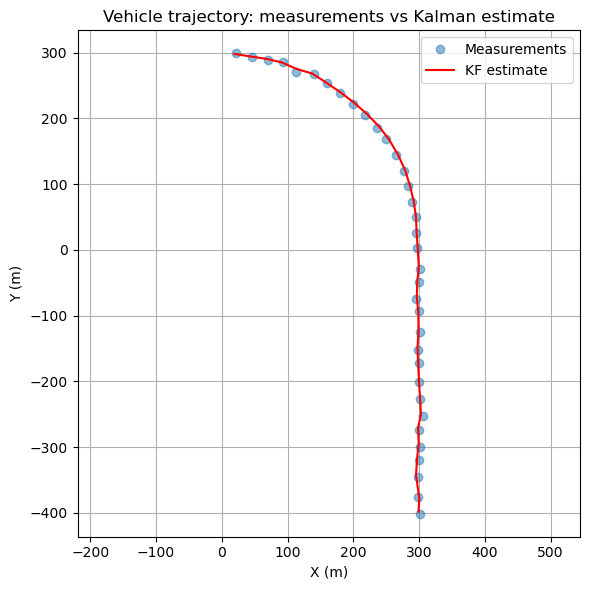

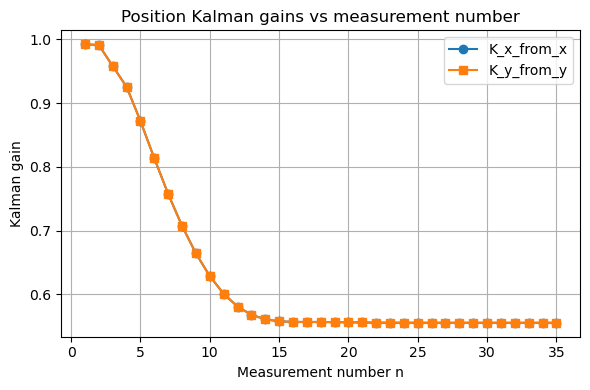

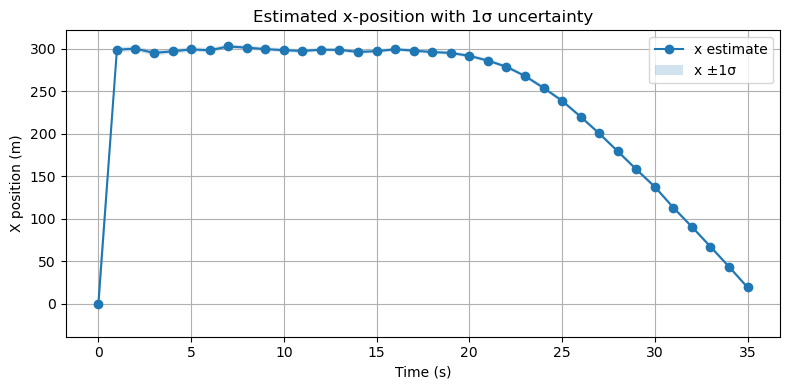

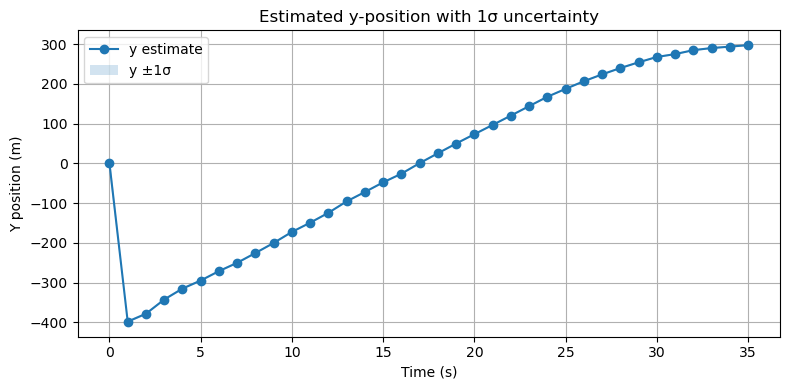

In [43]:
# ------------------------------------------------------------
# Step 5: Analyse results
# ------------------------------------------------------------
# Use one of the logged DataFrames for the remaining analysis.
# Here we use the .run() version.
ex2_analysis_df = ex2_logged_df_4B.copy()

n_values_ex2 = ex2_analysis_df["n"].to_numpy(dtype=float)

x_est_history_ex2 = np.stack(ex2_analysis_df["x_est"].to_list())
P_est_history_ex2 = np.stack(ex2_analysis_df["P_est"].to_list())

x_est_ex2 = x_est_history_ex2[:, 0]
y_est_ex2 = x_est_history_ex2[:, 3]

sigma_x_ex2 = np.sqrt(P_est_history_ex2[:, 0, 0])
sigma_y_ex2 = np.sqrt(P_est_history_ex2[:, 3, 3])

K_x_from_x_ex2 = np.array([
    np.nan if K is None else K[0, 0]
    for K in ex2_analysis_df["K"]
], dtype=np.float64)

K_y_from_y_ex2 = np.array([
    np.nan if K is None else K[3, 1]
    for K in ex2_analysis_df["K"]
], dtype=np.float64)


# Trajectory plot
plt.figure(figsize=(6, 6))
plt.plot(
    measurements_ex2[:, 0],
    measurements_ex2[:, 1],
    "o",
    label="Measurements",
    alpha=0.5,
)
plt.plot(
    x_est_ex2[1:],
    y_est_ex2[1:],
    "-r",
    label="KF estimate",
)
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Vehicle trajectory: measurements vs Kalman estimate")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Kalman gain evolution
plt.figure(figsize=(6, 4))
plt.plot(n_values_ex2, K_x_from_x_ex2, marker="o", label="K_x_from_x")
plt.plot(n_values_ex2, K_y_from_y_ex2, marker="s", label="K_y_from_y")
plt.xlabel("Measurement number n")
plt.ylabel("Kalman gain")
plt.title("Position Kalman gains vs measurement number")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Position estimates with 1-sigma bounds
time_values_ex2 = ex2_analysis_df["t"].to_numpy(dtype=float)

plt.figure(figsize=(8, 4))
plt.plot(time_values_ex2, x_est_ex2, label="x estimate", marker="o")
plt.fill_between(
    time_values_ex2,
    x_est_ex2 - sigma_x_ex2,
    x_est_ex2 + sigma_x_ex2,
    alpha=0.2,
    label="x ±1σ",
)
plt.xlabel("Time (s)")
plt.ylabel("X position (m)")
plt.title("Estimated x-position with 1σ uncertainty")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(time_values_ex2, y_est_ex2, label="y estimate", marker="o")
plt.fill_between(
    time_values_ex2,
    y_est_ex2 - sigma_y_ex2,
    y_est_ex2 + sigma_y_ex2,
    alpha=0.2,
    label="y ±1σ",
)
plt.xlabel("Time (s)")
plt.ylabel("Y position (m)")
plt.title("Estimated y-position with 1σ uncertainty")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 5 - Extended Kalman Filter

## 5.1 - ExtendedKF

In [44]:
class ExtendedKF(BaseKalmanFilter):
    """
    Discrete-time Extended Kalman Filter for covariance-form nonlinear state
    estimation.

    Required model methods
    ----------------------
    Process model:
        - f(x, u, dt): nonlinear process model
        - F_jacobian(x, u, dt): process Jacobian
        - Q(x, u, dt): process-noise covariance
    Measurement model:
        - h(x, measurement_name, dt): nonlinear measurement model
        - H_jacobian(x, measurement_name, dt): measurement Jacobian
        - R(x, z, measurement_name, dt): measurement-noise covariance

    Recursion
    ---------
        x_{k|k-1} = f(x_{k-1|k-1}, u_k, dt)
        P_{k|k-1} = F_k P_{k-1|k-1} F_k^T + Q_k
        where F_k = F_jacobian(x_{k-1|k-1}, u_k, dt)

        z_pred = h(x_{k|k-1})
        y_k    = innovation(z_k, z_pred)
        S_k    = H_k P_{k|k-1} H_k^T + R_k
        K_k    = P_{k|k-1} H_k^T S_k^{-1}
        where H_k = H_jacobian(x_{k|k-1})

        x_{k|k} = apply_state_delta(x_{k|k-1}, K_k y_k)
        P_{k|k} = (I - K_k H_k) P_{k|k-1} (I - K_k H_k)^T + K_k R_k K_k^T

    Geometry note
    -------------
    Non-Euclidean state and measurement spaces remain model-defined. The EKF
    uses `model.apply_state_delta(...)` for posterior state correction and
    `model.innovation(...)` for residual construction.

    Usage
    -----
    Assemble a `StateSpaceModel`, construct
    `ExtendedKF(states=..., model=..., initial_covariance=...)`,
    then call `predict(...)` and `update(...)`, or use `step(...)` / `run(...)`
    for the learner-facing convenience flow.
    """

    REQUIRED_PROCESS_MODEL_OVERRIDES = ("f", "F_jacobian", "Q")
    REQUIRED_MEASUREMENT_MODEL_OVERRIDES = ("h", "H_jacobian", "R")

    def __init__(
        self,
        states,
        model: StateSpaceModel,
        initial_covariance=None,
        gate_threshold: float | None = None,
        check_covariance: bool = True,
    ) -> None:
        super().__init__(
            states=states,
            model=model,
            initial_covariance=initial_covariance,
            gate_threshold=gate_threshold,
            check_covariance=check_covariance,
        )

    def _predict_impl(
        self,
        u: ControlVector | None,
        dt: float | None,
    ) -> None:
        if dt is None:
            raise ValueError("ExtendedKF.predict() requires a time step dt.")

        x_current = self.x
        if x_current is None:
            raise RuntimeError("ExtendedKF.predict() requires state x.")
        x_prev = x_current.copy()
        P_current = self.P
        if P_current is None:
            raise ValueError("ExtendedKF.predict() requires covariance P.")
        P_prev = P_current.copy()

        x_pred = self.model.f(x=x_prev, u=u, dt=dt)
        F_n = self.model.F_jacobian(x=x_prev, u=u, dt=dt)
        Q = self.model.Q(dt=dt, x=x_prev, u=u)

        P_pred = F_n @ P_prev @ F_n.T + Q
        self._x_pred = x_pred
        self._P_pred = P_pred
        self.x = x_pred
        self.P = P_pred

    def _update_impl(
        self,
        z: MeasurementVector,
        measurement_name: str,
        dt: float | None,
    ) -> None:
        if self._x_pred is None or self._P_pred is None:
            raise RuntimeError("ExtendedKF.update() requires a prior prediction.")

        x_prior_current = self._x_pred
        P_prior_current = self._P_pred
        if x_prior_current is None or P_prior_current is None:
            raise RuntimeError("ExtendedKF.update() requires a prior prediction.")

        x_prior = x_prior_current.copy()
        P_prior = P_prior_current.copy()
        if P_prior is None:
            raise ValueError(
                "ExtendedKF requires a predicted covariance before update()."
            )

        z_pred = self.model.h(
            x=x_prior,
            measurement_name=measurement_name,
            dt=dt,
        )
        H_n = self.model.H_jacobian(
            x=x_prior,
            measurement_name=measurement_name,
            dt=dt,
        )
        R = self.model.R(
            x=x_prior,
            z=z,
            measurement_name=measurement_name,
            dt=dt,
        )

        innovation = self.model.innovation(
            z,
            z_pred,
            measurement_name=measurement_name,
        )

        S_n = symmetrize_covariance(H_n @ P_prior @ H_n.T + R)

        if self._gate_threshold is not None:
            nis = quadratic_form_solve(innovation, S_n)
            if nis > self._gate_threshold:
                self.x = x_prior
                self.P = P_prior
                self._z_pred = z_pred
                self._innovation = innovation
                self._S = S_n
                self._K = None
                return

        try:
            K_n = np.linalg.solve(S_n, (P_prior @ H_n.T).T).T
        except np.linalg.LinAlgError as error:
            raise np.linalg.LinAlgError(
                "Innovation covariance S_n is singular or ill-conditioned."
            ) from error

        x_post = self.model.apply_state_delta(x=x_prior, dx=K_n @ innovation)

        identity = np.eye(self.n, dtype=np.float64)
        identity_minus_kh = identity - K_n @ H_n
        P_post = (
            identity_minus_kh @ P_prior @ identity_minus_kh.T
            + K_n @ R @ K_n.T
        )

        self.x = x_post
        self.P = P_post
        self._z_pred = z_pred
        self._innovation = innovation
        self._S = S_n
        self._K = K_n


## 5.2 - Examples

### 5.2.1 - Vehicle Location Estimation using Radar

In [45]:
# ============================================================
# Example 3: EKF vehicle tracking with radar (range + bearing)
# ============================================================

# ------------------------------------------------------------
# Step 1: Define process and measurement models
# ------------------------------------------------------------
class VehicleRadarProcessModel(ProcessModel):
    """
    Vehicle motion process model.

    State:
        x = [x, vx, ax, y, vy, ay]^T
    """

    def __init__(self, sigma_a: float) -> None:
        super().__init__(
            state_labels=("x", "vx", "ax", "y", "vy", "ay")
        )
        self.sigma_a = float(sigma_a)

    def f(
        self,
        x: StateVector,
        u: ControlVector | None = None,
        dt: float = 0.0,
    ) -> StateVector:
        return self.F(dt=dt, x=x, u=u) @ x

    def F_jacobian(
        self,
        x: StateVector,
        u: ControlVector | None = None,
        dt: float = 0.0,
    ) -> Matrix:
        return self.F(dt=dt, x=x, u=u)

    def F(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        return np.array(
            [
                [1.0, dt, 0.5 * dt**2, 0.0, 0.0, 0.0],
                [0.0, 1.0, dt,         0.0, 0.0, 0.0],
                [0.0, 0.0, 1.0,        0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0,        1.0, dt, 0.5 * dt**2],
                [0.0, 0.0, 0.0,        0.0, 1.0, dt],
                [0.0, 0.0, 0.0,        0.0, 0.0, 1.0],
            ],
            dtype=np.float64,
        )

    def Q(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        q3 = np.array(
            [
                [dt**4 / 4.0, dt**3 / 2.0, dt**2 / 2.0],
                [dt**3 / 2.0, dt**2,       dt],
                [dt**2 / 2.0, dt,          1.0],
            ],
            dtype=np.float64,
        ) * self.sigma_a**2

        process_noise = np.zeros((6, 6), dtype=np.float64)
        process_noise[0:3, 0:3] = q3
        process_noise[3:6, 3:6] = q3
        return process_noise


class RadarRangeBearingSensorModel(MeasurementModel):
    """
    Radar range-bearing sensor model.

    Measurement:
        z = [range, bearing]^T
    """

    def __init__(
        self,
        sigma_r: float,
        sigma_phi: float,
        state_labels: tuple[str, ...],
    ) -> None:
        super().__init__(
            state_labels=state_labels,
            measurement_labels=("range", "bearing"),
        )
        self.sigma_r = float(sigma_r)
        self.sigma_phi = float(sigma_phi)

    def h(
        self,
        x: StateVector,
        dt: float | None = None,
    ) -> MeasurementVector:
        px, _, _, py, _, _ = x

        r = np.sqrt(px**2 + py**2)
        phi = np.arctan2(py, px)

        return np.array([r, phi], dtype=np.float64)

    def H_jacobian(
        self,
        x: StateVector,
        dt: float | None = None,
    ) -> Matrix:
        px, _, _, py, _, _ = x

        r2 = max(px**2 + py**2, 1e-12)
        r = np.sqrt(r2)

        return np.array(
            [
                [px / r,   0.0, 0.0, py / r,   0.0, 0.0],
                [-py / r2, 0.0, 0.0, px / r2,  0.0, 0.0],
            ],
            dtype=np.float64,
        )

    def R(
        self,
        x: StateVector | None = None,
        z: MeasurementVector | None = None,
        dt: float | None = None,
    ) -> Matrix:
        return np.diag(
            [self.sigma_r**2, self.sigma_phi**2]
        ).astype(np.float64)

    def innovation(
        self,
        z: MeasurementVector,
        z_pred: MeasurementVector,
    ) -> MeasurementVector:
        innovation_vector = (
            np.asarray(z, dtype=np.float64)
            - np.asarray(z_pred, dtype=np.float64)
        )
        innovation_vector[1] = self.wrap_angle(innovation_vector[1])
        return innovation_vector

    @staticmethod
    def wrap_angle(rad: float) -> float:
        return (rad + np.pi) % (2.0 * np.pi) - np.pi


In [46]:
#EDITED#
# ------------------------------------------------------------
# Step 2: Assemble model, instantiate one filter, and preserve
# its initial condition for both run styles
# ------------------------------------------------------------
dt_ex3 = 1.0
sigma_a_ex3 = 0.2
sigma_r_ex3 = 5.0
sigma_phi_ex3 = 0.0087

initial_states_ex3 = {
    "x":  400.0,
    "vx": 0.0,
    "ax": 0.0,
    "y": -300.0,
    "vy": 0.0,
    "ay": 0.0,
}

initial_covariance_ex3 = {
    name: 500.0 for name in initial_states_ex3.keys()
}

radar_process_model_ex3 = VehicleRadarProcessModel(
    sigma_a=sigma_a_ex3,
)
radar_sensor_ex3 = RadarRangeBearingSensorModel(
    sigma_r=sigma_r_ex3,
    sigma_phi=sigma_phi_ex3,
    state_labels=radar_process_model_ex3.state_labels,
)

radar_model_ex3 = StateSpaceModel(
    process_model=radar_process_model_ex3,
    measurement_models={"radar_sensor": radar_sensor_ex3},
)

ekf_ex3 = ExtendedKF(
    states=initial_states_ex3,
    initial_covariance=initial_covariance_ex3,
    model=radar_model_ex3,
)

ekf_ex3_initial_state = ekf_ex3.state
ekf_ex3_initial_covariance = ekf_ex3.covariance


In [47]:
# ------------------------------------------------------------
# Step 3: Measurements and ground truth
# ------------------------------------------------------------
measurements_ex3 = np.array([
    [502.55, -0.9316],
    [477.34, -0.8977],
    [457.21, -0.8512],
    [442.94, -0.8114],
    [427.27, -0.7853],
    [406.05, -0.7392],
    [400.73, -0.7052],
    [377.32, -0.6478],
    [360.27, -0.5900],
    [345.93, -0.5183],
    [333.34, -0.4698],
    [328.07, -0.3952],
    [315.48, -0.3026],
    [301.41, -0.2445],
    [302.87, -0.1626],
    [304.25, -0.0937],
    [294.46,  0.0085],
    [294.29,  0.0856],
    [299.38,  0.1675],
    [299.37,  0.2467],
    [300.68,  0.3290],
    [304.10,  0.4149],
    [301.96,  0.5040],
    [300.30,  0.5934],
    [301.90,  0.6670],
    [296.70,  0.7537],
    [297.07,  0.8354],
    [295.29,  0.9195],
    [296.31,  1.0039],
    [300.62,  1.0923],
    [292.30,  1.1546],
    [298.11,  1.2564],
    [298.07,  1.3274],
    [298.92,  1.4090],
    [298.04,  1.5011],
], dtype=np.float64)

n_meas_ex3 = measurements_ex3.shape[0]
timestamps_ex3 = np.arange(1, n_meas_ex3 + 1, dtype=np.float64) * dt_ex3

# Ground truth is not provided in this example, so x_true is omitted.

In [48]:
# ------------------------------------------------------------
# Step 4A: Run the Step 2 filter manually using the public API
# ------------------------------------------------------------
logger_ex3_4A = EstimationLogger()

initial_snapshot_ex3_4A = ekf_ex3.snapshot(
    n=0,
    t=0.0,
    z=None,
    x_true=None,
)
logger_ex3_4A.record(initial_snapshot_ex3_4A)

for k, measurement in enumerate(measurements_ex3):
    z = np.asarray(measurement, dtype=np.float64)
    t = timestamps_ex3[k]

    ekf_ex3.predict(u=None, dt=dt_ex3)
    ekf_ex3.update(z=z)

    step_snapshot_ex3_4A = ekf_ex3.snapshot(
        n=k + 1,
        t=t,
        z=z,
        x_true=None,
    )
    logger_ex3_4A.record(step_snapshot_ex3_4A)

print(logger_ex3_4A)

ex3_logged_df_4A = logger_ex3_4A.to_dataframe()
display(ex3_logged_df_4A)


EstimationLogger (36 steps, t=0.000 to 35.000)


,n,t,x_pred,P_pred,x_est,P_est,measurement_name,z,z_pred,innovation,S,K,NIS,NEES
0,0,0.0,None,None,"[400.0, 0.0, 0.0, -300.0, 0.0, 0.0]","[[500.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 500.0...",None,None,None,None,None,None,NaN,None
1,1,1.0,"[400.0, 0.0, 0.0, -300.0, 0.0, 0.0]","[[1125.01, 750.02, 250.02, 0.0, 0.0, 0.0], [75...","[316.995672159528, -55.337202306566915, -18.44...","[[22.35159374846137, 14.90132740439729, 4.9673...",radar_sensor,"[502.55, -0.9316]","[500.0, -0.6435011087932844]","[2.5500000000000114, -0.2880988912067157]","[[1150.01, -9.844196673103322e-17], [-9.844196...","[[0.7826088468795923, 295.0375131399798], [0.5...",18.145049,None
2,2,2.0,"[252.4351109287405, -73.7839201550081, -18.446...","[[1015.147470609387, 1257.6338857763903, 564.4...","[317.4877036581164, 7.635162814827908, 18.2067...","[[23.683267382685102, 29.33943059747776, 13.16...",radar_sensor,"[477.34, -0.8977]","[563.8131215633497, -1.1065731371755223]","[-86.47312156334971, 0.20887313717552214]","[[1043.1127650380076, 0.013099349214172105], [...","[[0.43714495521065205, 492.42273550801605], [0...",20.760255,None
3,3,3.0,"[334.22626094179805, 25.84195175253543, 18.206...","[[336.785186274873, 368.194386329862, 182.0316...","[305.7183013581434, -5.280955358801219, 2.6278...","[[19.411320600214633, 21.225324440491868, 10.4...",radar_sensor,"[457.21, -0.8512]","[447.9909493233547, -0.728677278296435]","[9.219050676645281, -0.12252272170356493]","[[370.80360722227005, -0.001535377189542613], ...","[[0.6957008817096403, 285.02191905606816], [0....",9.028086,None
4,4,4.0,"[301.75124742661416, -2.653152504257214, 2.627...","[[200.39500727802698, 196.80169893826601, 84.5...","[305.8890162399528, 0.07249678887375932, 3.442...","[[17.60826962192276, 17.181237210893244, 7.352...",radar_sensor,"[442.94, -0.8114]","[411.34786922628473, -0.7472405028281495]","[31.59213077371527, -0.06415949717185043]","[[247.95202308555193, 0.0017170256444042637], ...","[[0.6597373912235756, 260.3627188935549], [0.6...",7.807898,None
5,5,5.0,"[307.6828267023079, 3.5151241358364893, 3.4426...","[[121.0279462023515, 100.3044396488823, 35.484...","[303.3876022345085, -0.7375834875670981, 1.810...","[[16.862224984623985, 13.934615458286398, 4.92...",radar_sensor,"[427.27, -0.7853]","[413.99327987731385, -0.7329449180904544]","[13.276720122686129, -0.05235508190954574]","[[170.27924193329017, -0.0021774898254183217],...","[[0.6336532507617861, 242.72832492077316], [0....",5.435397,None
6,6,6.0,"[303.55525688023863, 1.0728927790273584, 1.810...","[[82.02549851254403, 57.229798882284776, 16.92...","[300.7457061812797, -0.8767044436936962, 1.235...","[[15.712002053613075, 10.946980598225249, 3.23...",radar_sensor,"[406.05, -0.7392]","[409.7366971743357, -0.7364547181015678]","[-3.686697174335677, -0.0027452818984321503]","[[125.22888030568012, 0.000357104675762005], [...","[[0.5930920252000672, 226.93480253835656], [0....",0.125911,None
7,7,7.0,"[300.486844742424, 0.3589815659824249, 1.23568...","[[59.4189414779901, 35.67385348994298, 9.06258...","[303.9458597821502, 2.36438321683281, 1.732394...","[[14.667129854474402, 8.797096755164983, 2.233...",radar_sensor,"[400.73, -0.7052]","[391.30888363085535, -0.6952369758917438]","[9.42111636914467, -0.009963024108256224]","[[99.10810836727974, -0.0033214308486200165], ...","[[0.5722994959561274, 193.98579072771005], [0....",1.164460,None
8,8,8.0,"[307.17644045664264, 4.096778132152004, 1.7323...","[[46.21991974562751, 24.363593803415647, 5.449...","[302.9551580578192, 1.9581685690752804, 1.2710...","[[13.900287876214719, 7.32414076898653, 1.6374...",radar_sensor,"[377.32, -0.6478]","[389.7910998278195, -0.6631548476722587]","[-12.4710998278195, 0.01535484767225892]","[[83.0410769881529, -0.00289157417960592], [-0...","[[0.5483864881376265, 170.48037823895484], [0....",2.693526,None
9,9,9.0,"[305.5488456642886, 3.229206643863571, 1.27103...","[[38.23285542686386, 18.00349152796819, 3.6276...","[301.6587745483726, 1.4599238910265915, 0.9281

In [49]:
# ------------------------------------------------------------
# Step 4B: Reset the same filter and run using the built-in
# .run() helper
# ------------------------------------------------------------
ekf_ex3.reset(
    x0=ekf_ex3_initial_state,
    P0=ekf_ex3_initial_covariance,
)

logger_ex3_4B = ekf_ex3.run(
    measurements=measurements_ex3,
    dt=dt_ex3,
    timestamps=timestamps_ex3,
)

print(logger_ex3_4B)

ex3_logged_df_4B = logger_ex3_4B.to_dataframe()
display(ex3_logged_df_4B)


EstimationLogger (36 steps, t=0.000 to 35.000)


,n,t,x_pred,P_pred,x_est,P_est,measurement_name,z,z_pred,innovation,S,K,NIS,NEES
0,0,0.0,None,None,"[400.0, 0.0, 0.0, -300.0, 0.0, 0.0]","[[500.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 500.0...",None,None,None,None,None,None,NaN,None
1,1,1.0,"[400.0, 0.0, 0.0, -300.0, 0.0, 0.0]","[[1125.01, 750.02, 250.02, 0.0, 0.0, 0.0], [75...","[316.995672159528, -55.337202306566915, -18.44...","[[22.35159374846137, 14.90132740439729, 4.9673...",radar_sensor,"[502.55, -0.9316]","[500.0, -0.6435011087932844]","[2.5500000000000114, -0.2880988912067157]","[[1150.01, -9.844196673103322e-17], [-9.844196...","[[0.7826088468795923, 295.0375131399798], [0.5...",18.145049,None
2,2,2.0,"[252.4351109287405, -73.7839201550081, -18.446...","[[1015.147470609387, 1257.6338857763903, 564.4...","[317.4877036581164, 7.635162814827908, 18.2067...","[[23.683267382685102, 29.33943059747776, 13.16...",radar_sensor,"[477.34, -0.8977]","[563.8131215633497, -1.1065731371755223]","[-86.47312156334971, 0.20887313717552214]","[[1043.1127650380076, 0.013099349214172105], [...","[[0.43714495521065205, 492.42273550801605], [0...",20.760255,None
3,3,3.0,"[334.22626094179805, 25.84195175253543, 18.206...","[[336.785186274873, 368.194386329862, 182.0316...","[305.7183013581434, -5.280955358801219, 2.6278...","[[19.411320600214633, 21.225324440491868, 10.4...",radar_sensor,"[457.21, -0.8512]","[447.9909493233547, -0.728677278296435]","[9.219050676645281, -0.12252272170356493]","[[370.80360722227005, -0.001535377189542613], ...","[[0.6957008817096403, 285.02191905606816], [0....",9.028086,None
4,4,4.0,"[301.75124742661416, -2.653152504257214, 2.627...","[[200.39500727802698, 196.80169893826601, 84.5...","[305.8890162399528, 0.07249678887375932, 3.442...","[[17.60826962192276, 17.181237210893244, 7.352...",radar_sensor,"[442.94, -0.8114]","[411.34786922628473, -0.7472405028281495]","[31.59213077371527, -0.06415949717185043]","[[247.95202308555193, 0.0017170256444042637], ...","[[0.6597373912235756, 260.3627188935549], [0.6...",7.807898,None
5,5,5.0,"[307.6828267023079, 3.5151241358364893, 3.4426...","[[121.0279462023515, 100.3044396488823, 35.484...","[303.3876022345085, -0.7375834875670981, 1.810...","[[16.862224984623985, 13.934615458286398, 4.92...",radar_sensor,"[427.27, -0.7853]","[413.99327987731385, -0.7329449180904544]","[13.276720122686129, -0.05235508190954574]","[[170.27924193329017, -0.0021774898254183217],...","[[0.6336532507617861, 242.72832492077316], [0....",5.435397,None
6,6,6.0,"[303.55525688023863, 1.0728927790273584, 1.810...","[[82.02549851254403, 57.229798882284776, 16.92...","[300.7457061812797, -0.8767044436936962, 1.235...","[[15.712002053613075, 10.946980598225249, 3.23...",radar_sensor,"[406.05, -0.7392]","[409.7366971743357, -0.7364547181015678]","[-3.686697174335677, -0.0027452818984321503]","[[125.22888030568012, 0.000357104675762005], [...","[[0.5930920252000672, 226.93480253835656], [0....",0.125911,None
7,7,7.0,"[300.486844742424, 0.3589815659824249, 1.23568...","[[59.4189414779901, 35.67385348994298, 9.06258...","[303.9458597821502, 2.36438321683281, 1.732394...","[[14.667129854474402, 8.797096755164983, 2.233...",radar_sensor,"[400.73, -0.7052]","[391.30888363085535, -0.6952369758917438]","[9.42111636914467, -0.009963024108256224]","[[99.10810836727974, -0.0033214308486200165], ...","[[0.5722994959561274, 193.98579072771005], [0....",1.164460,None
8,8,8.0,"[307.17644045664264, 4.096778132152004, 1.7323...","[[46.21991974562751, 24.363593803415647, 5.449...","[302.9551580578192, 1.9581685690752804, 1.2710...","[[13.900287876214719, 7.32414076898653, 1.6374...",radar_sensor,"[377.32, -0.6478]","[389.7910998278195, -0.6631548476722587]","[-12.4710998278195, 0.01535484767225892]","[[83.0410769881529, -0.00289157417960592], [-0...","[[0.5483864881376265, 170.48037823895484], [0....",2.693526,None
9,9,9.0,"[305.5488456642886, 3.229206643863571, 1.27103...","[[38.23285542686386, 18.00349152796819, 3.6276...","[301.6587745483726, 1.4599238910265915, 0.9281

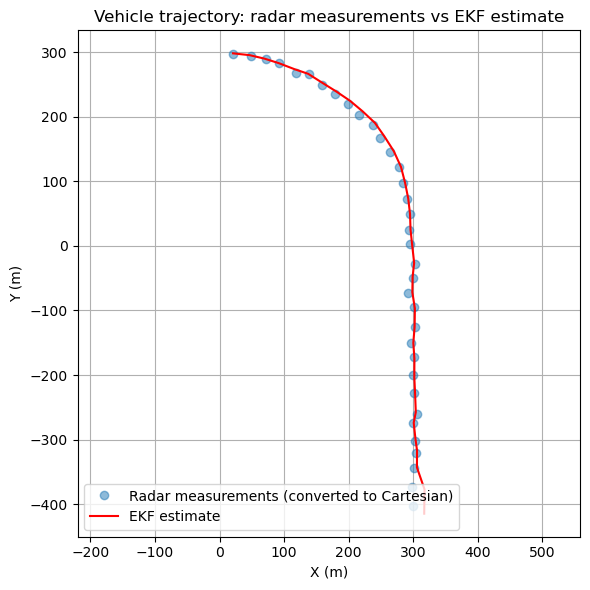

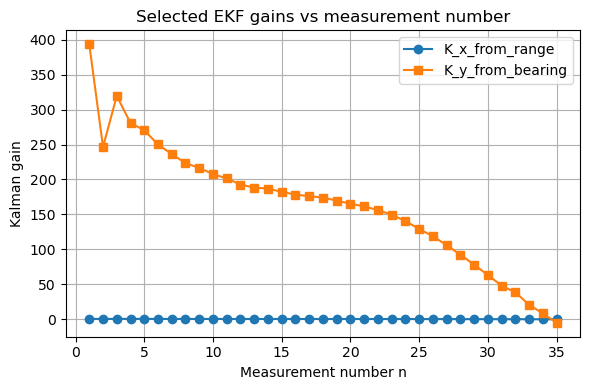

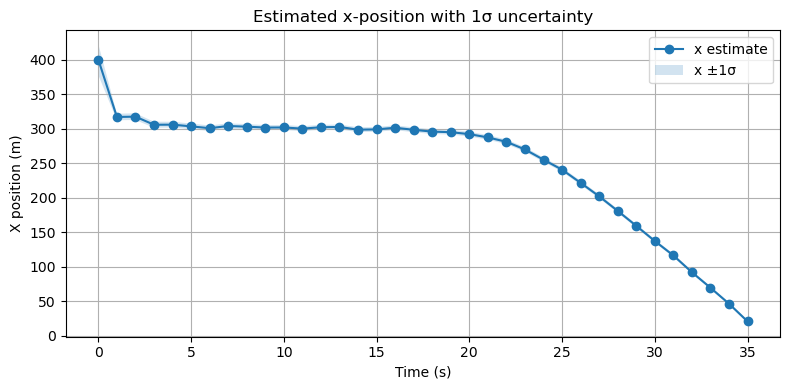

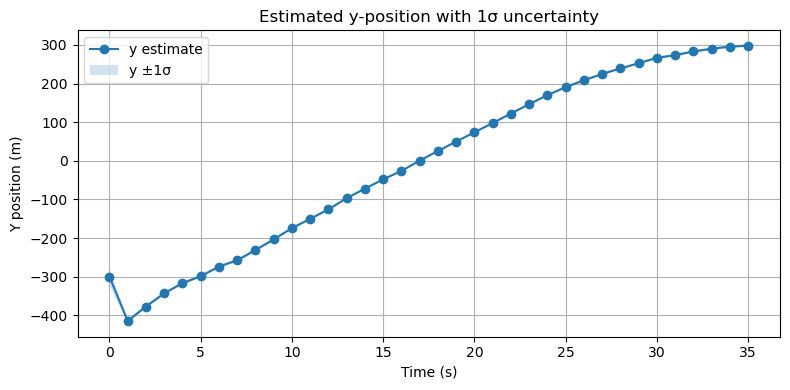

In [50]:
# ------------------------------------------------------------
# Step 5: Analyse results
# ------------------------------------------------------------
# Use one of the logged DataFrames for analysis.
# Here we use the .run() version.
ex3_analysis_df = ex3_logged_df_4B.copy()

n_values_ex3 = ex3_analysis_df["n"].to_numpy(dtype=float)

x_est_history_ex3 = np.stack(ex3_analysis_df["x_est"].tolist())

P_est_list_ex3 = ex3_analysis_df["P_est"].tolist()
assert all(P is not None for P in P_est_list_ex3)
P_est_history_ex3 = np.stack(P_est_list_ex3)

x_est_ex3 = x_est_history_ex3[:, 0]
y_est_ex3 = x_est_history_ex3[:, 3]

sigma_x_ex3 = np.sqrt(P_est_history_ex3[:, 0, 0])
sigma_y_ex3 = np.sqrt(P_est_history_ex3[:, 3, 3])

K_x_from_r_ex3 = np.array([
    np.nan if K is None else K[0, 0]
    for K in ex3_analysis_df["K"]
], dtype=np.float64)

K_y_from_phi_ex3 = np.array([
    np.nan if K is None else K[3, 1]
    for K in ex3_analysis_df["K"]
], dtype=np.float64)

range_meas_ex3 = measurements_ex3[:, 0]
bearing_meas_ex3 = measurements_ex3[:, 1]


# Convert radar measurements to Cartesian coordinates for plotting
meas_x_ex3 = range_meas_ex3 * np.cos(bearing_meas_ex3)
meas_y_ex3 = range_meas_ex3 * np.sin(bearing_meas_ex3)


# Estimated trajectory
plt.figure(figsize=(6, 6))
plt.plot(
    meas_x_ex3,
    meas_y_ex3,
    "o",
    label="Radar measurements (converted to Cartesian)",
    alpha=0.5,
)
plt.plot(
    x_est_ex3[1:],
    y_est_ex3[1:],
    "-r",
    label="EKF estimate",
)
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Vehicle trajectory: radar measurements vs EKF estimate")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Kalman gain evolution
plt.figure(figsize=(6, 4))
plt.plot(n_values_ex3, K_x_from_r_ex3, marker="o", label="K_x_from_range")
plt.plot(n_values_ex3, K_y_from_phi_ex3, marker="s", label="K_y_from_bearing")
plt.xlabel("Measurement number n")
plt.ylabel("Kalman gain")
plt.title("Selected EKF gains vs measurement number")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Position estimates with 1-sigma bounds
time_values_ex3 = ex3_analysis_df["t"].to_numpy(dtype=float)

plt.figure(figsize=(8, 4))
plt.plot(time_values_ex3, x_est_ex3, label="x estimate", marker="o")
plt.fill_between(
    time_values_ex3,
    x_est_ex3 - sigma_x_ex3,
    x_est_ex3 + sigma_x_ex3,
    alpha=0.2,
    label="x ±1σ",
)
plt.xlabel("Time (s)")
plt.ylabel("X position (m)")
plt.title("Estimated x-position with 1σ uncertainty")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(time_values_ex3, y_est_ex3, label="y estimate", marker="o")
plt.fill_between(
    time_values_ex3,
    y_est_ex3 - sigma_y_ex3,
    y_est_ex3 + sigma_y_ex3,
    alpha=0.2,
    label="y ±1σ",
)
plt.xlabel("Time (s)")
plt.ylabel("Y position (m)")
plt.title("Estimated y-position with 1σ uncertainty")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 5.2.2 - Pendulum Angle Estimation

In [51]:
# ============================================================
# Example 4: EKF pendulum angle estimation
# ============================================================

# ------------------------------------------------------------
# Step 1: Define process and measurement models
# ------------------------------------------------------------
class PendulumProcessModel(ProcessModel):
    """
    Pendulum process model.

    State:
        x = [theta, omega]^T
    """

    def __init__(
        self,
        L: float,
        g: float,
        sigma_a: float,
    ) -> None:
        super().__init__(state_labels=("theta", "omega"))
        self.L = float(L)
        self.g = float(g)
        self.sigma_a = float(sigma_a)

    def f(
        self,
        x: StateVector,
        u: ControlVector | None = None,
        dt: float = 0.0,
    ) -> StateVector:
        theta, omega = x

        theta_next = theta + dt * omega
        omega_next = omega - dt * (self.g / self.L) * np.sin(theta)

        return np.array([theta_next, omega_next], dtype=np.float64)

    def F_jacobian(
        self,
        x: StateVector,
        u: ControlVector | None = None,
        dt: float = 0.0,
    ) -> Matrix:
        theta, _ = x

        return np.array(
            [
                [1.0, dt],
                [-dt * (self.g / self.L) * np.cos(theta), 1.0],
            ],
            dtype=np.float64,
        )

    def F(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        return np.array(
            [
                [1.0, dt],
                [-dt * (self.g / self.L), 1.0],
            ],
            dtype=np.float64,
        )

    def Q(
        self,
        dt: float,
        x: StateVector | None = None,
        u: ControlVector | None = None,
    ) -> Matrix:
        q11 = dt**4 / 4.0
        q12 = dt**3 / 2.0
        q22 = dt**2

        Q_base = np.array(
            [
                [q11, q12],
                [q12, q22],
            ],
            dtype=np.float64,
        )

        return (self.sigma_a ** 2) * Q_base


class PendulumPositionSensorModel(MeasurementModel):
    """
    Nonlinear pendulum position sensor model.

    Measurement:
        z = [L * sin(theta)]
    """

    def __init__(
        self,
        L: float,
        sigma_xm: float,
        state_labels: tuple[str, ...],
    ) -> None:
        super().__init__(
            state_labels=state_labels,
            measurement_labels=("pendulum_position",),
        )
        self.L = float(L)
        self.sigma_xm = float(sigma_xm)

    def h(
        self,
        x: StateVector,
        dt: float | None = None,
    ) -> MeasurementVector:
        theta, _ = x
        return np.array([self.L * np.sin(theta)], dtype=np.float64)

    def H_jacobian(
        self,
        x: StateVector,
        dt: float | None = None,
    ) -> Matrix:
        theta, _ = x
        return np.array(
            [[self.L * np.cos(theta), 0.0]],
            dtype=np.float64,
        )

    def H(
        self,
        x: StateVector | None = None,
        dt: float | None = None,
    ) -> Matrix:
        return np.array([[self.L, 0.0]], dtype=np.float64)

    def R(
        self,
        x: StateVector | None = None,
        z: MeasurementVector | None = None,
        dt: float | None = None,
    ) -> Matrix:
        return np.array([[self.sigma_xm ** 2]], dtype=np.float64)


In [52]:
#EDITED#
# ------------------------------------------------------------
# Step 2: Assemble model, instantiate one filter, and preserve
# its initial condition for both run styles
# ------------------------------------------------------------
x0_ex4 = {
    "theta": 0.0873,
    "omega": 0.0,
}

P0_ex4 = {
    "theta": 5.0,
    "omega": 5.0,
}

dt_ex4 = 0.05

pendulum_process_model_ex4 = PendulumProcessModel(
    L=0.5,
    g=9.8,
    sigma_a=1.0,
)
pendulum_sensor_ex4 = PendulumPositionSensorModel(
    L=0.5,
    sigma_xm=0.01,
    state_labels=pendulum_process_model_ex4.state_labels,
)

pendulum_model_ex4 = StateSpaceModel(
    process_model=pendulum_process_model_ex4,
    measurement_models={"pendulum_sensor": pendulum_sensor_ex4},
)

ekf_ex4 = ExtendedKF(
    states=x0_ex4,
    initial_covariance=P0_ex4,
    model=pendulum_model_ex4,
)

ekf_ex4_initial_state = ekf_ex4.state
ekf_ex4_initial_covariance = ekf_ex4.covariance


In [53]:
# ------------------------------------------------------------
# Step 3: Measurements and ground truth
# ------------------------------------------------------------
measurements_ex4 = np.array(
    [0.119, 0.113, 0.120, 0.101, 0.099, 0.063, 0.008, -0.017, -0.037, -0.050],
    dtype=np.float64,
)

timestamps_ex4 = np.arange(1, len(measurements_ex4) + 1, dtype=np.float64) * dt_ex4

# Ground truth is not provided in this example, so x_true is omitted.

In [54]:
# ------------------------------------------------------------
# Step 4A: Run the Step 2 filter manually using the public API
# ------------------------------------------------------------
logger_ex4_4A = EstimationLogger()

initial_snapshot_ex4_4A = ekf_ex4.snapshot(
    n=0,
    t=0.0,
    z=None,
    x_true=None,
)
logger_ex4_4A.record(initial_snapshot_ex4_4A)

for k, measurement in enumerate(measurements_ex4):
    z = np.array([measurement], dtype=np.float64)
    t = timestamps_ex4[k]

    ekf_ex4.predict(u=None, dt=dt_ex4)
    ekf_ex4.update(z=z)

    step_snapshot_ex4_4A = ekf_ex4.snapshot(
        n=k + 1,
        t=t,
        z=z,
        x_true=None,
    )
    logger_ex4_4A.record(step_snapshot_ex4_4A)

print(logger_ex4_4A)

ex4_logged_df_4A = logger_ex4_4A.to_dataframe()
display(ex4_logged_df_4A)


EstimationLogger (11 steps, t=0.000 to 0.500)


,n,t,x_pred,P_pred,x_est,P_est,measurement_name,z,z_pred,innovation,S,K,NIS,NEES
0,0,0.00,None,None,"[0.0873, 0.0]","[[5.0, 0.0], [0.0, 5.0]]",None,None,None,None,None,None,NaN,None
1,1,0.05,"[0.0873, -0.08544536942940786]","[[5.0125015625, -4.631277195316932], [-4.63127...","[0.23867519238990076, -0.22530776502383532]","[[0.00040303166375742347, -0.00037237920628586...",pendulum_sensor,[0.119],[0.0435945762394938],[0.07540542376050619],[[1.2436991961795147]],"[[2.0074841416007527], [-1.8548055115855047]]",0.004572,None
2,2,0.10,"[0.22740980413870898, -0.4569950356433199]","[[0.01409058815388487, 0.2737887139318689], [0...","[0.22795318629257943, -0.4464367892836246]","[[0.00040918292920685785, 0.007950673650165073...",pendulum_sensor,[0.113],[0.11272738746268887],[0.00027261253731113155],[[0.003443591398399108]],"[[1.9932397799089185], [38.729863504572286]]",0.000022,None
3,3,0.15,"[0.2056313468283982, -0.667901240263893]","[[0.0020244934531308064, 0.02361665613554639],...","[0.23596317620919607, -0.3140663669820962]","[[0.00034605408738817834, 0.004036881607845277...",pendulum_sensor,[0.12],[0.1020926231701427],[0.017907376829857297],[[0.0005850222629677762]],"[[1.6938175629512107], [19.759168338482798]]",0.548140,None
4,4,0.20,"[0.22025985786009125, -0.5431703554203845]","[[0.0009681992922175474, 0.007915211100646843]...","[0.2084794636245078, -0.6394772913714746]","[[0.000292953765385835, 0.002394952066580561],...",pendulum_sensor,[0.101],[0.10924160516638419],[-0.008241605166384183],[[0.00033049559576146077]],"[[1.4293810486861518], [11.68545859778703]]",0.205522,None
5,5,0.25,"[0.17650559905593408, -0.8423103686685312]","[[0.0006258860069307845, 0.0038992530204126257...","[0.19022307045028972, -0.7568508901459826]","[[0.0002487156982872589, 0.0015494921232164218...",pendulum_sensor,[0.099],[0.08779527152209075],[0.011204728477909251],[[0.0002516471663191544]],"[[1.2242573678960997], [7.627090535128693]]",0.498897,None
6,6,0.30,"[0.1523805259429906, -0.9421472776206761]","[[0.0004559466694499682, 0.002312476919812495]...","[0.13863233869612532, -1.0118755327606668]","[[0.00021572006884010517, 0.001094092168575090...",pendulum_sensor,[0.063],[0.07589575101381286],[-0.012895751013812864],[[0.00021136033930525144]],"[[1.066102100772521], [5.407072070894018]]",0.786810,None
7,7,0.35,"[0.08803856205809198, -1.147300463129934]","[[0.0003613327500906396, 0.0015869378597702013...","[0.05390959876062463, -1.297191509424167]","[[0.00019054133085916905, 0.000836838763482039...",pendulum_sensor,[0.008],[0.043962439039832574],[-0.035962439039832574],[[0.0001896348411451498]],"[[0.9490169245658105], [4.167988887745108]]",6.819934,None
8,8,0.40,"[-0.010949976710583724, -1.3499973297606727]","[[0.0003036412040812342, 0.0012290039448793408...","[-0.02089673047299269, -1.3902573453594567]","[[0.00017262031458145665, 0.000698689916702363...",pendulum_sensor,[-0.017],[-0.005474878945614649],[-0.011525121054385353],[[0.00017590119958792625]],"[[0.8630498296262308], [3.49324014982601]]",0.755131,None
9,9,0.45,"[-0.09040959774096552, -1.3697800398874294]","[[0.0002691507260487731, 0.001059809007309752]...","[-0.08386402241115877, -1.3440061555127067]","[[0.00016142020883162144, 0.000635608879058245...",pendulum_sensor,[-0.037],[-0.0451432408183393],[0.008143240818339302],[[0.00016673917596620518]],"[[0.8038047106583821], [3.165064738927706]]",0.397701,None


In [55]:
# ------------------------------------------------------------
# Step 4B: Reset the same filter and run using the built-in
# .run() helper
# ------------------------------------------------------------
ekf_ex4.reset(
    x0=ekf_ex4_initial_state,
    P0=ekf_ex4_initial_covariance,
)

logger_ex4_4B = ekf_ex4.run(
    measurements=measurements_ex4.reshape(-1, 1),
    dt=dt_ex4,
    timestamps=timestamps_ex4,
)

print(logger_ex4_4B)

ex4_logged_df_4B = logger_ex4_4B.to_dataframe()
display(ex4_logged_df_4B)


EstimationLogger (11 steps, t=0.000 to 0.500)


,n,t,x_pred,P_pred,x_est,P_est,measurement_name,z,z_pred,innovation,S,K,NIS,NEES
0,0,0.00,None,None,"[0.0873, 0.0]","[[5.0, 0.0], [0.0, 5.0]]",None,None,None,None,None,None,NaN,None
1,1,0.05,"[0.0873, -0.08544536942940786]","[[5.0125015625, -4.631277195316932], [-4.63127...","[0.23867519238990076, -0.22530776502383532]","[[0.00040303166375742347, -0.00037237920628586...",pendulum_sensor,[0.119],[0.0435945762394938],[0.07540542376050619],[[1.2436991961795147]],"[[2.0074841416007527], [-1.8548055115855047]]",0.004572,None
2,2,0.10,"[0.22740980413870898, -0.4569950356433199]","[[0.01409058815388487, 0.2737887139318689], [0...","[0.22795318629257943, -0.4464367892836246]","[[0.00040918292920685785, 0.007950673650165073...",pendulum_sensor,[0.113],[0.11272738746268887],[0.00027261253731113155],[[0.003443591398399108]],"[[1.9932397799089185], [38.729863504572286]]",0.000022,None
3,3,0.15,"[0.2056313468283982, -0.667901240263893]","[[0.0020244934531308064, 0.02361665613554639],...","[0.23596317620919607, -0.3140663669820962]","[[0.00034605408738817834, 0.004036881607845277...",pendulum_sensor,[0.12],[0.1020926231701427],[0.017907376829857297],[[0.0005850222629677762]],"[[1.6938175629512107], [19.759168338482798]]",0.548140,None
4,4,0.20,"[0.22025985786009125, -0.5431703554203845]","[[0.0009681992922175474, 0.007915211100646843]...","[0.2084794636245078, -0.6394772913714746]","[[0.000292953765385835, 0.002394952066580561],...",pendulum_sensor,[0.101],[0.10924160516638419],[-0.008241605166384183],[[0.00033049559576146077]],"[[1.4293810486861518], [11.68545859778703]]",0.205522,None
5,5,0.25,"[0.17650559905593408, -0.8423103686685312]","[[0.0006258860069307845, 0.0038992530204126257...","[0.19022307045028972, -0.7568508901459826]","[[0.0002487156982872589, 0.0015494921232164218...",pendulum_sensor,[0.099],[0.08779527152209075],[0.011204728477909251],[[0.0002516471663191544]],"[[1.2242573678960997], [7.627090535128693]]",0.498897,None
6,6,0.30,"[0.1523805259429906, -0.9421472776206761]","[[0.0004559466694499682, 0.002312476919812495]...","[0.13863233869612532, -1.0118755327606668]","[[0.00021572006884010517, 0.001094092168575090...",pendulum_sensor,[0.063],[0.07589575101381286],[-0.012895751013812864],[[0.00021136033930525144]],"[[1.066102100772521], [5.407072070894018]]",0.786810,None
7,7,0.35,"[0.08803856205809198, -1.147300463129934]","[[0.0003613327500906396, 0.0015869378597702013...","[0.05390959876062463, -1.297191509424167]","[[0.00019054133085916905, 0.000836838763482039...",pendulum_sensor,[0.008],[0.043962439039832574],[-0.035962439039832574],[[0.0001896348411451498]],"[[0.9490169245658105], [4.167988887745108]]",6.819934,None
8,8,0.40,"[-0.010949976710583724, -1.3499973297606727]","[[0.0003036412040812342, 0.0012290039448793408...","[-0.02089673047299269, -1.3902573453594567]","[[0.00017262031458145665, 0.000698689916702363...",pendulum_sensor,[-0.017],[-0.005474878945614649],[-0.011525121054385353],[[0.00017590119958792625]],"[[0.8630498296262308], [3.49324014982601]]",0.755131,None
9,9,0.45,"[-0.09040959774096552, -1.3697800398874294]","[[0.0002691507260487731, 0.001059809007309752]...","[-0.08386402241115877, -1.3440061555127067]","[[0.00016142020883162144, 0.000635608879058245...",pendulum_sensor,[-0.037],[-0.0451432408183393],[0.008143240818339302],[[0.00016673917596620518]],"[[0.8038047106583821], [3.165064738927706]]",0.397701,None


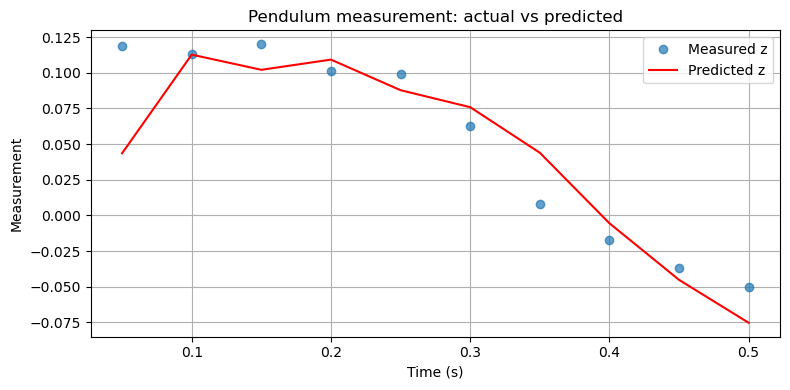

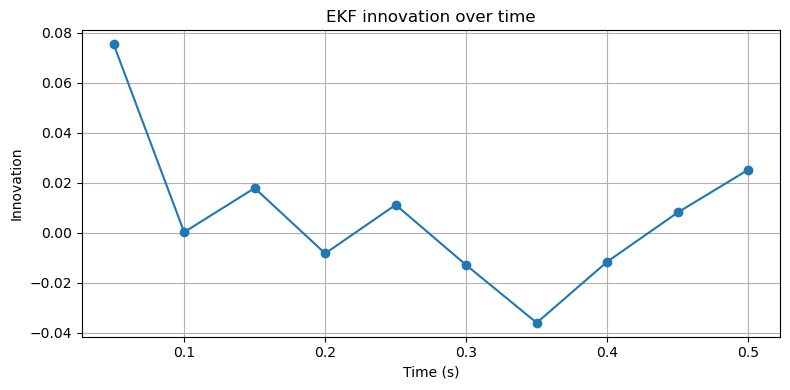

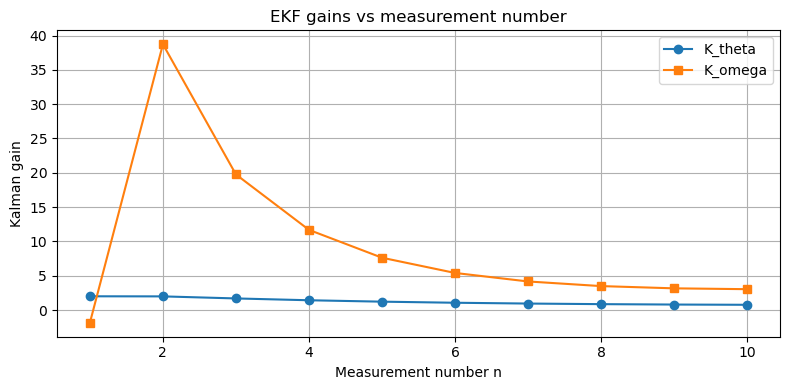

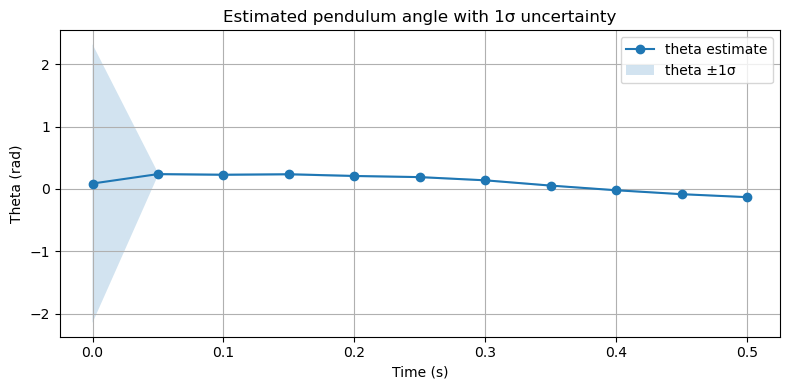

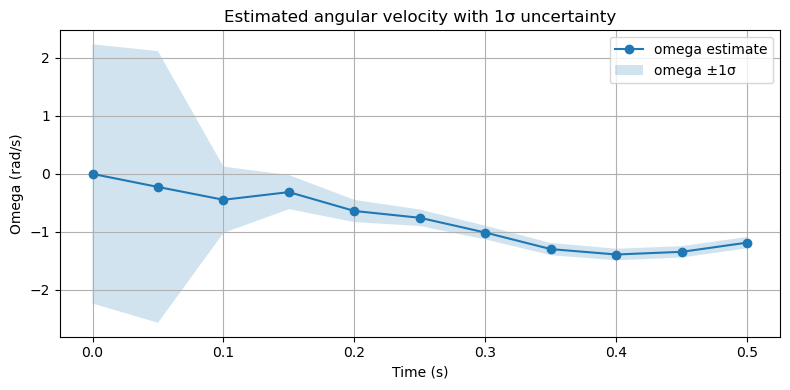

In [56]:
# ------------------------------------------------------------
# Step 5: Analyse results
# ------------------------------------------------------------
# Use one of the logged DataFrames for the remaining analysis.
# Here we use the .run() version.
ex4_analysis_df = ex4_logged_df_4B.copy()

n_values_ex4 = ex4_analysis_df["n"].to_numpy(dtype=float)

x_est_history_ex4 = np.stack(ex4_analysis_df["x_est"].tolist())

P_est_list_ex4 = ex4_analysis_df["P_est"].tolist()
assert all(P is not None for P in P_est_list_ex4)
P_est_history_ex4 = np.stack(P_est_list_ex4)

theta_est_ex4 = x_est_history_ex4[:, 0]
omega_est_ex4 = x_est_history_ex4[:, 1]

sigma_theta_ex4 = np.sqrt(P_est_history_ex4[:, 0, 0])
sigma_omega_ex4 = np.sqrt(P_est_history_ex4[:, 1, 1])

z_pred_ex4 = np.array([
    np.nan if z_pred is None else z_pred[0]
    for z_pred in ex4_analysis_df["z_pred"]
], dtype=np.float64)

innovation_ex4 = np.array([
    np.nan if innovation is None else innovation[0]
    for innovation in ex4_analysis_df["innovation"]
], dtype=np.float64)

K_theta_ex4 = np.array([
    np.nan if K is None else K[0, 0]
    for K in ex4_analysis_df["K"]
], dtype=np.float64)

K_omega_ex4 = np.array([
    np.nan if K is None else K[1, 0]
    for K in ex4_analysis_df["K"]
], dtype=np.float64)

time_values_ex4 = ex4_analysis_df["t"].to_numpy(dtype=float)


# Measured vs predicted measurement
plt.figure(figsize=(8, 4))
plt.plot(timestamps_ex4, measurements_ex4, "o", label="Measured z", alpha=0.7)
plt.plot(time_values_ex4[1:], z_pred_ex4[1:], "-r", label="Predicted z")
plt.xlabel("Time (s)")
plt.ylabel("Measurement")
plt.title("Pendulum measurement: actual vs predicted")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Innovation over time
plt.figure(figsize=(8, 4))
plt.plot(time_values_ex4[1:], innovation_ex4[1:], marker="o")
plt.xlabel("Time (s)")
plt.ylabel("Innovation")
plt.title("EKF innovation over time")
plt.grid(True)
plt.tight_layout()
plt.show()


# Kalman gain evolution
plt.figure(figsize=(8, 4))
plt.plot(n_values_ex4, K_theta_ex4, marker="o", label="K_theta")
plt.plot(n_values_ex4, K_omega_ex4, marker="s", label="K_omega")
plt.xlabel("Measurement number n")
plt.ylabel("Kalman gain")
plt.title("EKF gains vs measurement number")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Estimated states with 1-sigma bounds
plt.figure(figsize=(8, 4))
plt.plot(time_values_ex4, theta_est_ex4, marker="o", label="theta estimate")
plt.fill_between(
    time_values_ex4,
    theta_est_ex4 - sigma_theta_ex4,
    theta_est_ex4 + sigma_theta_ex4,
    alpha=0.2,
    label="theta ±1σ",
)
plt.xlabel("Time (s)")
plt.ylabel("Theta (rad)")
plt.title("Estimated pendulum angle with 1σ uncertainty")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(time_values_ex4, omega_est_ex4, marker="o", label="omega estimate")
plt.fill_between(
    time_values_ex4,
    omega_est_ex4 - sigma_omega_ex4,
    omega_est_ex4 + sigma_omega_ex4,
    alpha=0.2,
    label="omega ±1σ",
)
plt.xlabel("Time (s)")
plt.ylabel("Omega (rad/s)")
plt.title("Estimated angular velocity with 1σ uncertainty")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 6 - Unscented Kalman Filter

## 6.1 - UnscentedKF

## 6.2 - Examples

### 6.2.1 - Vehicle Location estimation using radar (UnscentedKF implementation)